In [10]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import snntorch as snn
import matplotlib.pyplot as plt
import pandas as pd

from src import lif_utils as lu






In [ ]:
CANVAS_HEIGHT = 128
CANVAS_WIDTH = 128
STEPS = 7

INTENSITY = 1.0

SHAPE_TEMPLATES = lu.make_toy_2d_shape_templates()

DIRECTION_CONFIG = {
    "right": {"velocity_y": 0, "velocity_x": 1, "start_top": 60, "start_left": 20},
    "left":  {"velocity_y": 0, "velocity_x": -1, "start_top": 60, "start_left": 103},
    "down":  {"velocity_y": 1, "velocity_x": 0, "start_top": 20, "start_left": 60},
    "up":    {"velocity_y": -1, "velocity_x": 0, "start_top": 103, "start_left": 60},
}

In [3]:
def make_unblurred_spike_case(
    speed,
    direction_name,
    shape_name="seven",
):
    config = DIRECTION_CONFIG[direction_name]

    velocity_y = config["velocity_y"] * speed
    velocity_x = config["velocity_x"] * speed

    frames, origins = lu.make_moving_2d_shape(
        shape=SHAPE_TEMPLATES[shape_name],
        canvas_height=CANVAS_HEIGHT,
        canvas_width=CANVAS_WIDTH,
        steps=STEPS,
        start_top=config["start_top"],
        start_left=config["start_left"],
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        intensity=INTENSITY,
    )

    # Treat binary object pixels as spikes.
    spikes = (frames > 0).float()

    return {
        "shape_name": shape_name,
        "direction_name": direction_name,
        "speed": speed,
        "velocity_y": velocity_y,
        "velocity_x": velocity_x,
        "frames": frames,
        "spikes": spikes,
        "origins": origins,
    }

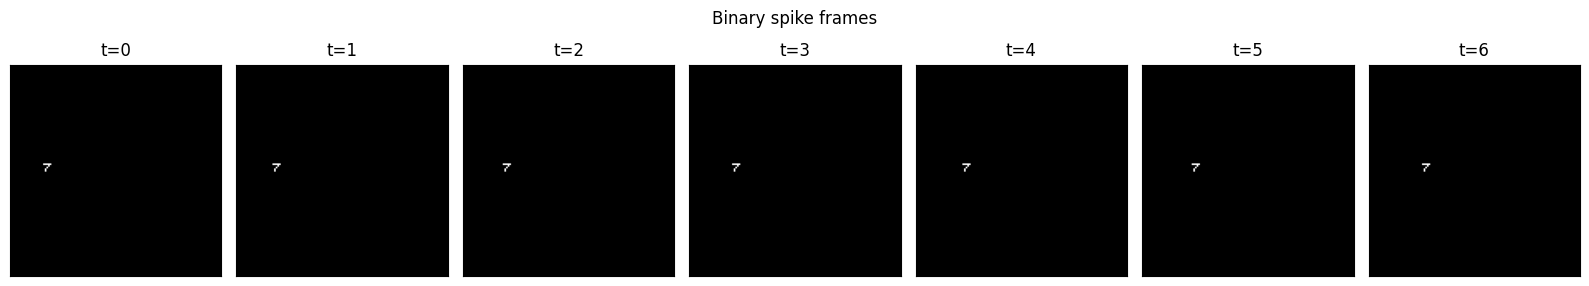

In [4]:
case = make_unblurred_spike_case(
    speed=2,
    direction_name="right",
    shape_name="seven",
)

fig, axes = plt.subplots(1, STEPS, figsize=(16, 3))

for t in range(STEPS):
    axes[t].imshow(case["spikes"][t], cmap="gray")
    axes[t].set_title(f"t={t}")
    axes[t].set_xticks([])
    axes[t].set_yticks([])

plt.suptitle("Binary spike frames")
plt.tight_layout()
plt.show()

In [5]:
def make_displacement_candidates(
    speeds=range(1, 7),
    directions=("right", "left", "down", "up"),
):
    candidates = []

    for speed in speeds:
        if "right" in directions:
            candidates.append({"direction": "right", "speed": speed, "dy": 0, "dx": speed})
        if "left" in directions:
            candidates.append({"direction": "left", "speed": speed, "dy": 0, "dx": -speed})
        if "down" in directions:
            candidates.append({"direction": "down", "speed": speed, "dy": speed, "dx": 0})
        if "up" in directions:
            candidates.append({"direction": "up", "speed": speed, "dy": -speed, "dx": 0})

    return candidates

In [6]:
def score_candidate_displacement(
    previous_spikes,
    current_spikes,
    dy,
    dx,
):
    shifted_previous = lu.shift_2d_frame(
        previous_spikes,
        shift_y=dy,
        shift_x=dx,
    )

    overlap = (shifted_previous * current_spikes).sum().item()

    previous_count = previous_spikes.sum().item()
    current_count = current_spikes.sum().item()

    union = ((shifted_previous + current_spikes) > 0).float().sum().item()

    if union > 0:
        iou = overlap / union
    else:
        iou = 0.0

    return {
        "overlap": overlap,
        "iou": iou,
        "previous_count": previous_count,
        "current_count": current_count,
    }

In [11]:
def predict_displacement_between_frames(
    previous_spikes,
    current_spikes,
    candidate_speeds=range(1, 7),
    candidate_directions=("right", "left", "down", "up"),
):
    candidates = make_displacement_candidates(
        speeds=candidate_speeds,
        directions=candidate_directions,
    )

    rows = []

    for candidate in candidates:
        score = score_candidate_displacement(
            previous_spikes=previous_spikes,
            current_spikes=current_spikes,
            dy=candidate["dy"],
            dx=candidate["dx"],
        )

        rows.append({
            "direction": candidate["direction"],
            "speed": candidate["speed"],
            "dy": candidate["dy"],
            "dx": candidate["dx"],
            **score,
        })

    scores = pd.DataFrame(rows)

    # Primary readout: overlap.
    # Tie-breaker: IoU.
    scores = scores.sort_values(
        ["overlap", "iou"],
        ascending=False,
    ).reset_index(drop=True)

    return scores

In [12]:
true_speed = 2
true_direction = "right"
shape_name = "seven"

case = make_unblurred_spike_case(
    speed=true_speed,
    direction_name=true_direction,
    shape_name=shape_name,
)

previous_t = 5
current_t = 6

scores = predict_displacement_between_frames(
    previous_spikes=case["spikes"][previous_t],
    current_spikes=case["spikes"][current_t],
    candidate_speeds=range(1, 7),
    candidate_directions=("right", "left", "down", "up"),
)

print("True:", true_direction, true_speed)
scores.head(20)

True: right 2


,direction,speed,dy,dx,overlap,iou,previous_count,current_count
0,right,2,0,2,9.0,1.000000,9.0,9.0
1,right,1,0,1,4.0,0.285714,9.0,9.0
2,right,3,0,3,4.0,0.285714,9.0,9.0
3,right,4,0,4,3.0,0.200000,9.0,9.0
4,left,1,0,-1,2.0,0.125000,9.0,9.0
5,down,2,2,0,2.0,0.125000,9.0,9.0
6,down,3,3,0,2.0,0.125000,9.0,9.0
7,right,5,0,5,2.0,0.125000,9.0,9.0
8,up,1,-1,0,1.0,0.058824,9.0,9.0
9,left,2,0,-2,1.0,0.058824,9.0,9.0


In [13]:
def test_spike_overlap_motion_estimator(
    shape_name="seven",
    speeds=range(1, 7),
    directions=("right", "left", "down", "up"),
    previous_t=5,
    current_t=6,
):
    rows = []

    for true_speed in speeds:
        for true_direction in directions:
            case = make_unblurred_spike_case(
                speed=true_speed,
                direction_name=true_direction,
                shape_name=shape_name,
            )

            scores = predict_displacement_between_frames(
                previous_spikes=case["spikes"][previous_t],
                current_spikes=case["spikes"][current_t],
                candidate_speeds=range(1, 7),
                candidate_directions=directions,
            )

            best = scores.iloc[0]

            rows.append({
                "shape": shape_name,
                "true_direction": true_direction,
                "true_speed": true_speed,
                "estimated_direction": best["direction"],
                "estimated_speed": best["speed"],
                "overlap": best["overlap"],
                "iou": best["iou"],
                "correct_direction": best["direction"] == true_direction,
                "correct_speed": best["speed"] == true_speed,
                "correct_exact": (
                    best["direction"] == true_direction
                    and best["speed"] == true_speed
                ),
            })

    return pd.DataFrame(rows)

In [14]:
overlap_results_seven = test_spike_overlap_motion_estimator(
    shape_name="seven",
    speeds=range(1, 7),
    directions=("right", "left", "down", "up"),
)

overlap_results_seven

,shape,true_direction,true_speed,estimated_direction,estimated_speed,overlap,iou,correct_direction,correct_speed,correct_exact
0,seven,right,1,right,1,9.0,1.0,True,True,True
1,seven,left,1,left,1,9.0,1.0,True,True,True
2,seven,down,1,down,1,9.0,1.0,True,True,True
3,seven,up,1,up,1,9.0,1.0,True,True,True
4,seven,right,2,right,2,9.0,1.0,True,True,True
5,seven,left,2,left,2,9.0,1.0,True,True,True
6,seven,down,2,down,2,9.0,1.0,True,True,True
7,seven,up,2,up,2,9.0,1.0,True,True,True
8,seven,right,3,right,3,9.0,1.0,True,True,True
9,seven,left,3,left,3,9.0,1.0,True,True,True


In [15]:
case = make_unblurred_spike_case(
    speed=2,
    direction_name="right",
    shape_name="seven",
)

spikes = case["spikes"]

print("Spike tensor shape:", spikes.shape)
print("Spike counts per frame:", spikes.flatten(start_dim=1).sum(dim=1).tolist())
print("Total pixels in canvas:", CANVAS_HEIGHT * CANVAS_WIDTH)

Spike tensor shape: torch.Size([7, 128, 128])
Spike counts per frame: [9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0]
Total pixels in canvas: 16384


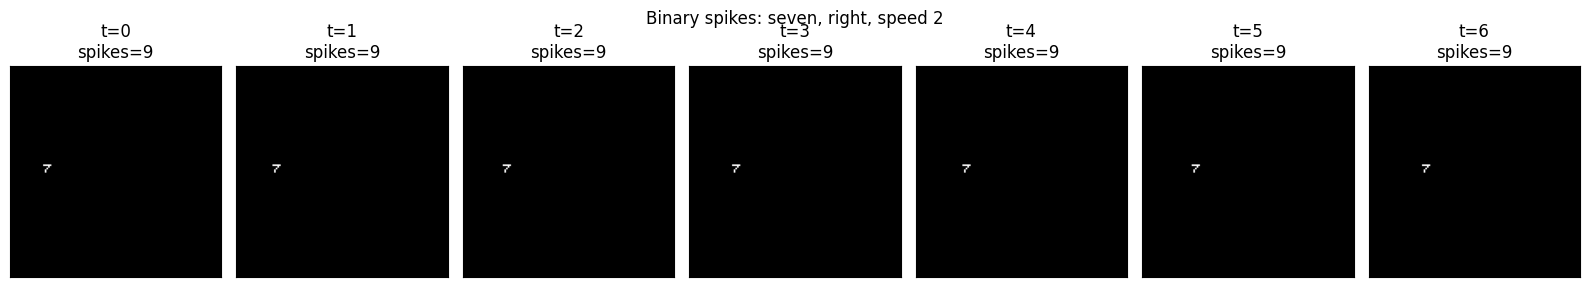

In [16]:
fig, axes = plt.subplots(1, STEPS, figsize=(16, 3))

for t in range(STEPS):
    axes[t].imshow(spikes[t], cmap="gray", vmin=0, vmax=1)
    axes[t].set_title(f"t={t}\nspikes={int(spikes[t].sum().item())}")
    axes[t].set_xticks([])
    axes[t].set_yticks([])

plt.suptitle(
    f"Binary spikes: {case['shape_name']}, {case['direction_name']}, speed {case['speed']}"
)
plt.tight_layout()
plt.show()

In [76]:
def plot_input_next_to_spikes(case):
    frames = case["frames"]
    spikes = case["spikes"]

    num_steps = frames.shape[0]

    fig, axes = plt.subplots(2, num_steps, figsize=(2.5 * num_steps, 5))

    for t in range(num_steps):
        axes[0, t].imshow(frames[t], cmap="gray", vmin=0, vmax=1)
        axes[0, t].set_title(f"Input t={t}")
        axes[0, t].set_xticks([])
        axes[0, t].set_yticks([])

        axes[1, t].imshow(spikes[t], cmap="gray", vmin=0, vmax=1)
        axes[1, t].set_title(f"Spikes t={t}\ncount={int(spikes[t].sum().item())}")
        axes[1, t].set_xticks([])
        axes[1, t].set_yticks([])

    plt.suptitle(
        f"Input vs spikes: {case['shape_name']}, {case['direction_name']}, speed {case['speed']}"
    )
    plt.tight_layout()
    plt.show()

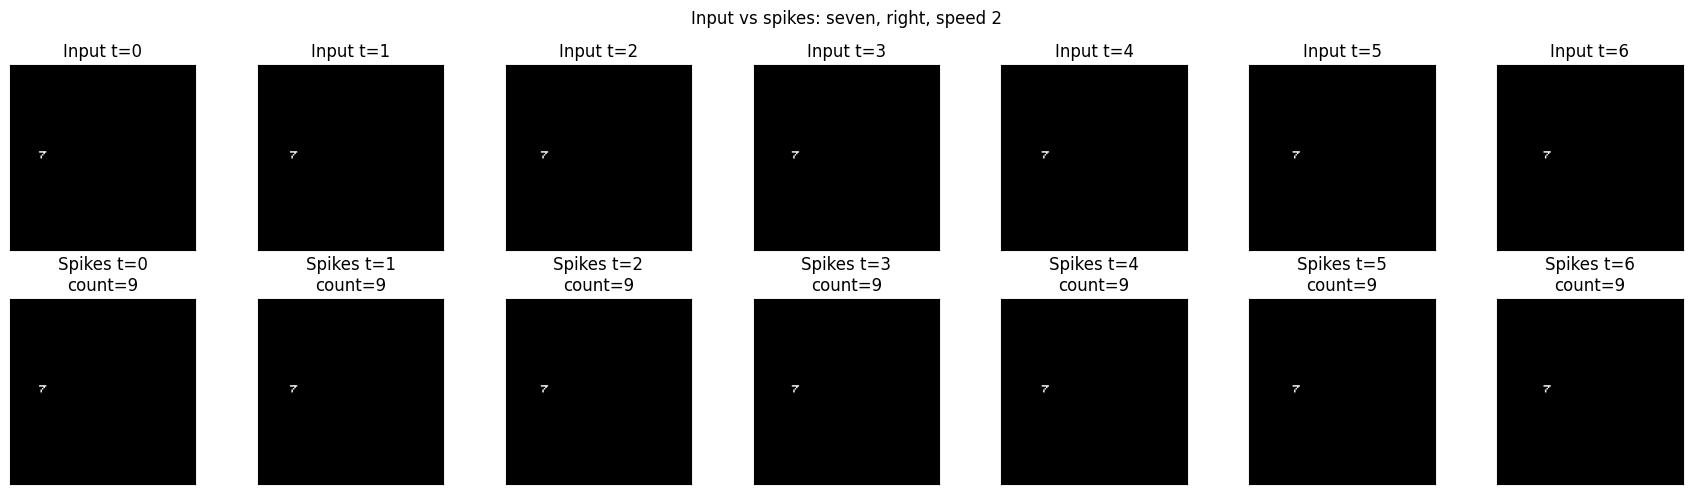

In [18]:
case = make_unblurred_spike_case(
    speed=2,
    direction_name="right",
    shape_name="seven",
)

plot_input_next_to_spikes(case)

In [19]:
def compute_on_off_difference_layer(previous_spikes, current_spikes):
    """
    Spike-only difference layer.

    previous_spikes: [H, W], binary
    current_spikes:  [H, W], binary

    Returns two separate spiking populations:
        ON[y, x]  = 1 if activity appeared at (y, x)
        OFF[y, x] = 1 if activity disappeared at (y, x)
    """

    previous_spikes = (previous_spikes > 0).float()
    current_spikes = (current_spikes > 0).float()

    on_spikes = ((previous_spikes == 0) & (current_spikes == 1)).float()
    off_spikes = ((previous_spikes == 1) & (current_spikes == 0)).float()
    same_spikes = ((previous_spikes == 1) & (current_spikes == 1)).float()

    return {
        "on_spikes": on_spikes,
        "off_spikes": off_spikes,
        "same_spikes": same_spikes,
    }

In [20]:
def plot_on_off_difference_layer(case, previous_t=5, current_t=6):
    previous_spikes = case["spikes"][previous_t]
    current_spikes = case["spikes"][current_t]

    diff = compute_on_off_difference_layer(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
    )

    signed_difference = diff["on_spikes"] - diff["off_spikes"]

    fig, axes = plt.subplots(1, 5, figsize=(16, 3))

    axes[0].imshow(previous_spikes, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Previous spikes\nt={previous_t}")

    axes[1].imshow(current_spikes, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Current spikes\nt={current_t}")

    axes[2].imshow(diff["off_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[2].set_title(f"OFF population\ncount={int(diff['off_spikes'].sum().item())}")

    axes[3].imshow(diff["on_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[3].set_title(f"ON population\ncount={int(diff['on_spikes'].sum().item())}")

    axes[4].imshow(signed_difference, cmap="bwr", vmin=-1, vmax=1)
    axes[4].set_title("Signed view\nOFF=-1, ON=+1")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(
        f"ON/OFF difference layer: {case['shape_name']}, "
        f"{case['direction_name']}, speed {case['speed']}"
    )
    plt.tight_layout()
    plt.show()

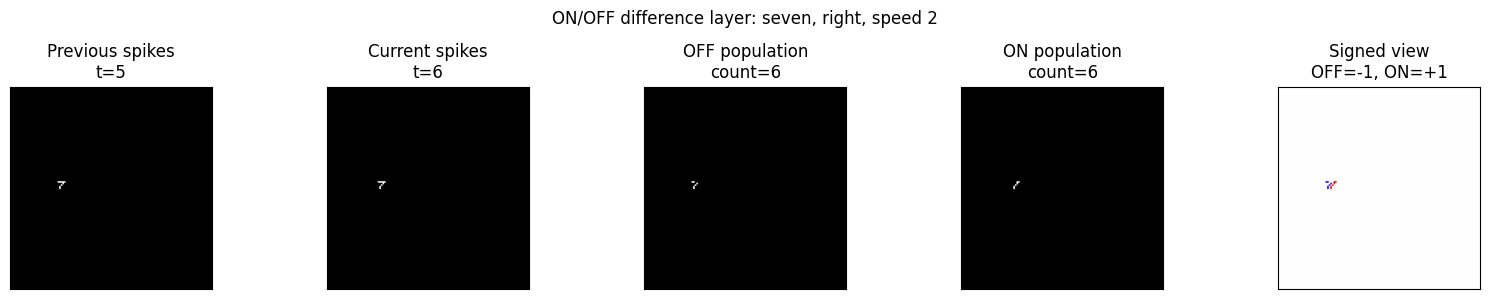

In [21]:
case = make_unblurred_spike_case(
    speed=2,
    direction_name="right",
    shape_name="seven",
)

plot_on_off_difference_layer(case, previous_t=5, current_t=6)

In [22]:
def compute_motion_pair_layer(
    off_spikes,
    on_spikes,
    max_offset=6,
):
    """
    Motion-pair layer.

    For each spatial offset (dy, dx), this layer counts local OFF/ON pairs:

        OFF[y, x] and ON[y + dy, x + dx]

    This is a neural-style interpretation:
        each offset corresponds to a population of neurons
        with fixed spatial-offset wiring.

    Returns a DataFrame with one row per offset population.
    """

    height, width = off_spikes.shape

    rows = []

    off_positions = torch.nonzero(off_spikes > 0, as_tuple=False)

    for dy in range(-max_offset, max_offset + 1):
        for dx in range(-max_offset, max_offset + 1):
            if dy == 0 and dx == 0:
                continue

            pair_count = 0

            for pos in off_positions:
                y = int(pos[0].item())
                x = int(pos[1].item())

                target_y = y + dy
                target_x = x + dx

                if 0 <= target_y < height and 0 <= target_x < width:
                    if on_spikes[target_y, target_x] > 0:
                        pair_count += 1

            rows.append({
                "dy": dy,
                "dx": dx,
                "pair_spike_count": pair_count,
                "offset_magnitude": (dy ** 2 + dx ** 2) ** 0.5,
            })

    motion_pair_scores = pd.DataFrame(rows)

    motion_pair_scores = motion_pair_scores.sort_values(
        ["pair_spike_count", "offset_magnitude"],
        ascending=[False, True],
    ).reset_index(drop=True)

    return motion_pair_scores

In [23]:
def estimate_velocity_from_motion_pairs(
    previous_spikes,
    current_spikes,
    max_offset=6,
):
    """
    Estimate velocity from ON/OFF difference neurons
    and motion-pair populations.

    Output is a 2D velocity vector:
        estimated_dy, estimated_dx
    """

    diff = compute_on_off_difference_layer(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
    )

    motion_scores = compute_motion_pair_layer(
        off_spikes=diff["off_spikes"],
        on_spikes=diff["on_spikes"],
        max_offset=max_offset,
    )

    best = motion_scores.iloc[0]

    estimated_dy = int(best["dy"])
    estimated_dx = int(best["dx"])

    estimated_speed = (estimated_dy ** 2 + estimated_dx ** 2) ** 0.5

    if estimated_dx == 0 and estimated_dy == 0:
        estimated_direction = "none"
    elif abs(estimated_dx) >= abs(estimated_dy):
        if estimated_dx > 0:
            estimated_direction = "right" if estimated_dy == 0 else ("down-right" if estimated_dy > 0 else "up-right")
        else:
            estimated_direction = "left" if estimated_dy == 0 else ("down-left" if estimated_dy > 0 else "up-left")
    else:
        if estimated_dy > 0:
            estimated_direction = "down" if estimated_dx == 0 else ("down-right" if estimated_dx > 0 else "down-left")
        else:
            estimated_direction = "up" if estimated_dx == 0 else ("up-right" if estimated_dx > 0 else "up-left")

    return {
        "estimated_dy": estimated_dy,
        "estimated_dx": estimated_dx,
        "estimated_speed": estimated_speed,
        "estimated_direction": estimated_direction,
        "best_pair_spike_count": int(best["pair_spike_count"]),
        "difference_layer": diff,
        "motion_pair_scores": motion_scores,
    }

In [24]:
true_speed = 2
true_direction = "right"
shape_name = "seven"

case = make_unblurred_spike_case(
    speed=true_speed,
    direction_name=true_direction,
    shape_name=shape_name,
)

result = estimate_velocity_from_motion_pairs(
    previous_spikes=case["spikes"][5],
    current_spikes=case["spikes"][6],
    max_offset=6,
)

print("True direction:", true_direction)
print("True speed:", true_speed)
print("Estimated dy:", result["estimated_dy"])
print("Estimated dx:", result["estimated_dx"])
print("Estimated speed:", result["estimated_speed"])
print("Estimated direction:", result["estimated_direction"])
print("Best pair spike count:", result["best_pair_spike_count"])

result["motion_pair_scores"].head(20)

True direction: right
True speed: 2
Estimated dy: 0
Estimated dx: 2
Estimated speed: 2.0
Estimated direction: right
Best pair spike count: 4


,dy,dx,pair_spike_count,offset_magnitude
0,0,2,4,2.000000
1,-1,3,3,3.162278
2,1,1,2,1.414214
3,-1,2,2,2.236068
4,-2,3,2,3.605551
5,-2,4,2,4.472136
6,-3,4,2,5.000000
7,0,5,2,5.000000
8,2,0,1,2.000000
9,1,2,1,2.236068


In [25]:
def plot_top_motion_pair_scores(result, top_n=15):
    scores = result["motion_pair_scores"].head(top_n).copy()

    labels = [
        f"dy={int(row.dy)}, dx={int(row.dx)}"
        for _, row in scores.iterrows()
    ]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, scores["pair_spike_count"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Motion-pair spike count")
    plt.title("Top motion-pair offset populations")
    plt.tight_layout()
    plt.show()

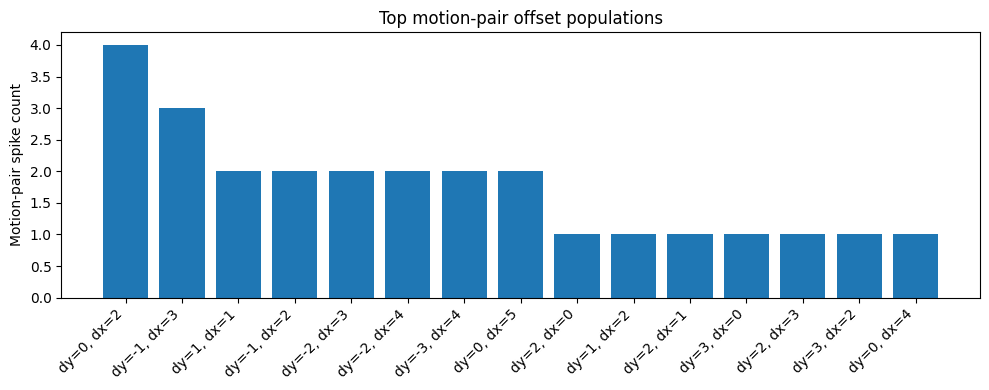

In [26]:
plot_top_motion_pair_scores(result, top_n=15)

In [27]:
def test_motion_pair_estimator(
    shape_name="seven",
    speeds=range(1, 7),
    directions=("right", "left", "down", "up"),
    previous_t=5,
    current_t=6,
    max_offset=6,
):
    rows = []

    for true_speed in speeds:
        for true_direction in directions:
            case = make_unblurred_spike_case(
                speed=true_speed,
                direction_name=true_direction,
                shape_name=shape_name,
            )

            result = estimate_velocity_from_motion_pairs(
                previous_spikes=case["spikes"][previous_t],
                current_spikes=case["spikes"][current_t],
                max_offset=max_offset,
            )

            rows.append({
                "shape": shape_name,
                "true_direction": true_direction,
                "true_speed": true_speed,
                "true_dy": case["velocity_y"],
                "true_dx": case["velocity_x"],
                "estimated_direction": result["estimated_direction"],
                "estimated_speed": result["estimated_speed"],
                "estimated_dy": result["estimated_dy"],
                "estimated_dx": result["estimated_dx"],
                "best_pair_spike_count": result["best_pair_spike_count"],
                "correct_dy": result["estimated_dy"] == case["velocity_y"],
                "correct_dx": result["estimated_dx"] == case["velocity_x"],
                "correct_vector": (
                    result["estimated_dy"] == case["velocity_y"]
                    and result["estimated_dx"] == case["velocity_x"]
                ),
            })

    return pd.DataFrame(rows)

In [28]:
motion_pair_results_seven = test_motion_pair_estimator(
    shape_name="seven",
    speeds=range(1, 7),
    directions=("right", "left", "down", "up"),
    previous_t=5,
    current_t=6,
    max_offset=6,
)

motion_pair_results_seven

,shape,true_direction,true_speed,true_dy,true_dx,estimated_direction,estimated_speed,estimated_dy,estimated_dx,best_pair_spike_count,correct_dy,correct_dx,correct_vector
0,seven,right,1,0,1,right,1.0,0,1,4,True,True,True
1,seven,left,1,0,-1,left,1.0,0,-1,4,True,True,True
2,seven,down,1,1,0,down,1.0,1,0,5,True,True,True
3,seven,up,1,-1,0,up,1.0,-1,0,5,True,True,True
4,seven,right,2,0,2,right,2.0,0,2,4,True,True,True
5,seven,left,2,0,-2,left,2.0,0,-2,4,True,True,True
6,seven,down,2,2,0,down,2.0,2,0,7,True,True,True
7,seven,up,2,-2,0,up,2.0,-2,0,7,True,True,True
8,seven,right,3,0,3,right,3.0,0,3,5,True,True,True
9,seven,left,3,0,-3,left,3.0,0,-3,5,True,True,True


In [29]:
all_shape_results = []

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_motion_pair_estimator(
        shape_name=shape_name,
        speeds=range(1, 7),
        directions=("right", "left", "down", "up"),
        previous_t=5,
        current_t=6,
        max_offset=6,
    )

    all_shape_results.append(result)

motion_pair_results_all_shapes = pd.concat(
    all_shape_results,
    ignore_index=True,
)

motion_pair_results_all_shapes

,shape,true_direction,true_speed,true_dy,true_dx,estimated_direction,estimated_speed,estimated_dy,estimated_dx,best_pair_spike_count,correct_dy,correct_dx,correct_vector
0,seven,right,1,0,1,right,1.0,0,1,4,True,True,True
1,seven,left,1,0,-1,left,1.0,0,-1,4,True,True,True
2,seven,down,1,1,0,down,1.0,1,0,5,True,True,True
3,seven,up,1,-1,0,up,1.0,-1,0,5,True,True,True
4,seven,right,2,0,2,right,2.0,0,2,4,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,box,up,5,-5,0,up,5.0,-5,0,16,True,True,True
92,box,right,6,0,6,right,6.0,0,6,16,True,True,True
93,box,left,6,0,-6,left,6.0,0,-6,16,True,True,True
94,box,down,6,6,0,down,6.0,6,0,16,True,True,True


In [30]:
motion_pair_results_all_shapes.agg(
    vector_accuracy=("correct_vector", "mean"),
    mean_pair_spikes=("best_pair_spike_count", "mean"),
)

,correct_vector,best_pair_spike_count
vector_accuracy,0.958333,NaN
mean_pair_spikes,NaN,7.375


In [31]:
summary = pd.DataFrame([{
    "vector_accuracy": motion_pair_results_all_shapes["correct_vector"].mean(),
    "mean_pair_spikes": motion_pair_results_all_shapes["best_pair_spike_count"].mean(),
    "num_cases": len(motion_pair_results_all_shapes),
    "num_correct": motion_pair_results_all_shapes["correct_vector"].sum(),
    "num_errors": (~motion_pair_results_all_shapes["correct_vector"]).sum(),
}])

summary

,vector_accuracy,mean_pair_spikes,num_cases,num_correct,num_errors
0,0.958333,7.375,96,92,4


In [32]:
motion_pair_failures = motion_pair_results_all_shapes[
    ~motion_pair_results_all_shapes["correct_vector"]
].copy()

motion_pair_failures

,shape,true_direction,true_speed,true_dy,true_dx,estimated_direction,estimated_speed,estimated_dy,estimated_dx,best_pair_spike_count,correct_dy,correct_dx,correct_vector
84,box,right,4,0,4,right,5.0,0,5,8,True,False,False
85,box,left,4,0,-4,left,5.0,0,-5,8,True,False,False
86,box,down,4,4,0,down,5.0,5,0,8,False,True,False
87,box,up,4,-4,0,up,5.0,-5,0,8,False,True,False


In [33]:
motion_pair_failures[[
    "shape",
    "true_direction",
    "true_speed",
    "true_dy",
    "true_dx",
    "estimated_direction",
    "estimated_speed",
    "estimated_dy",
    "estimated_dx",
    "best_pair_spike_count",
]]

,shape,true_direction,true_speed,true_dy,true_dx,estimated_direction,estimated_speed,estimated_dy,estimated_dx,best_pair_spike_count
84,box,right,4,0,4,right,5.0,0,5,8
85,box,left,4,0,-4,left,5.0,0,-5,8
86,box,down,4,4,0,down,5.0,5,0,8
87,box,up,4,-4,0,up,5.0,-5,0,8


In [34]:
case = make_unblurred_spike_case(
    speed=4,
    direction_name="right",
    shape_name="box",
)

result = estimate_velocity_from_motion_pairs(
    previous_spikes=case["spikes"][5],
    current_spikes=case["spikes"][6],
    max_offset=6,
)

print("True dx:", case["velocity_x"])
print("Estimated dx:", result["estimated_dx"])

result["motion_pair_scores"].head(20)

True dx: 4
Estimated dx: 5


,dy,dx,pair_spike_count,offset_magnitude
0,0,5,8,5.000000
1,0,4,6,4.000000
2,0,6,6,6.000000
3,0,3,4,3.000000
4,-4,5,4,6.403124
5,4,5,4,6.403124
6,-4,4,3,5.656854
7,4,4,3,5.656854
8,-4,6,3,7.211103
9,4,6,3,7.211103


In [35]:
def compare_box_speeds_difference_and_motion_pairs(
    speeds=(3, 4, 5),
    direction_name="right",
    previous_t=5,
    current_t=6,
    max_offset=6,
):
    for speed in speeds:
        case = make_unblurred_spike_case(
            speed=speed,
            direction_name=direction_name,
            shape_name="box",
        )

        result = estimate_velocity_from_motion_pairs(
            previous_spikes=case["spikes"][previous_t],
            current_spikes=case["spikes"][current_t],
            max_offset=max_offset,
        )

        diff = result["difference_layer"]
        signed_difference = diff["on_spikes"] - diff["off_spikes"]

        print("=" * 80)
        print(f"BOX | true direction={direction_name} | true speed={speed}")
        print(f"Estimated dy={result['estimated_dy']}, dx={result['estimated_dx']}")
        print(f"Estimated speed={result['estimated_speed']}")
        print(f"Estimated direction={result['estimated_direction']}")
        print(f"Best pair spike count={result['best_pair_spike_count']}")
        print()
        print("Top motion-pair offsets:")
        display(result["motion_pair_scores"].head(10))

        fig, axes = plt.subplots(1, 5, figsize=(16, 3))

        axes[0].imshow(case["spikes"][previous_t], cmap="gray", vmin=0, vmax=1)
        axes[0].set_title(f"Previous spikes\nt={previous_t}")

        axes[1].imshow(case["spikes"][current_t], cmap="gray", vmin=0, vmax=1)
        axes[1].set_title(f"Current spikes\nt={current_t}")

        axes[2].imshow(diff["off_spikes"], cmap="gray", vmin=0, vmax=1)
        axes[2].set_title(f"OFF\ncount={int(diff['off_spikes'].sum().item())}")

        axes[3].imshow(diff["on_spikes"], cmap="gray", vmin=0, vmax=1)
        axes[3].set_title(f"ON\ncount={int(diff['on_spikes'].sum().item())}")

        axes[4].imshow(signed_difference, cmap="bwr", vmin=-1, vmax=1)
        axes[4].set_title("Signed diff\nOFF=-1, ON=+1")

        for ax in axes:
            ax.set_xticks([])
            ax.set_yticks([])

        plt.suptitle(
            f"Box speed {speed}, direction {direction_name}: difference layer"
        )
        plt.tight_layout()
        plt.show()

BOX | true direction=right | true speed=3
Estimated dy=0, dx=3
Estimated speed=3.0
Estimated direction=right
Best pair spike count=8

Top motion-pair offsets:


,dy,dx,pair_spike_count,offset_magnitude
0,0,3,8,3.000000
1,-1,3,6,3.162278
2,1,3,6,3.162278
3,0,5,6,5.000000
4,-2,3,4,3.605551
5,2,3,4,3.605551
6,0,4,4,4.000000
7,0,6,4,6.000000
8,0,-1,3,1.000000
9,-4,5,3,6.403124


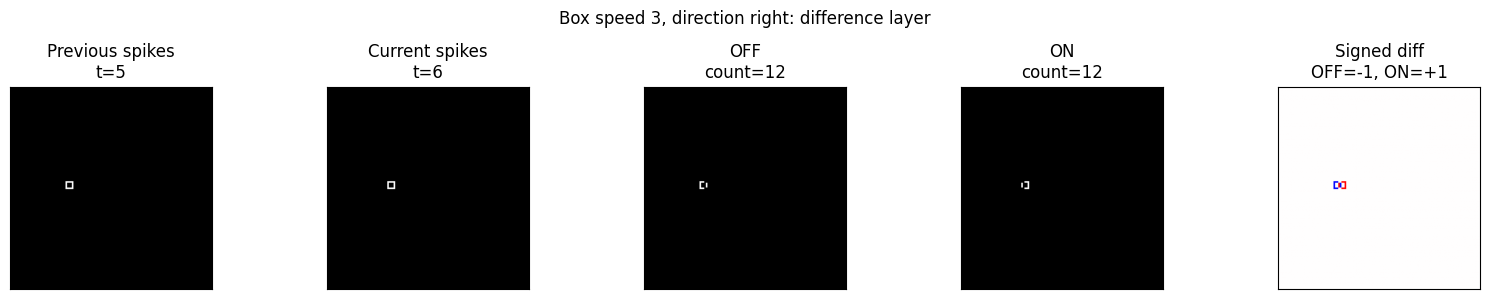

BOX | true direction=right | true speed=4
Estimated dy=0, dx=5
Estimated speed=5.0
Estimated direction=right
Best pair spike count=8

Top motion-pair offsets:


,dy,dx,pair_spike_count,offset_magnitude
0,0,5,8,5.000000
1,0,4,6,4.000000
2,0,6,6,6.000000
3,0,3,4,3.000000
4,-4,5,4,6.403124
5,4,5,4,6.403124
6,-4,4,3,5.656854
7,4,4,3,5.656854
8,-4,6,3,7.211103
9,4,6,3,7.211103


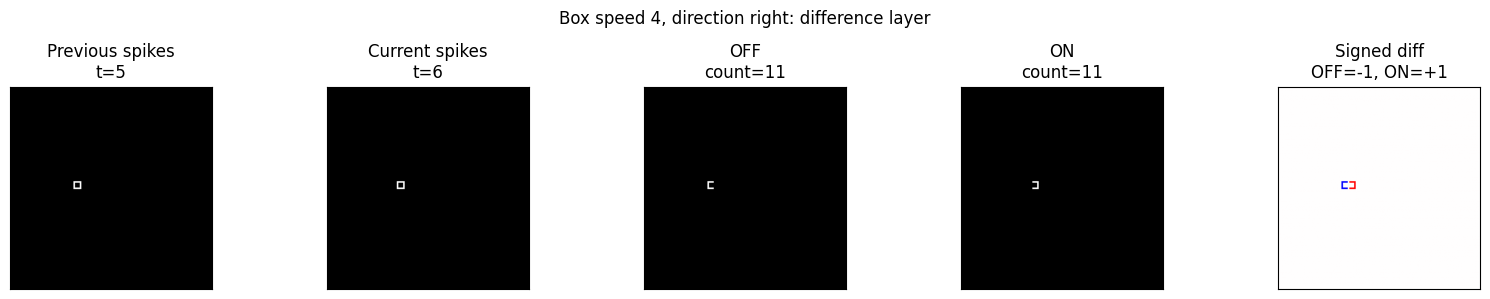

BOX | true direction=right | true speed=5
Estimated dy=0, dx=5
Estimated speed=5.0
Estimated direction=right
Best pair spike count=16

Top motion-pair offsets:


,dy,dx,pair_spike_count,offset_magnitude
0,0,5,16,5.000000
1,0,4,8,4.000000
2,-1,5,8,5.099020
3,1,5,8,5.099020
4,0,6,8,6.000000
5,0,3,6,3.000000
6,-2,5,6,5.385165
7,2,5,6,5.385165
8,0,1,5,1.000000
9,-4,5,5,6.403124


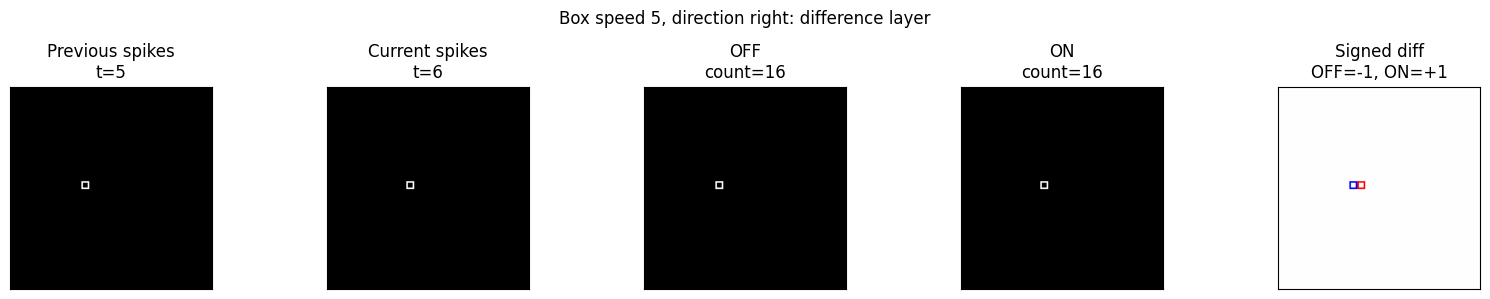

In [36]:
compare_box_speeds_difference_and_motion_pairs(
    speeds=(3, 4, 5),
    direction_name="right",
    previous_t=5,
    current_t=6,
    max_offset=6,
)

In [37]:
def compare_box_speeds_zoomed(
    speeds=(3, 4, 5),
    direction_name="right",
    previous_t=5,
    current_t=6,
    max_offset=6,
    padding=8,
):
    for speed in speeds:
        case = make_unblurred_spike_case(
            speed=speed,
            direction_name=direction_name,
            shape_name="box",
        )

        result = estimate_velocity_from_motion_pairs(
            previous_spikes=case["spikes"][previous_t],
            current_spikes=case["spikes"][current_t],
            max_offset=max_offset,
        )

        diff = result["difference_layer"]
        signed_difference = diff["on_spikes"] - diff["off_spikes"]

        previous_spikes = case["spikes"][previous_t]
        current_spikes = case["spikes"][current_t]

        combined = (
            previous_spikes
            + current_spikes
            + diff["off_spikes"]
            + diff["on_spikes"]
        )

        active_positions = torch.nonzero(combined > 0, as_tuple=False)

        y_min = max(0, int(active_positions[:, 0].min().item()) - padding)
        y_max = min(CANVAS_HEIGHT, int(active_positions[:, 0].max().item()) + padding + 1)
        x_min = max(0, int(active_positions[:, 1].min().item()) - padding)
        x_max = min(CANVAS_WIDTH, int(active_positions[:, 1].max().item()) + padding + 1)

        print("=" * 80)
        print(f"BOX | true direction={direction_name} | true speed={speed}")
        print(f"Estimated dy={result['estimated_dy']}, dx={result['estimated_dx']}")
        print(f"Estimated speed={result['estimated_speed']}")
        print(f"Estimated direction={result['estimated_direction']}")
        print(f"Best pair spike count={result['best_pair_spike_count']}")
        print()
        display(result["motion_pair_scores"].head(10))

        fig, axes = plt.subplots(1, 5, figsize=(16, 3))

        images = [
            previous_spikes,
            current_spikes,
            diff["off_spikes"],
            diff["on_spikes"],
            signed_difference,
        ]

        titles = [
            f"Previous\nt={previous_t}",
            f"Current\nt={current_t}",
            f"OFF\ncount={int(diff['off_spikes'].sum().item())}",
            f"ON\ncount={int(diff['on_spikes'].sum().item())}",
            "Signed diff\nOFF=-1, ON=+1",
        ]

        cmaps = ["gray", "gray", "gray", "gray", "bwr"]
        vmins = [0, 0, 0, 0, -1]
        vmaxs = [1, 1, 1, 1, 1]

        for i, ax in enumerate(axes):
            ax.imshow(
                images[i][y_min:y_max, x_min:x_max],
                cmap=cmaps[i],
                vmin=vmins[i],
                vmax=vmaxs[i],
            )
            ax.set_title(titles[i])
            ax.set_xticks([])
            ax.set_yticks([])

        plt.suptitle(
            f"Zoomed box speed {speed}, direction {direction_name}"
        )
        plt.tight_layout()
        plt.show()

BOX | true direction=right | true speed=3
Estimated dy=0, dx=3
Estimated speed=3.0
Estimated direction=right
Best pair spike count=8



,dy,dx,pair_spike_count,offset_magnitude
0,0,3,8,3.000000
1,-1,3,6,3.162278
2,1,3,6,3.162278
3,0,5,6,5.000000
4,-2,3,4,3.605551
5,2,3,4,3.605551
6,0,4,4,4.000000
7,0,6,4,6.000000
8,0,-1,3,1.000000
9,-4,5,3,6.403124


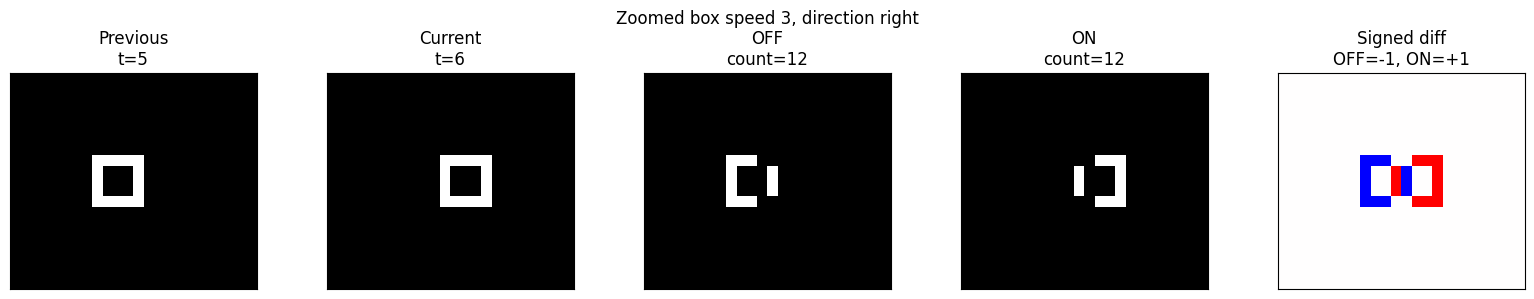

BOX | true direction=right | true speed=4
Estimated dy=0, dx=5
Estimated speed=5.0
Estimated direction=right
Best pair spike count=8



,dy,dx,pair_spike_count,offset_magnitude
0,0,5,8,5.000000
1,0,4,6,4.000000
2,0,6,6,6.000000
3,0,3,4,3.000000
4,-4,5,4,6.403124
5,4,5,4,6.403124
6,-4,4,3,5.656854
7,4,4,3,5.656854
8,-4,6,3,7.211103
9,4,6,3,7.211103


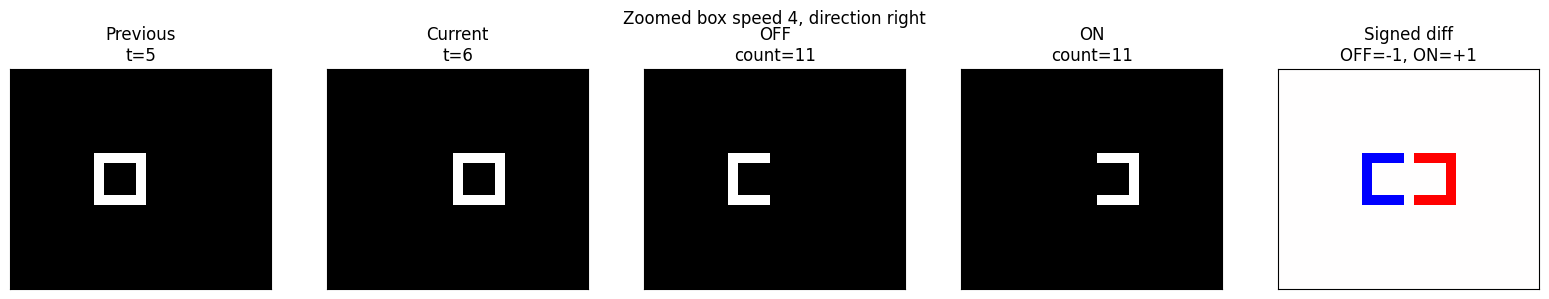

BOX | true direction=right | true speed=5
Estimated dy=0, dx=5
Estimated speed=5.0
Estimated direction=right
Best pair spike count=16



,dy,dx,pair_spike_count,offset_magnitude
0,0,5,16,5.000000
1,0,4,8,4.000000
2,-1,5,8,5.099020
3,1,5,8,5.099020
4,0,6,8,6.000000
5,0,3,6,3.000000
6,-2,5,6,5.385165
7,2,5,6,5.385165
8,0,1,5,1.000000
9,-4,5,5,6.403124


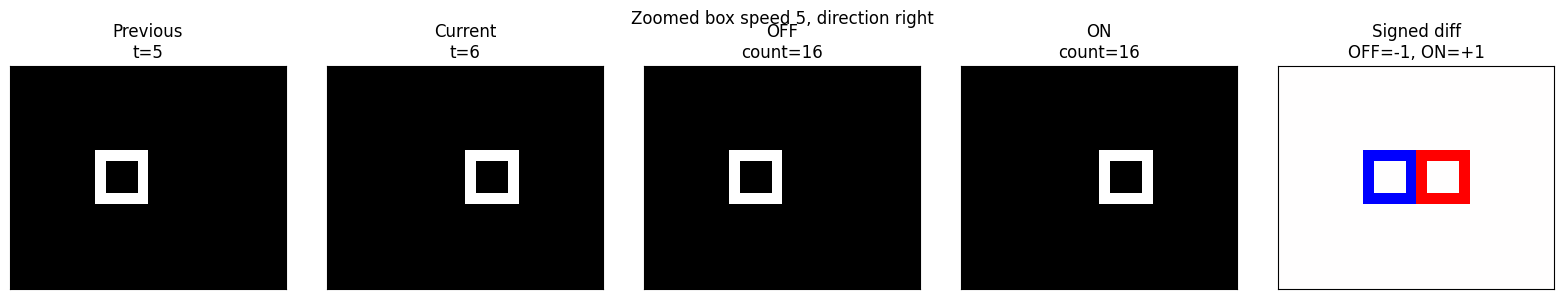

In [41]:
compare_box_speeds_zoomed(
    speeds=(3, 4, 5),
    direction_name="right",
    previous_t=5,
    current_t=6,
    max_offset=6,
    padding=8,
)

The box left edge moves to the position where its right edge was at speed=4. That creates lost information int he ON/OFF spikes and thats why for this specific shape/speed, the estimation is off. 

In [42]:
def compute_motion_pair_layer_with_same_as_activity(
    off_spikes,
    on_spikes,
    same_spikes,
    max_offset=6,
):
    """
    Motion-pair layer using ON, OFF, and SAME populations.

    Previous-side evidence:
        OFF + SAME

    Current-side evidence:
        ON + SAME

    For each offset (dy, dx), count:
        previous_evidence[y, x] and current_evidence[y + dy, x + dx]
    """

    previous_evidence = ((off_spikes > 0) | (same_spikes > 0)).float()
    current_evidence = ((on_spikes > 0) | (same_spikes > 0)).float()

    height, width = previous_evidence.shape
    rows = []

    previous_positions = torch.nonzero(previous_evidence > 0, as_tuple=False)

    for dy in range(-max_offset, max_offset + 1):
        for dx in range(-max_offset, max_offset + 1):
            if dy == 0 and dx == 0:
                continue

            pair_count = 0

            for pos in previous_positions:
                y = int(pos[0].item())
                x = int(pos[1].item())

                target_y = y + dy
                target_x = x + dx

                if 0 <= target_y < height and 0 <= target_x < width:
                    if current_evidence[target_y, target_x] > 0:
                        pair_count += 1

            rows.append({
                "dy": dy,
                "dx": dx,
                "pair_spike_count": pair_count,
                "offset_magnitude": (dy ** 2 + dx ** 2) ** 0.5,
            })

    motion_pair_scores = pd.DataFrame(rows)

    motion_pair_scores = motion_pair_scores.sort_values(
        ["pair_spike_count", "offset_magnitude"],
        ascending=[False, True],
    ).reset_index(drop=True)

    return motion_pair_scores

In [43]:
def estimate_velocity_from_motion_pairs_with_same_as_activity(
    previous_spikes,
    current_spikes,
    max_offset=6,
):
    diff = compute_on_off_difference_layer(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
    )

    motion_scores = compute_motion_pair_layer_with_same_as_activity(
        off_spikes=diff["off_spikes"],
        on_spikes=diff["on_spikes"],
        same_spikes=diff["same_spikes"],
        max_offset=max_offset,
    )

    best = motion_scores.iloc[0]

    estimated_dy = int(best["dy"])
    estimated_dx = int(best["dx"])
    estimated_speed = (estimated_dy ** 2 + estimated_dx ** 2) ** 0.5

    if estimated_dx == 0 and estimated_dy == 0:
        estimated_direction = "none"
    elif abs(estimated_dx) >= abs(estimated_dy):
        if estimated_dx > 0:
            estimated_direction = "right" if estimated_dy == 0 else ("down-right" if estimated_dy > 0 else "up-right")
        else:
            estimated_direction = "left" if estimated_dy == 0 else ("down-left" if estimated_dy > 0 else "up-left")
    else:
        if estimated_dy > 0:
            estimated_direction = "down" if estimated_dx == 0 else ("down-right" if estimated_dx > 0 else "down-left")
        else:
            estimated_direction = "up" if estimated_dx == 0 else ("up-right" if estimated_dx > 0 else "up-left")

    return {
        "estimated_dy": estimated_dy,
        "estimated_dx": estimated_dx,
        "estimated_speed": estimated_speed,
        "estimated_direction": estimated_direction,
        "best_pair_spike_count": int(best["pair_spike_count"]),
        "difference_layer": diff,
        "motion_pair_scores": motion_scores,
    }

In [44]:
case = make_unblurred_spike_case(
    speed=4,
    direction_name="right",
    shape_name="box",
)

result_same_activity = estimate_velocity_from_motion_pairs_with_same_as_activity(
    previous_spikes=case["spikes"][5],
    current_spikes=case["spikes"][6],
    max_offset=6,
)

print("True dx:", case["velocity_x"])
print("Estimated dx:", result_same_activity["estimated_dx"])
print("Estimated speed:", result_same_activity["estimated_speed"])
print("Estimated direction:", result_same_activity["estimated_direction"])

result_same_activity["motion_pair_scores"].head(15)

True dx: 4
Estimated dx: 4
Estimated speed: 4.0
Estimated direction: right


,dy,dx,pair_spike_count,offset_magnitude
0,0,4,16,4.000000
1,0,3,8,3.000000
2,-1,4,8,4.123106
3,1,4,8,4.123106
4,0,5,8,5.000000
5,0,2,6,2.000000
6,-2,4,6,4.472136
7,2,4,6,4.472136
8,0,6,6,6.000000
9,-4,4,5,5.656854


In [45]:
def test_motion_pair_estimator_with_same_as_activity(
    shape_name="seven",
    speeds=range(1, 7),
    directions=("right", "left", "down", "up"),
    previous_t=5,
    current_t=6,
    max_offset=6,
):
    rows = []

    for true_speed in speeds:
        for true_direction in directions:
            case = make_unblurred_spike_case(
                speed=true_speed,
                direction_name=true_direction,
                shape_name=shape_name,
            )

            result = estimate_velocity_from_motion_pairs_with_same_as_activity(
                previous_spikes=case["spikes"][previous_t],
                current_spikes=case["spikes"][current_t],
                max_offset=max_offset,
            )

            rows.append({
                "shape": shape_name,
                "true_direction": true_direction,
                "true_speed": true_speed,
                "true_dy": case["velocity_y"],
                "true_dx": case["velocity_x"],
                "estimated_direction": result["estimated_direction"],
                "estimated_speed": result["estimated_speed"],
                "estimated_dy": result["estimated_dy"],
                "estimated_dx": result["estimated_dx"],
                "best_pair_spike_count": result["best_pair_spike_count"],
                "correct_dy": result["estimated_dy"] == case["velocity_y"],
                "correct_dx": result["estimated_dx"] == case["velocity_x"],
                "correct_vector": (
                    result["estimated_dy"] == case["velocity_y"]
                    and result["estimated_dx"] == case["velocity_x"]
                ),
            })

    return pd.DataFrame(rows)

In [46]:
all_shape_results_same_activity = []

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_motion_pair_estimator_with_same_as_activity(
        shape_name=shape_name,
        speeds=range(1, 7),
        directions=("right", "left", "down", "up"),
        previous_t=5,
        current_t=6,
        max_offset=6,
    )

    all_shape_results_same_activity.append(result)

motion_pair_results_all_shapes_same_activity = pd.concat(
    all_shape_results_same_activity,
    ignore_index=True,
)

motion_pair_results_all_shapes_same_activity

,shape,true_direction,true_speed,true_dy,true_dx,estimated_direction,estimated_speed,estimated_dy,estimated_dx,best_pair_spike_count,correct_dy,correct_dx,correct_vector
0,seven,right,1,0,1,right,1.0,0,1,9,True,True,True
1,seven,left,1,0,-1,left,1.0,0,-1,9,True,True,True
2,seven,down,1,1,0,down,1.0,1,0,9,True,True,True
3,seven,up,1,-1,0,up,1.0,-1,0,9,True,True,True
4,seven,right,2,0,2,right,2.0,0,2,9,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,box,up,5,-5,0,up,5.0,-5,0,16,True,True,True
92,box,right,6,0,6,right,6.0,0,6,16,True,True,True
93,box,left,6,0,-6,left,6.0,0,-6,16,True,True,True
94,box,down,6,6,0,down,6.0,6,0,16,True,True,True


In [47]:
summary_same_activity = pd.DataFrame([{
    "vector_accuracy": motion_pair_results_all_shapes_same_activity["correct_vector"].mean(),
    "direction_accuracy": (
        motion_pair_results_all_shapes_same_activity["estimated_direction"]
        == motion_pair_results_all_shapes_same_activity["true_direction"]
    ).mean(),
    "mean_pair_spikes": motion_pair_results_all_shapes_same_activity["best_pair_spike_count"].mean(),
    "num_cases": len(motion_pair_results_all_shapes_same_activity),
    "num_correct": motion_pair_results_all_shapes_same_activity["correct_vector"].sum(),
    "num_errors": (~motion_pair_results_all_shapes_same_activity["correct_vector"]).sum(),
}])

summary_same_activity

,vector_accuracy,direction_accuracy,mean_pair_spikes,num_cases,num_correct,num_errors
0,1.0,1.0,10.75,96,96,0


## Version 1 checkpoint: ON/OFF/SAME motion-pair estimator

At this point, the model uses two consecutive binary spike frames:

- `S[t-1]`
- `S[t]`

The difference layer creates three event populations:

- `OFF`: active at `t-1`, inactive at `t`
- `ON`: inactive at `t-1`, active at `t`
- `SAME`: active at both `t-1` and `t`

The original ON/OFF-only model counted local `OFF → ON` event pairs for each spatial offset. This worked for most cases, but failed for the box at speed 4 because one edge of the box moved into a location that was already active. That overlapping edge became `SAME`, not `ON` or `OFF`, so the original model ignored useful motion evidence.

The improved model uses:

- previous evidence = `OFF or SAME`
- current evidence = `ON or SAME`

Then it counts local previous-evidence to current-evidence pairs for each spatial offset `(dy, dx)`. The winning offset population gives the estimated velocity vector.

In code, the OR operations are Boolean operations on binary spike arrays. Conceptually, they represent downstream spiking populations receiving convergent input from event neurons.

In [48]:
comparison_summary = pd.DataFrame([
    {
        "model": "OFF-to-ON only",
        "vector_accuracy": motion_pair_results_all_shapes["correct_vector"].mean(),
        "num_correct": int(motion_pair_results_all_shapes["correct_vector"].sum()),
        "num_errors": int((~motion_pair_results_all_shapes["correct_vector"]).sum()),
        "num_cases": len(motion_pair_results_all_shapes),
    },
    {
        "model": "OFF/SAME to ON/SAME",
        "vector_accuracy": motion_pair_results_all_shapes_same_activity["correct_vector"].mean(),
        "num_correct": int(motion_pair_results_all_shapes_same_activity["correct_vector"].sum()),
        "num_errors": int((~motion_pair_results_all_shapes_same_activity["correct_vector"]).sum()),
        "num_cases": len(motion_pair_results_all_shapes_same_activity),
    },
])

comparison_summary

,model,vector_accuracy,num_correct,num_errors,num_cases
0,OFF-to-ON only,0.958333,92,4,96
1,OFF/SAME to ON/SAME,1.000000,96,0,96


In [49]:
motion_pair_failures_same_activity = motion_pair_results_all_shapes_same_activity[
    ~motion_pair_results_all_shapes_same_activity["correct_vector"]
].copy()

motion_pair_failures_same_activity[[
    "shape",
    "true_direction",
    "true_speed",
    "true_dy",
    "true_dx",
    "estimated_direction",
    "estimated_speed",
    "estimated_dy",
    "estimated_dx",
    "best_pair_spike_count",
]]

,shape,true_direction,true_speed,true_dy,true_dx,estimated_direction,estimated_speed,estimated_dy,estimated_dx,best_pair_spike_count


In [50]:
print(
    "Number of failures:",
    len(motion_pair_failures_same_activity)
)

Number of failures: 0


In [51]:
shape_summary_same_activity = (
    motion_pair_results_all_shapes_same_activity
    .assign(
        correct_direction=lambda df: (
            df["estimated_direction"] == df["true_direction"]
        )
    )
    .groupby("shape")
    .agg(
        vector_accuracy=("correct_vector", "mean"),
        direction_accuracy=("correct_direction", "mean"),
        mean_pair_spikes=("best_pair_spike_count", "mean"),
        num_cases=("correct_vector", "count"),
    )
    .reset_index()
)

shape_summary_same_activity

,shape,vector_accuracy,direction_accuracy,mean_pair_spikes,num_cases
0,box,1.0,1.0,16.0,24
1,ell,1.0,1.0,9.0,24
2,seven,1.0,1.0,9.0,24
3,tee,1.0,1.0,9.0,24


In [53]:
speed_summary_same_activity = (
    motion_pair_results_all_shapes_same_activity
    .assign(
        correct_direction=lambda df: (
            df["estimated_direction"] == df["true_direction"]
        )
    )
    .groupby("true_speed")
    .agg(
        vector_accuracy=("correct_vector", "mean"),
        direction_accuracy=("correct_direction", "mean"),
        mean_pair_spikes=("best_pair_spike_count", "mean"),
        num_cases=("correct_vector", "count"),
    )
    .reset_index()
)

speed_summary_same_activity

,true_speed,vector_accuracy,direction_accuracy,mean_pair_spikes,num_cases
0,1,1.0,1.0,10.75,16
1,2,1.0,1.0,10.75,16
2,3,1.0,1.0,10.75,16
3,4,1.0,1.0,10.75,16
4,5,1.0,1.0,10.75,16
5,6,1.0,1.0,10.75,16


In [52]:
def compare_original_vs_same_activity_for_case(
    shape_name="box",
    speed=4,
    direction_name="right",
    previous_t=5,
    current_t=6,
    max_offset=6,
):
    case = make_unblurred_spike_case(
        speed=speed,
        direction_name=direction_name,
        shape_name=shape_name,
    )

    original_result = estimate_velocity_from_motion_pairs(
        previous_spikes=case["spikes"][previous_t],
        current_spikes=case["spikes"][current_t],
        max_offset=max_offset,
    )

    same_activity_result = estimate_velocity_from_motion_pairs_with_same_as_activity(
        previous_spikes=case["spikes"][previous_t],
        current_spikes=case["spikes"][current_t],
        max_offset=max_offset,
    )

    diff = original_result["difference_layer"]

    print("=" * 80)
    print(f"Shape={shape_name}, direction={direction_name}, true speed={speed}")
    print()
    print("Original OFF-to-ON model:")
    print(
        "estimated dy:",
        original_result["estimated_dy"],
        "estimated dx:",
        original_result["estimated_dx"],
        "estimated speed:",
        original_result["estimated_speed"],
    )
    display(original_result["motion_pair_scores"].head(10))

    print()
    print("Improved OFF/SAME-to-ON/SAME model:")
    print(
        "estimated dy:",
        same_activity_result["estimated_dy"],
        "estimated dx:",
        same_activity_result["estimated_dx"],
        "estimated speed:",
        same_activity_result["estimated_speed"],
    )
    display(same_activity_result["motion_pair_scores"].head(10))

    fig, axes = plt.subplots(1, 5, figsize=(16, 3))

    images = [
        case["spikes"][previous_t],
        case["spikes"][current_t],
        diff["off_spikes"],
        diff["on_spikes"],
        diff["same_spikes"],
    ]

    titles = [
        f"Previous spikes\nt={previous_t}",
        f"Current spikes\nt={current_t}",
        "OFF",
        "ON",
        "SAME",
    ]

    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(
        f"Why SAME fixes {shape_name}, speed {speed}, direction {direction_name}"
    )
    plt.tight_layout()
    plt.show()

Shape=box, direction=right, true speed=4

Original OFF-to-ON model:
estimated dy: 0 estimated dx: 5 estimated speed: 5.0


,dy,dx,pair_spike_count,offset_magnitude
0,0,5,8,5.000000
1,0,4,6,4.000000
2,0,6,6,6.000000
3,0,3,4,3.000000
4,-4,5,4,6.403124
5,4,5,4,6.403124
6,-4,4,3,5.656854
7,4,4,3,5.656854
8,-4,6,3,7.211103
9,4,6,3,7.211103



Improved OFF/SAME-to-ON/SAME model:
estimated dy: 0 estimated dx: 4 estimated speed: 4.0


,dy,dx,pair_spike_count,offset_magnitude
0,0,4,16,4.000000
1,0,3,8,3.000000
2,-1,4,8,4.123106
3,1,4,8,4.123106
4,0,5,8,5.000000
5,0,2,6,2.000000
6,-2,4,6,4.472136
7,2,4,6,4.472136
8,0,6,6,6.000000
9,-4,4,5,5.656854


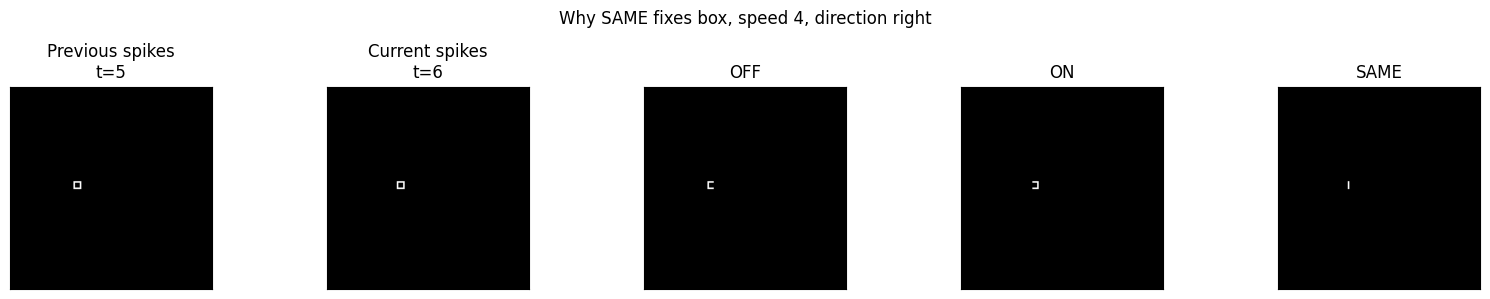

In [54]:
compare_original_vs_same_activity_for_case(
    shape_name="box",
    speed=4,
    direction_name="right",
    previous_t=5,
    current_t=6,
    max_offset=6,
)

### Result

The ON/OFF-only model achieved high accuracy but failed systematically for the box at speed 4. The failure was caused by overlapping activity: one edge of the box moved into a location that was already active, producing a SAME event rather than an ON or OFF event.

After adding SAME neurons and using `OFF/SAME → ON/SAME` motion-pair matching, the model recovered the correct velocity vector for all tested shapes, speeds, and cardinal directions.

This supports the idea that a spike-only event representation can estimate velocity from consecutive frames, but that ON/OFF change events alone may be insufficient when motion creates spatial overlap. Including SAME events preserves overlap information and improves the robustness of the motion-pair readout.

## Testing other directions

In [55]:
def make_unblurred_spike_case_from_velocity(
    velocity_y,
    velocity_x,
    shape_name="seven",
    start_top=50,
    start_left=50,
):
    frames, origins = lu.make_moving_2d_shape(
        shape=SHAPE_TEMPLATES[shape_name],
        canvas_height=CANVAS_HEIGHT,
        canvas_width=CANVAS_WIDTH,
        steps=STEPS,
        start_top=start_top,
        start_left=start_left,
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        intensity=INTENSITY,
    )

    spikes = (frames > 0).float()

    return {
        "shape_name": shape_name,
        "velocity_y": velocity_y,
        "velocity_x": velocity_x,
        "frames": frames,
        "spikes": spikes,
        "origins": origins,
    }

In [56]:
def velocity_vector_to_direction_name(dy, dx):
    if dy == 0 and dx == 0:
        return "none"

    vertical = ""
    horizontal = ""

    if dy > 0:
        vertical = "down"
    elif dy < 0:
        vertical = "up"

    if dx > 0:
        horizontal = "right"
    elif dx < 0:
        horizontal = "left"

    if vertical and horizontal:
        return f"{vertical}-{horizontal}"
    elif vertical:
        return vertical
    else:
        return horizontal

In [57]:
case = make_unblurred_spike_case_from_velocity(
    velocity_y=1,
    velocity_x=2,
    shape_name="seven",
    start_top=50,
    start_left=50,
)

result = estimate_velocity_from_motion_pairs_with_same_as_activity(
    previous_spikes=case["spikes"][5],
    current_spikes=case["spikes"][6],
    max_offset=6,
)

print("True dy:", case["velocity_y"])
print("True dx:", case["velocity_x"])
print("True direction:", velocity_vector_to_direction_name(case["velocity_y"], case["velocity_x"]))
print()
print("Estimated dy:", result["estimated_dy"])
print("Estimated dx:", result["estimated_dx"])
print("Estimated direction:", result["estimated_direction"])
print("Estimated speed:", result["estimated_speed"])
print("Best pair spike count:", result["best_pair_spike_count"])

result["motion_pair_scores"].head(15)

True dy: 1
True dx: 2
True direction: down-right

Estimated dy: 1
Estimated dx: 2
Estimated direction: down-right
Estimated speed: 2.23606797749979
Best pair spike count: 9


,dy,dx,pair_spike_count,offset_magnitude
0,1,2,9,2.236068
1,1,1,4,1.414214
2,1,3,4,3.162278
3,1,0,3,1.000000
4,2,1,3,2.236068
5,0,3,3,3.000000
6,1,4,3,4.123106
7,1,-1,2,1.414214
8,0,2,2,2.000000
9,2,2,2,2.828427


In [58]:
def test_same_activity_estimator_on_velocity_vectors(
    shape_name="seven",
    velocity_values=(-3, -2, -1, 0, 1, 2, 3),
    previous_t=5,
    current_t=6,
    max_offset=6,
    start_top=50,
    start_left=50,
):
    rows = []

    for velocity_y in velocity_values:
        for velocity_x in velocity_values:
            if velocity_y == 0 and velocity_x == 0:
                continue

            case = make_unblurred_spike_case_from_velocity(
                velocity_y=velocity_y,
                velocity_x=velocity_x,
                shape_name=shape_name,
                start_top=start_top,
                start_left=start_left,
            )

            result = estimate_velocity_from_motion_pairs_with_same_as_activity(
                previous_spikes=case["spikes"][previous_t],
                current_spikes=case["spikes"][current_t],
                max_offset=max_offset,
            )

            true_direction = velocity_vector_to_direction_name(
                velocity_y,
                velocity_x,
            )

            rows.append({
                "shape": shape_name,
                "true_dy": velocity_y,
                "true_dx": velocity_x,
                "true_direction": true_direction,
                "true_speed": (velocity_y ** 2 + velocity_x ** 2) ** 0.5,
                "estimated_dy": result["estimated_dy"],
                "estimated_dx": result["estimated_dx"],
                "estimated_direction": result["estimated_direction"],
                "estimated_speed": result["estimated_speed"],
                "best_pair_spike_count": result["best_pair_spike_count"],
                "correct_dy": result["estimated_dy"] == velocity_y,
                "correct_dx": result["estimated_dx"] == velocity_x,
                "correct_vector": (
                    result["estimated_dy"] == velocity_y
                    and result["estimated_dx"] == velocity_x
                ),
                "correct_direction": result["estimated_direction"] == true_direction,
            })

    return pd.DataFrame(rows)

In [59]:
diagonal_results_seven = test_same_activity_estimator_on_velocity_vectors(
    shape_name="seven",
    velocity_values=(-3, -2, -1, 0, 1, 2, 3),
    previous_t=5,
    current_t=6,
    max_offset=6,
    start_top=50,
    start_left=50,
)

diagonal_results_seven

,shape,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_dy,correct_dx,correct_vector,correct_direction
0,seven,-3,-3,up-left,4.242641,-3,-3,up-left,4.242641,9,True,True,True,True
1,seven,-3,-2,up-left,3.605551,-3,-2,up-left,3.605551,9,True,True,True,True
2,seven,-3,-1,up-left,3.162278,-3,-1,up-left,3.162278,9,True,True,True,True
3,seven,-3,0,up,3.000000,-3,0,up,3.000000,9,True,True,True,True
4,seven,-3,1,up-right,3.162278,-3,1,up-right,3.162278,9,True,True,True,True
5,seven,-3,2,up-right,3.605551,-3,2,up-right,3.605551,9,True,True,True,True
6,seven,-3,3,up-right,4.242641,-3,3,up-right,4.242641,9,True,True,True,True
7,seven,-2,-3,up-left,3.605551,-2,-3,up-left,3.605551,9,True,True,True,True
8,seven,-2,-2,up-left,2.828427,-2,-2,up-left,2.828427,9,True,True,True,True
9,seven,-2,-1,up-left,2.236068,-2,-1,up-left,2.236068,9,True,True,True,True


In [61]:
all_diagonal_results = []

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_same_activity_estimator_on_velocity_vectors(
        shape_name=shape_name,
        velocity_values=(-3, -2, -1, 0, 1, 2, 3),
        previous_t=5,
        current_t=6,
        max_offset=6,
        start_top=50,
        start_left=50,
    )

    all_diagonal_results.append(result)

diagonal_results_all_shapes = pd.concat(
    all_diagonal_results,
    ignore_index=True,
)

diagonal_results_all_shapes

,shape,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_dy,correct_dx,correct_vector,correct_direction
0,seven,-3,-3,up-left,4.242641,-3,-3,up-left,4.242641,9,True,True,True,True
1,seven,-3,-2,up-left,3.605551,-3,-2,up-left,3.605551,9,True,True,True,True
2,seven,-3,-1,up-left,3.162278,-3,-1,up-left,3.162278,9,True,True,True,True
3,seven,-3,0,up,3.000000,-3,0,up,3.000000,9,True,True,True,True
4,seven,-3,1,up-right,3.162278,-3,1,up-right,3.162278,9,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,box,3,-1,down-left,3.162278,3,-1,down-left,3.162278,16,True,True,True,True
188,box,3,0,down,3.000000,3,0,down,3.000000,16,True,True,True,True
189,box,3,1,down-right,3.162278,3,1,down-right,3.162278,16,True,True,True,True
190,box,3,2,down-right,3.605551,3,2,down-right,3.605551,16,True,True,True,True


In [64]:
diagonal_summary_all_shapes = pd.DataFrame([{
    "vector_accuracy": diagonal_results_all_shapes["correct_vector"].mean(),
    "direction_accuracy": diagonal_results_all_shapes["correct_direction"].mean(),
    "num_cases": len(diagonal_results_all_shapes),
    "num_correct": int(diagonal_results_all_shapes["correct_vector"].sum()),
    "num_errors": int((~diagonal_results_all_shapes["correct_vector"]).sum()),
}])

diagonal_summary_all_shapes

,vector_accuracy,direction_accuracy,num_cases,num_correct,num_errors
0,1.0,1.0,192,192,0


In [62]:
diagonal_failures_all_shapes = diagonal_results_all_shapes[
    ~diagonal_results_all_shapes["correct_vector"]
].copy()

diagonal_failures_all_shapes[[
    "shape",
    "true_dy",
    "true_dx",
    "true_direction",
    "true_speed",
    "estimated_dy",
    "estimated_dx",
    "estimated_direction",
    "estimated_speed",
    "best_pair_spike_count",
]]

,shape,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count


## Diagonal / 2D velocity result

The ON/OFF/SAME motion-pair estimator was next tested on arbitrary small 2D velocity vectors, including diagonal and asymmetric motions such as `(dy=1, dx=2)` and `(dy=-2, dx=1)`.

The model achieved zero vector-estimation errors across all tested shapes and velocity vectors. This shows that the readout is not limited to four cardinal directions. Instead, the offset-sensitive motion populations estimate the full 2D displacement vector `(dy, dx)` between consecutive spike frames.

In [65]:
diagonal_summary_all_shapes

,vector_accuracy,direction_accuracy,num_cases,num_correct,num_errors
0,1.0,1.0,192,192,0


In [66]:
print("2D velocity benchmark")
print("Number of cases:", len(diagonal_results_all_shapes))
print("Number correct:", int(diagonal_results_all_shapes["correct_vector"].sum()))
print("Number errors:", int((~diagonal_results_all_shapes["correct_vector"]).sum()))
print("Vector accuracy:", diagonal_results_all_shapes["correct_vector"].mean())
print("Direction accuracy:", diagonal_results_all_shapes["correct_direction"].mean())

2D velocity benchmark
Number of cases: 192
Number correct: 192
Number errors: 0
Vector accuracy: 1.0
Direction accuracy: 1.0


## Test other frames

In [67]:
def test_one_case_across_all_frame_pairs(
    shape_name="seven",
    velocity_y=1,
    velocity_x=2,
    max_offset=6,
    start_top=50,
    start_left=50,
):
    case = make_unblurred_spike_case_from_velocity(
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        shape_name=shape_name,
        start_top=start_top,
        start_left=start_left,
    )

    rows = []

    for previous_t in range(STEPS - 1):
        current_t = previous_t + 1

        result = estimate_velocity_from_motion_pairs_with_same_as_activity(
            previous_spikes=case["spikes"][previous_t],
            current_spikes=case["spikes"][current_t],
            max_offset=max_offset,
        )

        rows.append({
            "shape": shape_name,
            "previous_t": previous_t,
            "current_t": current_t,
            "true_dy": velocity_y,
            "true_dx": velocity_x,
            "true_direction": velocity_vector_to_direction_name(velocity_y, velocity_x),
            "true_speed": (velocity_y ** 2 + velocity_x ** 2) ** 0.5,
            "estimated_dy": result["estimated_dy"],
            "estimated_dx": result["estimated_dx"],
            "estimated_direction": result["estimated_direction"],
            "estimated_speed": result["estimated_speed"],
            "best_pair_spike_count": result["best_pair_spike_count"],
            "correct_vector": (
                result["estimated_dy"] == velocity_y
                and result["estimated_dx"] == velocity_x
            ),
            "correct_direction": (
                result["estimated_direction"]
                == velocity_vector_to_direction_name(velocity_y, velocity_x)
            ),
        })

    return pd.DataFrame(rows)

In [68]:
one_temporal_test = test_one_case_across_all_frame_pairs(
    shape_name="seven",
    velocity_y=1,
    velocity_x=2,
    max_offset=6,
    start_top=50,
    start_left=50,
)

one_temporal_test

,shape,previous_t,current_t,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_vector,correct_direction
0,seven,0,1,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True
1,seven,1,2,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True
2,seven,2,3,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True
3,seven,3,4,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True
4,seven,4,5,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True
5,seven,5,6,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True


In [69]:
def test_same_activity_estimator_all_frame_pairs(
    shape_name="seven",
    velocity_values=(-3, -2, -1, 0, 1, 2, 3),
    max_offset=6,
    start_top=50,
    start_left=50,
):
    rows = []

    for velocity_y in velocity_values:
        for velocity_x in velocity_values:
            if velocity_y == 0 and velocity_x == 0:
                continue

            case = make_unblurred_spike_case_from_velocity(
                velocity_y=velocity_y,
                velocity_x=velocity_x,
                shape_name=shape_name,
                start_top=start_top,
                start_left=start_left,
            )

            true_direction = velocity_vector_to_direction_name(
                velocity_y,
                velocity_x,
            )

            for previous_t in range(STEPS - 1):
                current_t = previous_t + 1

                result = estimate_velocity_from_motion_pairs_with_same_as_activity(
                    previous_spikes=case["spikes"][previous_t],
                    current_spikes=case["spikes"][current_t],
                    max_offset=max_offset,
                )

                rows.append({
                    "shape": shape_name,
                    "previous_t": previous_t,
                    "current_t": current_t,
                    "true_dy": velocity_y,
                    "true_dx": velocity_x,
                    "true_direction": true_direction,
                    "true_speed": (velocity_y ** 2 + velocity_x ** 2) ** 0.5,
                    "estimated_dy": result["estimated_dy"],
                    "estimated_dx": result["estimated_dx"],
                    "estimated_direction": result["estimated_direction"],
                    "estimated_speed": result["estimated_speed"],
                    "best_pair_spike_count": result["best_pair_spike_count"],
                    "correct_dy": result["estimated_dy"] == velocity_y,
                    "correct_dx": result["estimated_dx"] == velocity_x,
                    "correct_vector": (
                        result["estimated_dy"] == velocity_y
                        and result["estimated_dx"] == velocity_x
                    ),
                    "correct_direction": result["estimated_direction"] == true_direction,
                })

    return pd.DataFrame(rows)

In [70]:
all_frame_pair_results = []

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_same_activity_estimator_all_frame_pairs(
        shape_name=shape_name,
        velocity_values=(-3, -2, -1, 0, 1, 2, 3),
        max_offset=6,
        start_top=50,
        start_left=50,
    )

    all_frame_pair_results.append(result)

all_frame_pair_results = pd.concat(
    all_frame_pair_results,
    ignore_index=True,
)

all_frame_pair_results

,shape,previous_t,current_t,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_dy,correct_dx,correct_vector,correct_direction
0,seven,0,1,-3,-3,up-left,4.242641,-3,-3,up-left,4.242641,9,True,True,True,True
1,seven,1,2,-3,-3,up-left,4.242641,-3,-3,up-left,4.242641,9,True,True,True,True
2,seven,2,3,-3,-3,up-left,4.242641,-3,-3,up-left,4.242641,9,True,True,True,True
3,seven,3,4,-3,-3,up-left,4.242641,-3,-3,up-left,4.242641,9,True,True,True,True
4,seven,4,5,-3,-3,up-left,4.242641,-3,-3,up-left,4.242641,9,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,box,1,2,3,3,down-right,4.242641,3,3,down-right,4.242641,16,True,True,True,True
1148,box,2,3,3,3,down-right,4.242641,3,3,down-right,4.242641,16,True,True,True,True
1149,box,3,4,3,3,down-right,4.242641,3,3,down-right,4.242641,16,True,True,True,True
1150,box,4,5,3,3,down-right,4.242641,3,3,down-right,4.242641,16,True,True,True,True


In [71]:
all_frame_pair_summary = pd.DataFrame([{
    "vector_accuracy": all_frame_pair_results["correct_vector"].mean(),
    "direction_accuracy": all_frame_pair_results["correct_direction"].mean(),
    "num_cases": len(all_frame_pair_results),
    "num_correct": int(all_frame_pair_results["correct_vector"].sum()),
    "num_errors": int((~all_frame_pair_results["correct_vector"]).sum()),
}])

all_frame_pair_summary

,vector_accuracy,direction_accuracy,num_cases,num_correct,num_errors
0,1.0,1.0,1152,1152,0


In [73]:
print("All-frame-pair benchmark")
print("Number of cases:", len(all_frame_pair_results))
print("Number correct:", int(all_frame_pair_results["correct_vector"].sum()))
print("Number errors:", int((~all_frame_pair_results["correct_vector"]).sum()))
print("Vector accuracy:", all_frame_pair_results["correct_vector"].mean())
print("Direction accuracy:", all_frame_pair_results["correct_direction"].mean())

All-frame-pair benchmark
Number of cases: 1152
Number correct: 1152
Number errors: 0
Vector accuracy: 1.0
Direction accuracy: 1.0


## Now variable velocities

In [74]:
def make_variable_velocity_spike_case(
    velocity_sequence,
    shape_name="seven",
    start_top=50,
    start_left=50,
):
    """
    Create a spike sequence where velocity can change at every transition.

    velocity_sequence:
        list of (velocity_y, velocity_x) values

    If velocity_sequence has length N, the output has N+1 frames.
    """

    shape = SHAPE_TEMPLATES[shape_name]

    positions = [(start_top, start_left)]

    current_top = start_top
    current_left = start_left

    for velocity_y, velocity_x in velocity_sequence:
        current_top = current_top + velocity_y
        current_left = current_left + velocity_x
        positions.append((current_top, current_left))

    frames = []

    for top, left in positions:
        frame = torch.zeros(
            (CANVAS_HEIGHT, CANVAS_WIDTH),
            dtype=torch.float32,
        )

        shape_height, shape_width = shape.shape

        top = int(top)
        left = int(left)

        frame[
            top:top + shape_height,
            left:left + shape_width,
        ] = shape.float() * INTENSITY

        frames.append(frame)

    frames = torch.stack(frames, dim=0)
    spikes = (frames > 0).float()

    return {
        "shape_name": shape_name,
        "velocity_sequence": velocity_sequence,
        "positions": positions,
        "frames": frames,
        "spikes": spikes,
    }

In [78]:
def plot_input_next_to_spikes_general(case, title=None):
    frames = case["frames"]
    spikes = case["spikes"]

    num_steps = frames.shape[0]

    fig, axes = plt.subplots(2, num_steps, figsize=(2.5 * num_steps, 5))

    for t in range(num_steps):
        axes[0, t].imshow(frames[t], cmap="gray", vmin=0, vmax=1)
        axes[0, t].set_title(f"Input t={t}")
        axes[0, t].set_xticks([])
        axes[0, t].set_yticks([])

        axes[1, t].imshow(spikes[t], cmap="gray", vmin=0, vmax=1)
        axes[1, t].set_title(
            f"Spikes t={t}\ncount={int(spikes[t].sum().item())}"
        )
        axes[1, t].set_xticks([])
        axes[1, t].set_yticks([])

    if title is None:
        if "velocity_sequence" in case:
            title = (
                f"Variable-velocity case: {case['shape_name']}\n"
                f"velocity sequence = {case['velocity_sequence']}"
            )
        elif "direction_name" in case and "speed" in case:
            title = (
                f"Input vs spikes: {case['shape_name']}, "
                f"{case['direction_name']}, speed {case['speed']}"
            )
        elif "velocity_y" in case and "velocity_x" in case:
            title = (
                f"Input vs spikes: {case['shape_name']}, "
                f"velocity dy={case['velocity_y']}, dx={case['velocity_x']}"
            )
        else:
            title = f"Input vs spikes: {case.get('shape_name', 'unknown shape')}"

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [80]:
def plot_input_next_to_spikes_zoomed(case, padding=8, title=None):
    frames = case["frames"]
    spikes = case["spikes"]

    num_steps = frames.shape[0]

    active_positions = torch.nonzero(spikes.sum(dim=0) > 0, as_tuple=False)

    if active_positions.numel() == 0:
        print("No active pixels found.")
        return

    y_min = max(0, int(active_positions[:, 0].min().item()) - padding)
    y_max = min(CANVAS_HEIGHT, int(active_positions[:, 0].max().item()) + padding + 1)
    x_min = max(0, int(active_positions[:, 1].min().item()) - padding)
    x_max = min(CANVAS_WIDTH, int(active_positions[:, 1].max().item()) + padding + 1)

    fig, axes = plt.subplots(2, num_steps, figsize=(2.5 * num_steps, 5))

    for t in range(num_steps):
        axes[0, t].imshow(
            frames[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[0, t].set_title(f"Input t={t}")
        axes[0, t].set_xticks([])
        axes[0, t].set_yticks([])

        axes[1, t].imshow(
            spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[1, t].set_title(
            f"Spikes t={t}\ncount={int(spikes[t].sum().item())}"
        )
        axes[1, t].set_xticks([])
        axes[1, t].set_yticks([])

    if title is None:
        if "velocity_sequence" in case:
            title = (
                f"Zoomed variable-velocity case: {case['shape_name']}\n"
                f"velocity sequence = {case['velocity_sequence']}"
            )
        else:
            title = f"Zoomed input vs spikes: {case.get('shape_name', 'unknown shape')}"

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

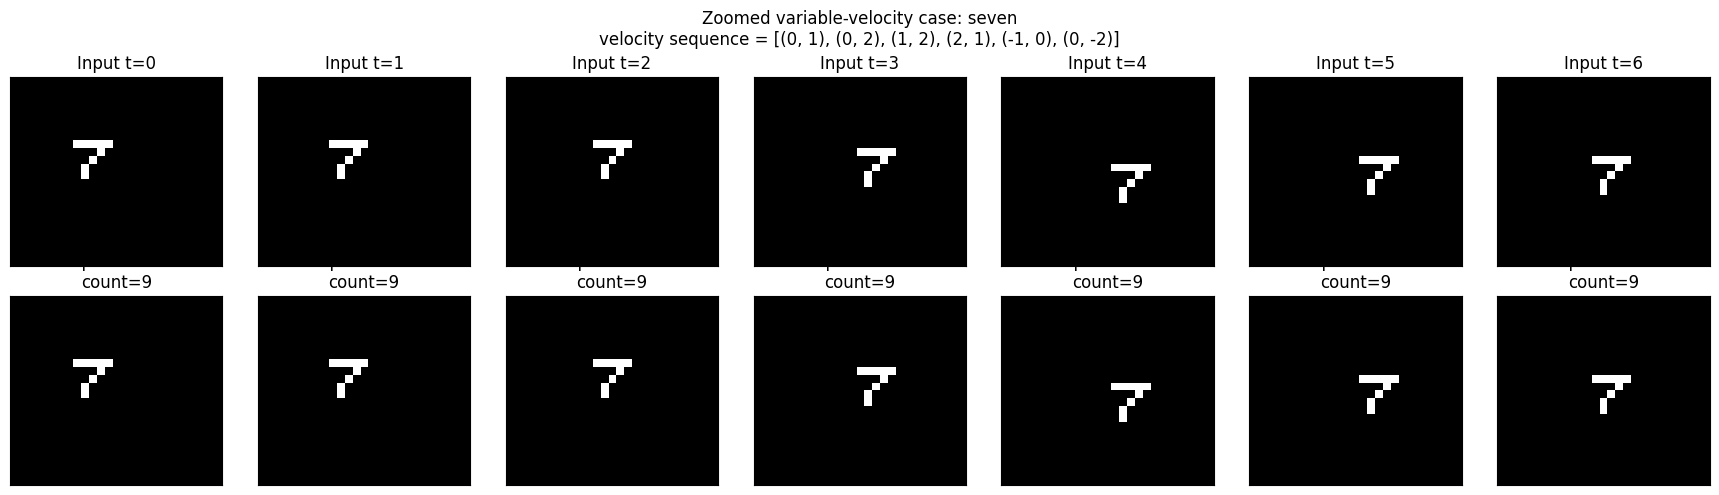

In [81]:
variable_case = make_variable_velocity_spike_case(
    velocity_sequence=[
        (0, 1),    # right 1
        (0, 2),    # right 2
        (1, 2),    # down-right
        (2, 1),    # down-right, steeper
        (-1, 0),   # up
        (0, -2),   # left 2
    ],
    shape_name="seven",
    start_top=50,
    start_left=50,
)

plot_input_next_to_spikes_zoomed(
    variable_case,
    padding=8,
)

In [82]:
def estimate_variable_velocity_sequence(
    case,
    max_offset=6,
):
    velocity_sequence = case["velocity_sequence"]
    spikes = case["spikes"]

    rows = []

    for previous_t, true_velocity in enumerate(velocity_sequence):
        current_t = previous_t + 1

        true_dy, true_dx = true_velocity

        result = estimate_velocity_from_motion_pairs_with_same_as_activity(
            previous_spikes=spikes[previous_t],
            current_spikes=spikes[current_t],
            max_offset=max_offset,
        )

        true_direction = velocity_vector_to_direction_name(true_dy, true_dx)

        rows.append({
            "previous_t": previous_t,
            "current_t": current_t,
            "true_dy": true_dy,
            "true_dx": true_dx,
            "true_direction": true_direction,
            "true_speed": (true_dy ** 2 + true_dx ** 2) ** 0.5,
            "estimated_dy": result["estimated_dy"],
            "estimated_dx": result["estimated_dx"],
            "estimated_direction": result["estimated_direction"],
            "estimated_speed": result["estimated_speed"],
            "best_pair_spike_count": result["best_pair_spike_count"],
            "correct_vector": (
                result["estimated_dy"] == true_dy
                and result["estimated_dx"] == true_dx
            ),
            "correct_direction": result["estimated_direction"] == true_direction,
        })

    return pd.DataFrame(rows)

In [83]:
variable_velocity_results = estimate_variable_velocity_sequence(
    variable_case,
    max_offset=6,
)

variable_velocity_results

,previous_t,current_t,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_vector,correct_direction
0,0,1,0,1,right,1.000000,0,1,right,1.000000,9,True,True
1,1,2,0,2,right,2.000000,0,2,right,2.000000,9,True,True
2,2,3,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True
3,3,4,2,1,down-right,2.236068,2,1,down-right,2.236068,9,True,True
4,4,5,-1,0,up,1.000000,-1,0,up,1.000000,9,True,True
5,5,6,0,-2,left,2.000000,0,-2,left,2.000000,9,True,True


In [84]:
pd.DataFrame([{
    "vector_accuracy": variable_velocity_results["correct_vector"].mean(),
    "direction_accuracy": variable_velocity_results["correct_direction"].mean(),
    "num_transitions": len(variable_velocity_results),
    "num_correct": int(variable_velocity_results["correct_vector"].sum()),
    "num_errors": int((~variable_velocity_results["correct_vector"]).sum()),
}])

,vector_accuracy,direction_accuracy,num_transitions,num_correct,num_errors
0,1.0,1.0,6,6,0


In [86]:
def make_random_velocity_sequence(
    num_transitions=6,
    velocity_values=(-3, -2, -1, 0, 1, 2, 3),
    allow_zero_velocity=False,
):
    velocity_sequence = []

    for _ in range(num_transitions):
        while True:
            velocity_y = int(torch.randint(
                low=0,
                high=len(velocity_values),
                size=(1,),
            ).item())

            velocity_x = int(torch.randint(
                low=0,
                high=len(velocity_values),
                size=(1,),
            ).item())

            dy = velocity_values[velocity_y]
            dx = velocity_values[velocity_x]

            if allow_zero_velocity or not (dy == 0 and dx == 0):
                break

        velocity_sequence.append((dy, dx))

    return velocity_sequence

In [87]:
def test_random_variable_velocity_sequences(
    num_sequences=100,
    num_transitions=6,
    shapes=("seven", "ell", "tee", "box"),
    velocity_values=(-3, -2, -1, 0, 1, 2, 3),
    max_offset=6,
    start_top=50,
    start_left=50,
    random_seed=0,
):
    torch.manual_seed(random_seed)

    rows = []

    for sequence_index in range(num_sequences):
        for shape_name in shapes:
            velocity_sequence = make_random_velocity_sequence(
                num_transitions=num_transitions,
                velocity_values=velocity_values,
                allow_zero_velocity=False,
            )

            case = make_variable_velocity_spike_case(
                velocity_sequence=velocity_sequence,
                shape_name=shape_name,
                start_top=start_top,
                start_left=start_left,
            )

            result_table = estimate_variable_velocity_sequence(
                case,
                max_offset=max_offset,
            )

            result_table = result_table.copy()
            result_table["sequence_index"] = sequence_index
            result_table["shape"] = shape_name

            rows.append(result_table)

    return pd.concat(rows, ignore_index=True)

In [88]:
random_variable_velocity_results = test_random_variable_velocity_sequences(
    num_sequences=100,
    num_transitions=6,
    shapes=("seven", "ell", "tee", "box"),
    velocity_values=(-3, -2, -1, 0, 1, 2, 3),
    max_offset=6,
    start_top=50,
    start_left=50,
    random_seed=0,
)

random_variable_velocity_results

,previous_t,current_t,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_vector,correct_direction,sequence_index,shape
0,0,1,1,0,down,1.000000,1,0,down,1.000000,9,True,True,0,seven
1,1,2,-3,-1,up-left,3.162278,-3,-1,up-left,3.162278,9,True,True,0,seven
2,2,3,-2,-1,up-left,2.236068,-2,-1,up-left,2.236068,9,True,True,0,seven
3,3,4,3,0,down,3.000000,3,0,down,3.000000,9,True,True,0,seven
4,4,5,1,2,down-right,2.236068,1,2,down-right,2.236068,9,True,True,0,seven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,1,2,0,-1,left,1.000000,0,-1,left,1.000000,16,True,True,99,box
2396,2,3,2,-3,down-left,3.605551,2,-3,down-left,3.605551,16,True,True,99,box
2397,3,4,-3,2,up-right,3.605551,-3,2,up-right,3.605551,16,True,True,99,box
2398,4,5,1,-2,down-left,2.236068,1,-2,down-left,2.236068,16,True,True,99,box


In [89]:
random_variable_velocity_summary = pd.DataFrame([{
    "vector_accuracy": random_variable_velocity_results["correct_vector"].mean(),
    "direction_accuracy": random_variable_velocity_results["correct_direction"].mean(),
    "num_cases": len(random_variable_velocity_results),
    "num_correct": int(random_variable_velocity_results["correct_vector"].sum()),
    "num_errors": int((~random_variable_velocity_results["correct_vector"]).sum()),
}])

random_variable_velocity_summary

,vector_accuracy,direction_accuracy,num_cases,num_correct,num_errors
0,1.0,1.0,2400,2400,0


## Sucess. Lets try bigger sped magnitudes

In [90]:
all_frame_pair_results_high_speed = []

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_same_activity_estimator_all_frame_pairs(
        shape_name=shape_name,
        velocity_values=(-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6),
        max_offset=6,
        start_top=50,
        start_left=50,
    )

    all_frame_pair_results_high_speed.append(result)

all_frame_pair_results_high_speed = pd.concat(
    all_frame_pair_results_high_speed,
    ignore_index=True,
)

all_frame_pair_results_high_speed

,shape,previous_t,current_t,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_dy,correct_dx,correct_vector,correct_direction
0,seven,0,1,-6,-6,up-left,8.485281,-6,-6,up-left,8.485281,9,True,True,True,True
1,seven,1,2,-6,-6,up-left,8.485281,-6,-6,up-left,8.485281,9,True,True,True,True
2,seven,2,3,-6,-6,up-left,8.485281,-6,-6,up-left,8.485281,9,True,True,True,True
3,seven,3,4,-6,-6,up-left,8.485281,-6,-6,up-left,8.485281,9,True,True,True,True
4,seven,4,5,-6,-6,up-left,8.485281,-6,-6,up-left,8.485281,9,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4027,box,1,2,6,6,down-right,8.485281,6,6,down-right,8.485281,16,True,True,True,True
4028,box,2,3,6,6,down-right,8.485281,6,6,down-right,8.485281,16,True,True,True,True
4029,box,3,4,6,6,down-right,8.485281,6,6,down-right,8.485281,16,True,True,True,True
4030,box,4,5,6,6,down-right,8.485281,6,6,down-right,8.485281,16,True,True,True,True


In [91]:
high_speed_summary = pd.DataFrame([{
    "vector_accuracy": all_frame_pair_results_high_speed["correct_vector"].mean(),
    "direction_accuracy": all_frame_pair_results_high_speed["correct_direction"].mean(),
    "num_cases": len(all_frame_pair_results_high_speed),
    "num_correct": int(all_frame_pair_results_high_speed["correct_vector"].sum()),
    "num_errors": int((~all_frame_pair_results_high_speed["correct_vector"]).sum()),
}])

high_speed_summary

,vector_accuracy,direction_accuracy,num_cases,num_correct,num_errors
0,1.0,1.0,4032,4032,0


Even higher magnitudes

In [92]:
higher_speed_results_7_to_10 = []

higher_velocity_values = (
    -10, -9, -8, -7,
     7,  8,  9, 10,
)

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_same_activity_estimator_all_frame_pairs(
        shape_name=shape_name,
        velocity_values=higher_velocity_values,
        max_offset=10,
        start_top=60,
        start_left=60,
    )

    higher_speed_results_7_to_10.append(result)

higher_speed_results_7_to_10 = pd.concat(
    higher_speed_results_7_to_10,
    ignore_index=True,
)

higher_speed_summary_7_to_10 = pd.DataFrame([{
    "vector_accuracy": higher_speed_results_7_to_10["correct_vector"].mean(),
    "direction_accuracy": higher_speed_results_7_to_10["correct_direction"].mean(),
    "num_cases": len(higher_speed_results_7_to_10),
    "num_correct": int(higher_speed_results_7_to_10["correct_vector"].sum()),
    "num_errors": int((~higher_speed_results_7_to_10["correct_vector"]).sum()),
}])

higher_speed_summary_7_to_10

,vector_accuracy,direction_accuracy,num_cases,num_correct,num_errors
0,1.0,1.0,1536,1536,0


Need to include mixed cases like (10,2) etc. 

In [96]:
velocity_values_10 = tuple(range(-10, 11))

higher_speed_results_up_to_10 = []

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_same_activity_estimator_all_frame_pairs(
        shape_name=shape_name,
        velocity_values=velocity_values_10,
        max_offset=10,
        start_top=60,
        start_left=60,
    )

    # Exclude already-tested cases where both components are within [-6, 6].
    result = result[
        (result["true_dy"].abs() > 6)
        | (result["true_dx"].abs() > 6)
    ].copy()

    higher_speed_results_up_to_10.append(result)

higher_speed_results_up_to_10 = pd.concat(
    higher_speed_results_up_to_10,
    ignore_index=True,
)

higher_speed_summary_up_to_10 = pd.DataFrame([{
    "vector_accuracy": higher_speed_results_up_to_10["correct_vector"].mean(),
    "direction_accuracy": higher_speed_results_up_to_10["correct_direction"].mean(),
    "num_cases": len(higher_speed_results_up_to_10),
    "num_correct": int(higher_speed_results_up_to_10["correct_vector"].sum()),
    "num_errors": int((~higher_speed_results_up_to_10["correct_vector"]).sum()),
}])

higher_speed_summary_up_to_10

,vector_accuracy,direction_accuracy,num_cases,num_correct,num_errors
0,1.0,1.0,6528,6528,0


## Success! 
Next I want to test clipped frames

In [97]:
def place_shape_clipped_on_canvas(
    shape,
    canvas_height,
    canvas_width,
    top,
    left,
    intensity=1.0,
):
    """
    Place a shape on the canvas, allowing it to be partially outside the frame.
    Only the visible part is drawn.
    """

    frame = torch.zeros(
        (canvas_height, canvas_width),
        dtype=torch.float32,
    )

    shape_height, shape_width = shape.shape

    top = int(top)
    left = int(left)

    canvas_y_start = max(0, top)
    canvas_y_end = min(canvas_height, top + shape_height)

    canvas_x_start = max(0, left)
    canvas_x_end = min(canvas_width, left + shape_width)

    shape_y_start = canvas_y_start - top
    shape_y_end = shape_y_start + (canvas_y_end - canvas_y_start)

    shape_x_start = canvas_x_start - left
    shape_x_end = shape_x_start + (canvas_x_end - canvas_x_start)

    if canvas_y_start < canvas_y_end and canvas_x_start < canvas_x_end:
        frame[
            canvas_y_start:canvas_y_end,
            canvas_x_start:canvas_x_end,
        ] = shape[
            shape_y_start:shape_y_end,
            shape_x_start:shape_x_end,
        ].float() * intensity

    return frame

In [98]:
def make_boundary_entry_spike_case(
    velocity_y,
    velocity_x,
    shape_name="seven",
    start_top=60,
    start_left=-4,
    steps=STEPS,
):
    """
    Create a sequence where the object may start partially outside the canvas
    and enter the visible frame.
    """

    shape = SHAPE_TEMPLATES[shape_name]

    frames = []
    positions = []

    for t in range(steps):
        top = start_top + t * velocity_y
        left = start_left + t * velocity_x

        frame = place_shape_clipped_on_canvas(
            shape=shape,
            canvas_height=CANVAS_HEIGHT,
            canvas_width=CANVAS_WIDTH,
            top=top,
            left=left,
            intensity=INTENSITY,
        )

        frames.append(frame)
        positions.append((top, left))

    frames = torch.stack(frames, dim=0)
    spikes = (frames > 0).float()

    return {
        "shape_name": shape_name,
        "velocity_y": velocity_y,
        "velocity_x": velocity_x,
        "positions": positions,
        "frames": frames,
        "spikes": spikes,
    }

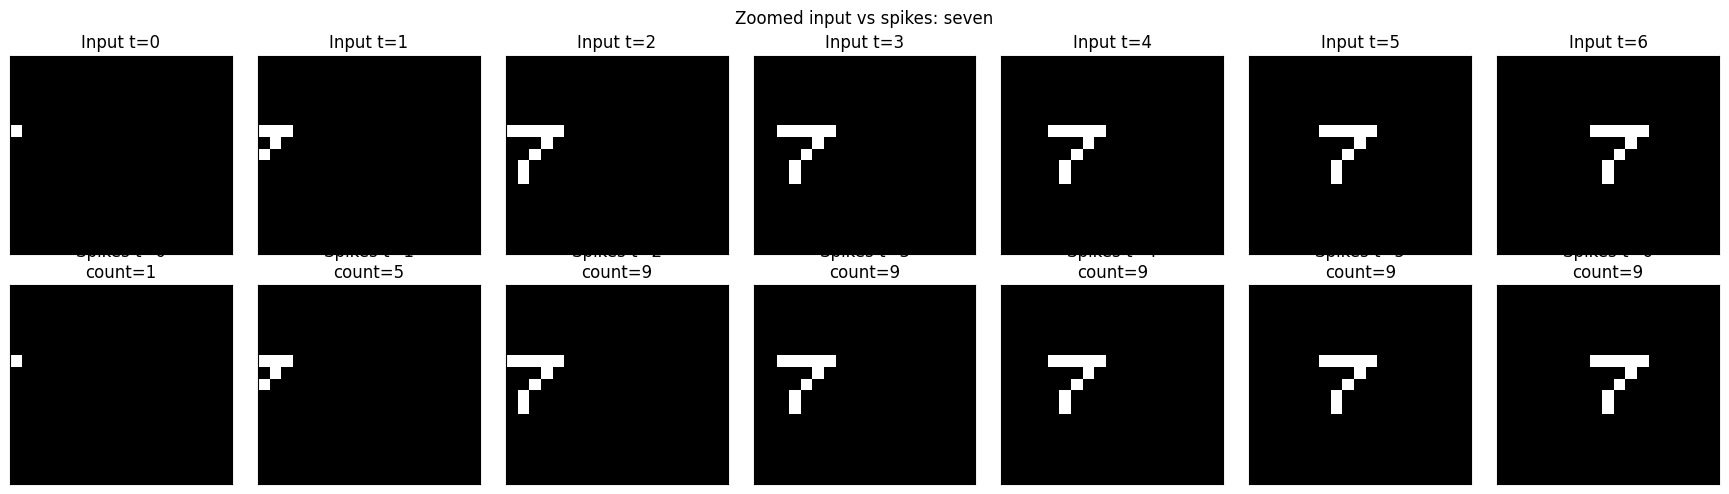

In [99]:
entry_case = make_boundary_entry_spike_case(
    velocity_y=0,
    velocity_x=2,
    shape_name="seven",
    start_top=60,
    start_left=-4,
    steps=STEPS,
)

plot_input_next_to_spikes_zoomed(
    entry_case,
    padding=6,
)

In [100]:
entry_results = test_one_case_across_all_frame_pairs(
    shape_name="seven",
    velocity_y=0,
    velocity_x=2,
    max_offset=6,
    start_top=60,
    start_left=-4,
)

entry_results

,shape,previous_t,current_t,true_dy,true_dx,true_direction,true_speed,estimated_dy,estimated_dx,estimated_direction,estimated_speed,best_pair_spike_count,correct_vector,correct_direction
0,seven,0,1,0,2,right,2.0,0,1,right,1.0,1,False,True
1,seven,1,2,0,2,right,2.0,0,2,right,2.0,5,True,True
2,seven,2,3,0,2,right,2.0,0,2,right,2.0,9,True,True
3,seven,3,4,0,2,right,2.0,0,2,right,2.0,9,True,True
4,seven,4,5,0,2,right,2.0,0,2,right,2.0,9,True,True
5,seven,5,6,0,2,right,2.0,0,2,right,2.0,9,True,True


In [103]:
def estimate_constant_velocity_case_all_frame_pairs(case, max_offset=6):
    rows = []

    velocity_y = case["velocity_y"]
    velocity_x = case["velocity_x"]

    true_direction = velocity_vector_to_direction_name(
        velocity_y,
        velocity_x,
    )

    for previous_t in range(case["spikes"].shape[0] - 1):
        current_t = previous_t + 1

        result = estimate_velocity_from_motion_pairs_with_same_as_activity(
            previous_spikes=case["spikes"][previous_t],
            current_spikes=case["spikes"][current_t],
            max_offset=max_offset,
        )

        rows.append({
            "shape": case["shape_name"],
            "previous_t": previous_t,
            "current_t": current_t,
            "true_dy": velocity_y,
            "true_dx": velocity_x,
            "true_direction": true_direction,
            "estimated_dy": result["estimated_dy"],
            "estimated_dx": result["estimated_dx"],
            "estimated_direction": result["estimated_direction"],
            "best_pair_spike_count": result["best_pair_spike_count"],
            "correct_vector": (
                result["estimated_dy"] == velocity_y
                and result["estimated_dx"] == velocity_x
            ),
            "correct_direction": result["estimated_direction"] == true_direction,
        })

    return pd.DataFrame(rows)

In [104]:
entry_results = estimate_constant_velocity_case_all_frame_pairs(
    entry_case,
    max_offset=6,
)

entry_results

,shape,previous_t,current_t,true_dy,true_dx,true_direction,estimated_dy,estimated_dx,estimated_direction,best_pair_spike_count,correct_vector,correct_direction
0,seven,0,1,0,2,right,0,1,right,1,False,True
1,seven,1,2,0,2,right,0,2,right,5,True,True
2,seven,2,3,0,2,right,0,2,right,9,True,True
3,seven,3,4,0,2,right,0,2,right,9,True,True
4,seven,4,5,0,2,right,0,2,right,9,True,True
5,seven,5,6,0,2,right,0,2,right,9,True,True


Boundary-entry test:
The estimator remained correct once more than a minimal fragment of the object was visible. The only failure occurred in the first transition, when the object was represented by a single visible pixel. In that case, the available spike evidence was insufficient to disambiguate the true displacement, and the model underestimated speed.

In [106]:
def count_visible_spikes_per_frame(case):
    rows = []

    for t in range(case["spikes"].shape[0]):
        rows.append({
            "t": t,
            "visible_spike_count": int(case["spikes"][t].sum().item()),
        })

    return pd.DataFrame(rows)

In [107]:
count_visible_spikes_per_frame(entry_case)

,t,visible_spike_count
0,0,1
1,1,5
2,2,9
3,3,9
4,4,9
5,5,9
6,6,9


In [108]:
def estimate_constant_velocity_case_all_frame_pairs_with_visibility(case, max_offset=6):
    rows = []

    velocity_y = case["velocity_y"]
    velocity_x = case["velocity_x"]

    true_direction = velocity_vector_to_direction_name(
        velocity_y,
        velocity_x,
    )

    for previous_t in range(case["spikes"].shape[0] - 1):
        current_t = previous_t + 1

        result = estimate_velocity_from_motion_pairs_with_same_as_activity(
            previous_spikes=case["spikes"][previous_t],
            current_spikes=case["spikes"][current_t],
            max_offset=max_offset,
        )

        previous_visible_spikes = int(case["spikes"][previous_t].sum().item())
        current_visible_spikes = int(case["spikes"][current_t].sum().item())

        rows.append({
            "shape": case["shape_name"],
            "previous_t": previous_t,
            "current_t": current_t,
            "previous_visible_spikes": previous_visible_spikes,
            "current_visible_spikes": current_visible_spikes,
            "min_visible_spikes": min(previous_visible_spikes, current_visible_spikes),
            "true_dy": velocity_y,
            "true_dx": velocity_x,
            "true_direction": true_direction,
            "estimated_dy": result["estimated_dy"],
            "estimated_dx": result["estimated_dx"],
            "estimated_direction": result["estimated_direction"],
            "best_pair_spike_count": result["best_pair_spike_count"],
            "correct_vector": (
                result["estimated_dy"] == velocity_y
                and result["estimated_dx"] == velocity_x
            ),
            "correct_direction": result["estimated_direction"] == true_direction,
        })

    return pd.DataFrame(rows)

In [110]:
entry_results_with_visibility = estimate_constant_velocity_case_all_frame_pairs_with_visibility(
    entry_case,
    max_offset=6,
)

entry_results_with_visibility

,shape,previous_t,current_t,previous_visible_spikes,current_visible_spikes,min_visible_spikes,true_dy,true_dx,true_direction,estimated_dy,estimated_dx,estimated_direction,best_pair_spike_count,correct_vector,correct_direction
0,seven,0,1,1,5,1,0,2,right,0,1,right,1,False,True
1,seven,1,2,5,9,5,0,2,right,0,2,right,5,True,True
2,seven,2,3,9,9,9,0,2,right,0,2,right,9,True,True
3,seven,3,4,9,9,9,0,2,right,0,2,right,9,True,True
4,seven,4,5,9,9,9,0,2,right,0,2,right,9,True,True
5,seven,5,6,9,9,9,0,2,right,0,2,right,9,True,True


In [111]:
valid_entry_results = entry_results_with_visibility[
    entry_results_with_visibility["min_visible_spikes"] >= 2
].copy()

pd.DataFrame([{
    "vector_accuracy_all_transitions": entry_results_with_visibility["correct_vector"].mean(),
    "vector_accuracy_valid_transitions": valid_entry_results["correct_vector"].mean(),
    "num_all_transitions": len(entry_results_with_visibility),
    "num_valid_transitions": len(valid_entry_results),
    "num_invalid_or_low_evidence": len(entry_results_with_visibility) - len(valid_entry_results),
}])

,vector_accuracy_all_transitions,vector_accuracy_valid_transitions,num_all_transitions,num_valid_transitions,num_invalid_or_low_evidence
0,0.833333,1.0,6,5,1


In [112]:
def visible_spike_count(frame):
    return int((frame > 0).sum().item())

In [113]:
def test_boundary_entry_visibility_sweep(
    shape_name="seven",
    velocity_y=0,
    velocity_x=2,
    start_top=60,
    start_left_values=range(-8, 3),
    steps=STEPS,
    max_offset=6,
):
    rows = []

    for start_left in start_left_values:
        case = make_boundary_entry_spike_case(
            velocity_y=velocity_y,
            velocity_x=velocity_x,
            shape_name=shape_name,
            start_top=start_top,
            start_left=start_left,
            steps=steps,
        )

        result_table = estimate_constant_velocity_case_all_frame_pairs_with_visibility(
            case,
            max_offset=max_offset,
        )

        result_table = result_table.copy()
        result_table["start_left"] = start_left
        result_table["initial_visible_spikes"] = visible_spike_count(case["spikes"][0])
        result_table["shape"] = shape_name

        rows.append(result_table)

    return pd.concat(rows, ignore_index=True)

In [120]:
boundary_sweep_seven = test_boundary_entry_visibility_sweep(
    shape_name="seven",
    velocity_y=0,
    velocity_x=2,
    start_top=60,
    start_left_values=range(-8, 3),
    steps=STEPS,
    max_offset=6,
)

boundary_sweep_seven

,shape,previous_t,current_t,previous_visible_spikes,current_visible_spikes,min_visible_spikes,true_dy,true_dx,true_direction,estimated_dy,estimated_dx,estimated_direction,best_pair_spike_count,correct_vector,correct_direction,start_left,initial_visible_spikes
0,seven,0,1,0,0,0,0,2,right,-1,0,up,0,False,False,-8,0
1,seven,1,2,0,1,0,0,2,right,-1,0,up,0,False,False,-8,0
2,seven,2,3,1,5,1,0,2,right,0,1,right,1,False,True,-8,0
3,seven,3,4,5,9,5,0,2,right,0,2,right,5,True,True,-8,0
4,seven,4,5,9,9,9,0,2,right,0,2,right,9,True,True,-8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,seven,1,2,9,9,9,0,2,right,0,2,right,9,True,True,2,9
62,seven,2,3,9,9,9,0,2,right,0,2,right,9,True,True,2,9
63,seven,3,4,9,9,9,0,2,right,0,2,right,9,True,True,2,9
64,seven,4,5,9,9,9,0,2,right,0,2,right,9,True,True,2,9


In [121]:
boundary_sweep_seven.groupby("initial_visible_spikes").agg(
    vector_accuracy=("correct_vector", "mean"),
    direction_accuracy=("correct_direction", "mean"),
    num_transitions=("correct_vector", "count"),
    mean_pair_spikes=("best_pair_spike_count", "mean"),
).reset_index()

,initial_visible_spikes,vector_accuracy,direction_accuracy,num_transitions,mean_pair_spikes
0,0,0.666667,0.75,24,5.166667
1,1,0.833333,1.00,6,7.000000
2,3,1.000000,1.00,6,7.833333
3,5,1.000000,1.00,6,8.333333
4,8,1.000000,1.00,6,8.833333
5,9,1.000000,1.00,18,9.000000


In [122]:
all_boundary_sweeps = []

for shape_name in ["seven", "ell", "tee", "box"]:
    result = test_boundary_entry_visibility_sweep(
        shape_name=shape_name,
        velocity_y=0,
        velocity_x=2,
        start_top=60,
        start_left_values=range(-8, 3),
        steps=STEPS,
        max_offset=6,
    )

    all_boundary_sweeps.append(result)

boundary_sweep_all_shapes = pd.concat(
    all_boundary_sweeps,
    ignore_index=True,
)

boundary_sweep_all_shapes

,shape,previous_t,current_t,previous_visible_spikes,current_visible_spikes,min_visible_spikes,true_dy,true_dx,true_direction,estimated_dy,estimated_dx,estimated_direction,best_pair_spike_count,correct_vector,correct_direction,start_left,initial_visible_spikes
0,seven,0,1,0,0,0,0,2,right,-1,0,up,0,False,False,-8,0
1,seven,1,2,0,1,0,0,2,right,-1,0,up,0,False,False,-8,0
2,seven,2,3,1,5,1,0,2,right,0,1,right,1,False,True,-8,0
3,seven,3,4,5,9,5,0,2,right,0,2,right,5,True,True,-8,0
4,seven,4,5,9,9,9,0,2,right,0,2,right,9,True,True,-8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,box,1,2,16,16,16,0,2,right,0,2,right,16,True,True,2,16
260,box,2,3,16,16,16,0,2,right,0,2,right,16,True,True,2,16
261,box,3,4,16,16,16,0,2,right,0,2,right,16,True,True,2,16
262,box,4,5,16,16,16,0,2,right,0,2,right,16,True,True,2,16


In [123]:
boundary_sweep_all_shapes.groupby(["shape", "initial_visible_spikes"]).agg(
    vector_accuracy=("correct_vector", "mean"),
    direction_accuracy=("correct_direction", "mean"),
    num_transitions=("correct_vector", "count"),
    mean_pair_spikes=("best_pair_spike_count", "mean"),
).reset_index()

,shape,initial_visible_spikes,vector_accuracy,direction_accuracy,num_transitions,mean_pair_spikes
0,box,0,0.750000,0.75,24,9.333333
1,box,5,1.000000,1.00,6,13.000000
2,box,7,1.000000,1.00,6,13.666667
3,box,9,1.000000,1.00,6,14.833333
4,box,11,1.000000,1.00,6,15.166667
5,box,16,1.000000,1.00,18,16.000000
6,ell,0,0.416667,0.75,24,4.583333
7,ell,1,0.666667,1.00,6,6.666667
8,ell,2,0.666667,1.00,6,7.000000
9,ell,3,0.833333,1.00,6,8.000000


### Boundary-entry limitation

When the object enters the frame partially visible, the estimator remains reliable once enough shape structure is visible. Very small fragments, such as 1–2 visible pixels, do not provide enough spatial evidence for reliable velocity estimation. The minimum required visible evidence depends on shape geometry: for example, the seven shape became reliable with about 3 visible pixels, while the ell shape required more visible structure. This suggests that boundary cases should be treated as low-confidence until sufficient spike evidence is available.

Next add confidence readouts

In [124]:
def estimate_velocity_with_confidence(
    previous_spikes,
    current_spikes,
    max_offset=10,
    min_visible_spikes=3,
    min_winner_margin=1,
):
    result = estimate_velocity_from_motion_pairs_with_same_as_activity(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
        max_offset=max_offset,
    )

    scores = result["motion_pair_scores"].copy()

    best_score = int(scores.iloc[0]["pair_spike_count"])
    second_score = int(scores.iloc[1]["pair_spike_count"])
    winner_margin = best_score - second_score

    previous_visible_spikes = int((previous_spikes > 0).sum().item())
    current_visible_spikes = int((current_spikes > 0).sum().item())
    min_visible = min(previous_visible_spikes, current_visible_spikes)

    enough_visible_evidence = min_visible >= min_visible_spikes
    strong_winner = winner_margin >= min_winner_margin

    high_confidence = enough_visible_evidence and strong_winner

    result["previous_visible_spikes"] = previous_visible_spikes
    result["current_visible_spikes"] = current_visible_spikes
    result["min_visible_spikes"] = min_visible
    result["best_score"] = best_score
    result["second_best_score"] = second_score
    result["winner_margin"] = winner_margin
    result["high_confidence"] = high_confidence

    return result

In [125]:
confidence_rows = []

for previous_t in range(entry_case["spikes"].shape[0] - 1):
    current_t = previous_t + 1

    result = estimate_velocity_with_confidence(
        previous_spikes=entry_case["spikes"][previous_t],
        current_spikes=entry_case["spikes"][current_t],
        max_offset=6,
        min_visible_spikes=3,
        min_winner_margin=1,
    )

    confidence_rows.append({
        "previous_t": previous_t,
        "current_t": current_t,
        "estimated_dy": result["estimated_dy"],
        "estimated_dx": result["estimated_dx"],
        "previous_visible_spikes": result["previous_visible_spikes"],
        "current_visible_spikes": result["current_visible_spikes"],
        "min_visible_spikes": result["min_visible_spikes"],
        "best_score": result["best_score"],
        "second_best_score": result["second_best_score"],
        "winner_margin": result["winner_margin"],
        "high_confidence": result["high_confidence"],
    })

confidence_boundary_results = pd.DataFrame(confidence_rows)
confidence_boundary_results

,previous_t,current_t,estimated_dy,estimated_dx,previous_visible_spikes,current_visible_spikes,min_visible_spikes,best_score,second_best_score,winner_margin,high_confidence
0,0,1,0,1,1,5,1,1,1,0,False
1,1,2,0,2,5,9,5,5,3,2,True
2,2,3,0,2,9,9,9,9,4,5,True
3,3,4,0,2,9,9,9,9,4,5,True
4,4,5,0,2,9,9,9,9,4,5,True
5,5,6,0,2,9,9,9,9,4,5,True


In [126]:
ell_boundary_sweep = test_boundary_entry_visibility_sweep(
    shape_name="ell",
    velocity_y=0,
    velocity_x=2,
    start_top=60,
    start_left_values=range(-8, 3),
    steps=STEPS,
    max_offset=6,
)

ell_boundary_sweep

,shape,previous_t,current_t,previous_visible_spikes,current_visible_spikes,min_visible_spikes,true_dy,true_dx,true_direction,estimated_dy,estimated_dx,estimated_direction,best_pair_spike_count,correct_vector,correct_direction,start_left,initial_visible_spikes
0,ell,0,1,0,0,0,0,2,right,-1,0,up,0,False,False,-8,0
1,ell,1,2,0,1,0,0,2,right,-1,0,up,0,False,False,-8,0
2,ell,2,3,1,3,1,0,2,right,0,1,right,1,False,True,-8,0
3,ell,3,4,3,9,3,0,2,right,0,1,right,3,False,True,-8,0
4,ell,4,5,9,9,9,0,2,right,0,2,right,9,True,True,-8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,ell,1,2,9,9,9,0,2,right,0,2,right,9,True,True,2,9
62,ell,2,3,9,9,9,0,2,right,0,2,right,9,True,True,2,9
63,ell,3,4,9,9,9,0,2,right,0,2,right,9,True,True,2,9
64,ell,4,5,9,9,9,0,2,right,0,2,right,9,True,True,2,9


In [127]:
ell_boundary_by_initial_visibility = (
    ell_boundary_sweep
    .groupby("initial_visible_spikes")
    .agg(
        vector_accuracy=("correct_vector", "mean"),
        direction_accuracy=("correct_direction", "mean"),
        num_transitions=("correct_vector", "count"),
        mean_pair_spikes=("best_pair_spike_count", "mean"),
    )
    .reset_index()
)

ell_boundary_by_initial_visibility

,initial_visible_spikes,vector_accuracy,direction_accuracy,num_transitions,mean_pair_spikes
0,0,0.416667,0.75,24,4.583333
1,1,0.666667,1.00,6,6.666667
2,2,0.666667,1.00,6,7.000000
3,3,0.833333,1.00,6,8.000000
4,4,0.833333,1.00,6,8.166667
5,9,1.000000,1.00,18,9.000000


In [128]:
ell_boundary_failures = ell_boundary_sweep[
    ~ell_boundary_sweep["correct_vector"]
].copy()

ell_boundary_failures[[
    "shape",
    "start_left",
    "initial_visible_spikes",
    "previous_t",
    "current_t",
    "previous_visible_spikes",
    "current_visible_spikes",
    "min_visible_spikes",
    "true_dy",
    "true_dx",
    "estimated_dy",
    "estimated_dx",
    "estimated_direction",
    "best_pair_spike_count",
]]

,shape,start_left,initial_visible_spikes,previous_t,current_t,previous_visible_spikes,current_visible_spikes,min_visible_spikes,true_dy,true_dx,estimated_dy,estimated_dx,estimated_direction,best_pair_spike_count
0,ell,-8,0,0,1,0,0,0,0,2,-1,0,up,0
1,ell,-8,0,1,2,0,1,0,0,2,-1,0,up,0
2,ell,-8,0,2,3,1,3,1,0,2,0,1,right,1
3,ell,-8,0,3,4,3,9,3,0,2,0,1,right,3
6,ell,-7,0,0,1,0,0,0,0,2,-1,0,up,0
7,ell,-7,0,1,2,0,2,0,0,2,-1,0,up,0
8,ell,-7,0,2,3,2,4,2,0,2,0,1,right,2
9,ell,-7,0,3,4,4,9,4,0,2,0,1,right,4
12,ell,-6,0,0,1,0,1,0,0,2,-1,0,up,0
13,ell,-6,0,1,2,1,3,1,0,2,0,1,right,1


In [131]:
def visualize_boundary_entry_case(
    shape_name="ell",
    velocity_y=0,
    velocity_x=2,
    start_top=60,
    start_left=-4,
    max_offset=6,
    steps=STEPS,
):
    case = make_boundary_entry_spike_case(
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        shape_name=shape_name,
        start_top=start_top,
        start_left=start_left,
        steps=steps,
    )

    plot_input_next_to_spikes_zoomed(
        case,
        padding=6,
    )

    results = estimate_constant_velocity_case_all_frame_pairs_with_visibility(
        case,
        max_offset=max_offset,
    )

    display(results)

    return case, results

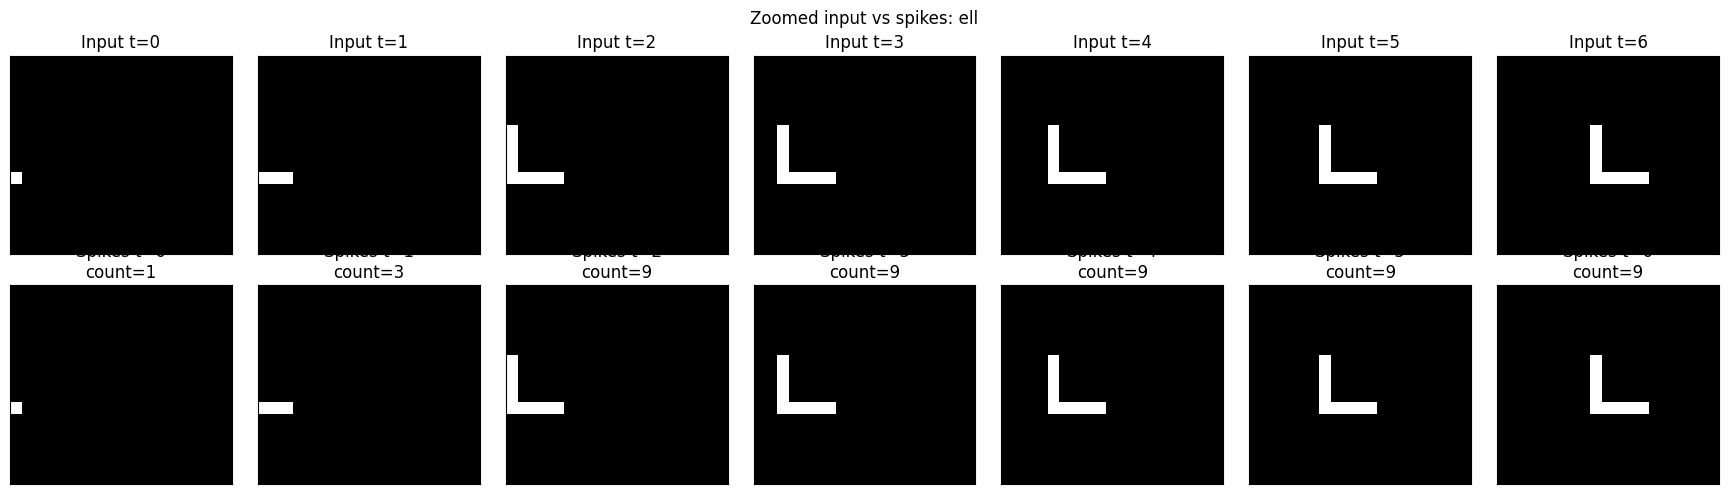

,shape,previous_t,current_t,previous_visible_spikes,current_visible_spikes,min_visible_spikes,true_dy,true_dx,true_direction,estimated_dy,estimated_dx,estimated_direction,best_pair_spike_count,correct_vector,correct_direction
0,ell,0,1,1,3,1,0,2,right,0,1,right,1,False,True
1,ell,1,2,3,9,3,0,2,right,0,1,right,3,False,True
2,ell,2,3,9,9,9,0,2,right,0,2,right,9,True,True
3,ell,3,4,9,9,9,0,2,right,0,2,right,9,True,True
4,ell,4,5,9,9,9,0,2,right,0,2,right,9,True,True
5,ell,5,6,9,9,9,0,2,right,0,2,right,9,True,True


In [132]:
ell_debug_case, ell_debug_results = visualize_boundary_entry_case(
    shape_name="ell",
    velocity_y=0,
    velocity_x=2,
    start_top=60,
    start_left=-4,
    max_offset=6,
)

In [134]:
confidence_rows = []

for previous_t in range(ell_debug_case["spikes"].shape[0] - 1):
    current_t = previous_t + 1

    result = estimate_velocity_with_confidence(
        previous_spikes=ell_debug_case["spikes"][previous_t],
        current_spikes=ell_debug_case["spikes"][current_t],
        max_offset=6,
        min_visible_spikes=5,
        min_winner_margin=1,
    )

    confidence_rows.append({
        "previous_t": previous_t,
        "current_t": current_t,
        "estimated_dy": result["estimated_dy"],
        "estimated_dx": result["estimated_dx"],
        "previous_visible_spikes": result["previous_visible_spikes"],
        "current_visible_spikes": result["current_visible_spikes"],
        "min_visible_spikes": result["min_visible_spikes"],
        "best_score": result["best_score"],
        "second_best_score": result["second_best_score"],
        "winner_margin": result["winner_margin"],
        "high_confidence": result["high_confidence"],
    })

ell_confidence_debug = pd.DataFrame(confidence_rows)
ell_confidence_debug

,previous_t,current_t,estimated_dy,estimated_dx,previous_visible_spikes,current_visible_spikes,min_visible_spikes,best_score,second_best_score,winner_margin,high_confidence
0,0,1,0,1,1,3,1,1,1,0,False
1,1,2,0,1,3,9,3,3,3,0,False
2,2,3,0,2,9,9,9,9,4,5,True
3,3,4,0,2,9,9,9,9,4,5,True
4,4,5,0,2,9,9,9,9,4,5,True
5,5,6,0,2,9,9,9,9,4,5,True


Now that the concept is sold I should cahne everything to LIF neurons

In [135]:
def lif_step(input_current, membrane, beta=0.0, threshold=1.0, reset_mode="zero"):
    """
    One simple LIF step.

    input_current: synaptic input to neuron population
    membrane: previous membrane potential
    beta: leak factor
    threshold: spike threshold
    reset_mode: "zero" or "subtract"
    """

    membrane = beta * membrane + input_current
    spikes = (membrane >= threshold).float()

    if reset_mode == "zero":
        membrane = membrane * (1.0 - spikes)
    elif reset_mode == "subtract":
        membrane = membrane - spikes * threshold
    else:
        raise ValueError("reset_mode must be 'zero' or 'subtract'.")

    return spikes, membrane

In [136]:
def compute_lif_event_populations(
    previous_spikes,
    current_spikes,
    excitatory_weight=1.0,
    inhibitory_weight=-1.0,
    threshold_on=0.5,
    threshold_off=0.5,
    threshold_same=1.5,
    beta=0.0,
    reset_mode="zero",
):
    """
    LIF implementation of ON, OFF, and SAME event populations.

    ON[y,x]:
        current excites
        previous inhibits

    OFF[y,x]:
        previous excites
        current inhibits

    SAME[y,x]:
        previous excites
        current excites
        threshold requires both
    """

    previous_spikes = (previous_spikes > 0).float()
    current_spikes = (current_spikes > 0).float()

    # ON: current present, previous absent
    on_input = (
        excitatory_weight * current_spikes
        + inhibitory_weight * previous_spikes
    )

    # OFF: previous present, current absent
    off_input = (
        excitatory_weight * previous_spikes
        + inhibitory_weight * current_spikes
    )

    # SAME: previous and current both present
    same_input = (
        excitatory_weight * previous_spikes
        + excitatory_weight * current_spikes
    )

    # Fresh membranes for this comparison step.
    on_membrane = torch.zeros_like(previous_spikes)
    off_membrane = torch.zeros_like(previous_spikes)
    same_membrane = torch.zeros_like(previous_spikes)

    on_spikes, on_membrane = lif_step(
        input_current=on_input,
        membrane=on_membrane,
        beta=beta,
        threshold=threshold_on,
        reset_mode=reset_mode,
    )

    off_spikes, off_membrane = lif_step(
        input_current=off_input,
        membrane=off_membrane,
        beta=beta,
        threshold=threshold_off,
        reset_mode=reset_mode,
    )

    same_spikes, same_membrane = lif_step(
        input_current=same_input,
        membrane=same_membrane,
        beta=beta,
        threshold=threshold_same,
        reset_mode=reset_mode,
    )

    return {
        "on_spikes": on_spikes,
        "off_spikes": off_spikes,
        "same_spikes": same_spikes,
        "on_input": on_input,
        "off_input": off_input,
        "same_input": same_input,
        "on_membrane": on_membrane,
        "off_membrane": off_membrane,
        "same_membrane": same_membrane,
    }

In [137]:
lif_event_test_case = make_unblurred_spike_case_from_velocity(
    velocity_y=0,
    velocity_x=4,
    shape_name="box",
    start_top=50,
    start_left=50,
)

previous_t = 5
current_t = 6

lif_events = compute_lif_event_populations(
    previous_spikes=lif_event_test_case["spikes"][previous_t],
    current_spikes=lif_event_test_case["spikes"][current_t],
)

pd.DataFrame([{
    "on_count": int(lif_events["on_spikes"].sum().item()),
    "off_count": int(lif_events["off_spikes"].sum().item()),
    "same_count": int(lif_events["same_spikes"].sum().item()),
}])

,on_count,off_count,same_count
0,11,11,5


In [138]:
def plot_lif_event_populations(case, previous_t=5, current_t=6):
    previous_spikes = case["spikes"][previous_t]
    current_spikes = case["spikes"][current_t]

    lif_events = compute_lif_event_populations(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
    )

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    axes[0].imshow(previous_spikes, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Previous\n t={previous_t}")

    axes[1].imshow(current_spikes, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Current\n t={current_t}")

    axes[2].imshow(lif_events["off_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[2].set_title(
        f"OFF LIF\ncount={int(lif_events['off_spikes'].sum().item())}"
    )

    axes[3].imshow(lif_events["on_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[3].set_title(
        f"ON LIF\ncount={int(lif_events['on_spikes'].sum().item())}"
    )

    axes[4].imshow(lif_events["same_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[4].set_title(
        f"SAME LIF\ncount={int(lif_events['same_spikes'].sum().item())}"
    )

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle("LIF ON/OFF/SAME event populations")
    plt.tight_layout()
    plt.show()

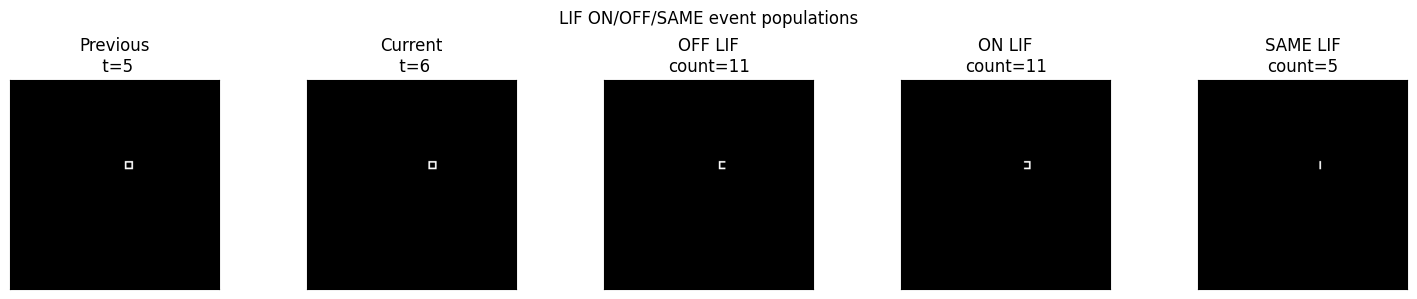

In [139]:
plot_lif_event_populations(
    lif_event_test_case,
    previous_t=5,
    current_t=6,
)

In [140]:
boolean_events = compute_on_off_difference_layer(
    previous_spikes=lif_event_test_case["spikes"][previous_t],
    current_spikes=lif_event_test_case["spikes"][current_t],
)

lif_events = compute_lif_event_populations(
    previous_spikes=lif_event_test_case["spikes"][previous_t],
    current_spikes=lif_event_test_case["spikes"][current_t],
)

pd.DataFrame([{
    "on_matches": torch.equal(boolean_events["on_spikes"], lif_events["on_spikes"]),
    "off_matches": torch.equal(boolean_events["off_spikes"], lif_events["off_spikes"]),
    "same_matches": torch.equal(boolean_events["same_spikes"], lif_events["same_spikes"]),
}])

,on_matches,off_matches,same_matches
0,True,True,True


## LIF event-layer checkpoint

The Boolean ON/OFF/SAME event layer was replaced by three LIF event populations.

For each pixel `(y, x)`:

- `ON[y,x]` receives excitation from the current frame and inhibition from the previous frame.
- `OFF[y,x]` receives excitation from the previous frame and inhibition from the current frame.
- `SAME[y,x]` receives excitation from both frames, with a threshold requiring both inputs.

The LIF event populations were tested against the original Boolean event definitions, and all three populations matched exactly. This confirms that the ON/OFF/SAME event representation can be implemented using LIF-style spiking neurons rather than explicit Boolean rules.

In [144]:
def compute_lif_motion_pair_layer_fast(
    off_spikes,
    on_spikes,
    same_spikes,
    max_offset=6,
    old_weight=1.0,
    new_weight=1.0,
    threshold_pair=1.5,
    beta=0.0,
    reset_mode="zero",
):
    """
    Faster LIF motion-pair layer.

    Only evaluates source positions where old-side evidence exists:
        OFF[y,x] or SAME[y,x]

    This is equivalent for clean one-step coincidence detection, because
    a motion-pair neuron with no old-side evidence cannot cross threshold.
    """

    off_spikes = (off_spikes > 0).float()
    on_spikes = (on_spikes > 0).float()
    same_spikes = (same_spikes > 0).float()

    height, width = off_spikes.shape

    old_side_evidence = ((off_spikes > 0) | (same_spikes > 0)).float()
    old_positions = torch.nonzero(old_side_evidence > 0, as_tuple=False)

    rows = []

    for dy in range(-max_offset, max_offset + 1):
        for dx in range(-max_offset, max_offset + 1):
            if dy == 0 and dx == 0:
                continue

            pair_spike_count = 0
            pair_membrane_sum = 0.0

            for pos in old_positions:
                y = int(pos[0].item())
                x = int(pos[1].item())

                target_y = y + dy
                target_x = x + dx

                if not (0 <= target_y < height and 0 <= target_x < width):
                    continue

                old_side_input = (
                    old_weight * off_spikes[y, x]
                    + old_weight * same_spikes[y, x]
                )

                new_side_input = (
                    new_weight * on_spikes[target_y, target_x]
                    + new_weight * same_spikes[target_y, target_x]
                )

                pair_input = old_side_input + new_side_input

                pair_membrane = torch.zeros((), dtype=torch.float32)

                pair_spike, pair_membrane = lif_step(
                    input_current=pair_input,
                    membrane=pair_membrane,
                    beta=beta,
                    threshold=threshold_pair,
                    reset_mode=reset_mode,
                )

                pair_spike_count += int(pair_spike.item())
                pair_membrane_sum += float(pair_input.item())

            rows.append({
                "dy": dy,
                "dx": dx,
                "pair_spike_count": pair_spike_count,
                "pair_membrane_sum": pair_membrane_sum,
                "offset_magnitude": (dy ** 2 + dx ** 2) ** 0.5,
            })

    motion_pair_scores = pd.DataFrame(rows)

    motion_pair_scores = motion_pair_scores.sort_values(
        ["pair_spike_count", "offset_magnitude"],
        ascending=[False, True],
    ).reset_index(drop=True)

    return motion_pair_scores

In [145]:
def estimate_velocity_from_lif_event_and_lif_motion_pairs(
    previous_spikes,
    current_spikes,
    max_offset=6,
):
    lif_events = compute_lif_event_populations(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
    )

    motion_scores = compute_lif_motion_pair_layer_fast(
        off_spikes=lif_events["off_spikes"],
        on_spikes=lif_events["on_spikes"],
        same_spikes=lif_events["same_spikes"],
        max_offset=max_offset,
    )

    best = motion_scores.iloc[0]

    estimated_dy = int(best["dy"])
    estimated_dx = int(best["dx"])
    estimated_speed = (estimated_dy ** 2 + estimated_dx ** 2) ** 0.5

    if estimated_dx == 0 and estimated_dy == 0:
        estimated_direction = "none"
    elif abs(estimated_dx) >= abs(estimated_dy):
        if estimated_dx > 0:
            estimated_direction = "right" if estimated_dy == 0 else ("down-right" if estimated_dy > 0 else "up-right")
        else:
            estimated_direction = "left" if estimated_dy == 0 else ("down-left" if estimated_dy > 0 else "up-left")
    else:
        if estimated_dy > 0:
            estimated_direction = "down" if estimated_dx == 0 else ("down-right" if estimated_dx > 0 else "down-left")
        else:
            estimated_direction = "up" if estimated_dx == 0 else ("up-right" if estimated_dx > 0 else "up-left")

    return {
        "estimated_dy": estimated_dy,
        "estimated_dx": estimated_dx,
        "estimated_speed": estimated_speed,
        "estimated_direction": estimated_direction,
        "best_pair_spike_count": int(best["pair_spike_count"]),
        "lif_events": lif_events,
        "motion_pair_scores": motion_scores,
    }

In [148]:
lif_motion_pair_test_case = make_unblurred_spike_case_from_velocity(
    velocity_y=0,
    velocity_x=5,
    shape_name="box",
    start_top=50,
    start_left=50,
)

lif_motion_pair_result = estimate_velocity_from_lif_event_and_lif_motion_pairs(
    previous_spikes=lif_motion_pair_test_case["spikes"][5],
    current_spikes=lif_motion_pair_test_case["spikes"][6],
    max_offset=6,
)

{
    "true_dy": lif_motion_pair_test_case["velocity_y"],
    "true_dx": lif_motion_pair_test_case["velocity_x"],
    "estimated_dy": lif_motion_pair_result["estimated_dy"],
    "estimated_dx": lif_motion_pair_result["estimated_dx"],
    "estimated_direction": lif_motion_pair_result["estimated_direction"],
    "best_pair_spike_count": lif_motion_pair_result["best_pair_spike_count"],
}

{'true_dy': 0,
 'true_dx': 5,
 'estimated_dy': 0,
 'estimated_dx': 5,
 'estimated_direction': 'right',
 'best_pair_spike_count': 16}

In [147]:
lif_motion_pair_result["motion_pair_scores"].head(10)

,dy,dx,pair_spike_count,pair_membrane_sum,offset_magnitude
0,0,4,16,32.0,4.000000
1,0,3,8,24.0,3.000000
2,-1,4,8,24.0,4.123106
3,1,4,8,24.0,4.123106
4,0,5,8,24.0,5.000000
5,0,2,6,22.0,2.000000
6,-2,4,6,22.0,4.472136
7,2,4,6,22.0,4.472136
8,0,6,6,22.0,6.000000
9,-4,4,5,21.0,5.656854


In [149]:
def compute_lif_motion_pair_layer_fast_with_zero_velocity(
    off_spikes,
    on_spikes,
    same_spikes,
    max_offset=6,
    old_weight=1.0,
    new_weight=1.0,
    threshold_pair=1.5,
    beta=0.0,
    reset_mode="zero",
):
    """
    Fast LIF motion-pair layer including zero velocity (dy=0, dx=0).

    MotionPair[dy, dx, y, x] receives:
        old-side evidence at (y, x):
            OFF[y, x] or SAME[y, x]

        new-side evidence at (y + dy, x + dx):
            ON[y + dy, x + dx] or SAME[y + dy, x + dx]

    The neuron spikes if old-side and new-side evidence coincide.
    """

    off_spikes = (off_spikes > 0).float()
    on_spikes = (on_spikes > 0).float()
    same_spikes = (same_spikes > 0).float()

    height, width = off_spikes.shape

    old_side_evidence = ((off_spikes > 0) | (same_spikes > 0)).float()
    old_positions = torch.nonzero(old_side_evidence > 0, as_tuple=False)

    rows = []

    for dy in range(-max_offset, max_offset + 1):
        for dx in range(-max_offset, max_offset + 1):

            pair_spike_count = 0

            for pos in old_positions:
                y = int(pos[0].item())
                x = int(pos[1].item())

                target_y = y + dy
                target_x = x + dx

                if not (0 <= target_y < height and 0 <= target_x < width):
                    continue

                old_side_input = (
                    old_weight * off_spikes[y, x]
                    + old_weight * same_spikes[y, x]
                )

                new_side_input = (
                    new_weight * on_spikes[target_y, target_x]
                    + new_weight * same_spikes[target_y, target_x]
                )

                pair_input = old_side_input + new_side_input

                pair_membrane = torch.zeros((), dtype=torch.float32)

                pair_spike, pair_membrane = lif_step(
                    input_current=pair_input,
                    membrane=pair_membrane,
                    beta=beta,
                    threshold=threshold_pair,
                    reset_mode=reset_mode,
                )

                pair_spike_count += int(pair_spike.item())

            rows.append({
                "dy": dy,
                "dx": dx,
                "pair_spike_count": pair_spike_count,
                "offset_magnitude": (dy ** 2 + dx ** 2) ** 0.5,
            })

    motion_pair_scores = pd.DataFrame(rows)

    motion_pair_scores = motion_pair_scores.sort_values(
        ["pair_spike_count", "offset_magnitude"],
        ascending=[False, True],
    ).reset_index(drop=True)

    return motion_pair_scores

In [150]:
def motion_pair_scores_to_velocity_input(
    motion_pair_scores,
    max_offset=6,
):
    """
    Convert motion-pair support into a velocity-layer input grid.

    velocity_input[i, j] corresponds to:
        dy = i - max_offset
        dx = j - max_offset

    Example:
        velocity_input[max_offset + 0, max_offset + 4]
        is input to Velocity[0, 4].
    """

    size = 2 * max_offset + 1
    velocity_input = torch.zeros((size, size), dtype=torch.float32)

    for _, row in motion_pair_scores.iterrows():
        dy = int(row["dy"])
        dx = int(row["dx"])

        i = dy + max_offset
        j = dx + max_offset

        velocity_input[i, j] = float(row["pair_spike_count"])

    return velocity_input

In [151]:
def compute_velocity_lateral_inhibition(
    previous_velocity_spikes,
    inhibition_strength=2.0,
    inhibition_radius=1,
):
    """
    Compute soft lateral inhibition between nearby velocity neurons.

    If Velocity[dy,dx] spiked on the previous internal step,
    it inhibits nearby Velocity[dy',dx'] neurons.

    inhibition_radius=1 means inhibit immediate neighbors in velocity space.
    """

    previous_velocity_spikes = (previous_velocity_spikes > 0).float()

    size_y, size_x = previous_velocity_spikes.shape
    inhibition = torch.zeros_like(previous_velocity_spikes)

    spiking_positions = torch.nonzero(previous_velocity_spikes > 0, as_tuple=False)

    for pos in spiking_positions:
        i = int(pos[0].item())
        j = int(pos[1].item())

        for di in range(-inhibition_radius, inhibition_radius + 1):
            for dj in range(-inhibition_radius, inhibition_radius + 1):
                target_i = i + di
                target_j = j + dj

                if not (0 <= target_i < size_y and 0 <= target_j < size_x):
                    continue

                if target_i == i and target_j == j:
                    continue

                inhibition[target_i, target_j] += inhibition_strength

    return inhibition

In [152]:
def run_lif_velocity_layer_with_lateral_inhibition(
    velocity_input,
    beta=0.8,
    threshold_velocity=5.0,
    input_scale=1.0,
    inhibition_strength=3.0,
    inhibition_radius=1,
    internal_steps=5,
    reset_mode="subtract",
):
    """
    LIF velocity accumulator layer with soft lateral inhibition.

    velocity_input[i,j] is the excitatory drive to Velocity[dy,dx].

    The layer runs for several internal steps:
        membrane accumulates velocity evidence
        velocity spikes inhibit nearby velocity neurons
        stronger velocity hypotheses should remain active more reliably
    """

    velocity_input = velocity_input.float()

    velocity_membrane = torch.zeros_like(velocity_input)
    previous_velocity_spikes = torch.zeros_like(velocity_input)

    spike_history = []
    membrane_history = []
    inhibition_history = []

    for internal_t in range(internal_steps):
        inhibition = compute_velocity_lateral_inhibition(
            previous_velocity_spikes=previous_velocity_spikes,
            inhibition_strength=inhibition_strength,
            inhibition_radius=inhibition_radius,
        )

        current_input = input_scale * velocity_input - inhibition

        velocity_spikes, velocity_membrane = lif_step(
            input_current=current_input,
            membrane=velocity_membrane,
            beta=beta,
            threshold=threshold_velocity,
            reset_mode=reset_mode,
        )

        spike_history.append(velocity_spikes.clone())
        membrane_history.append(velocity_membrane.clone())
        inhibition_history.append(inhibition.clone())

        previous_velocity_spikes = velocity_spikes.clone()

    spike_history = torch.stack(spike_history, dim=0)
    membrane_history = torch.stack(membrane_history, dim=0)
    inhibition_history = torch.stack(inhibition_history, dim=0)

    return {
        "velocity_spike_history": spike_history,
        "velocity_membrane_history": membrane_history,
        "velocity_inhibition_history": inhibition_history,
        "final_velocity_spikes": spike_history[-1],
        "final_velocity_membrane": membrane_history[-1],
    }

In [153]:
def decode_velocity_spikes(
    velocity_spikes,
    max_offset=6,
):
    """
    Decode active Velocity[dy,dx] neurons from a velocity spike grid.
    """

    active_positions = torch.nonzero(velocity_spikes > 0, as_tuple=False)

    rows = []

    for pos in active_positions:
        i = int(pos[0].item())
        j = int(pos[1].item())

        dy = i - max_offset
        dx = j - max_offset

        rows.append({
            "dy": dy,
            "dx": dx,
            "speed": (dy ** 2 + dx ** 2) ** 0.5,
        })

    return pd.DataFrame(rows)

In [156]:
def summarize_velocity_spike_history(
    velocity_spike_history,
    max_offset=6,
):
    """
    Summarize how often each Velocity[dy,dx] neuron spiked
    over the internal decision window.
    """

    total_spikes = velocity_spike_history.sum(dim=0)

    rows = []

    size = total_spikes.shape[0]

    for i in range(size):
        for j in range(size):
            spike_count = int(total_spikes[i, j].item())

            if spike_count == 0:
                continue

            dy = i - max_offset
            dx = j - max_offset

            rows.append({
                "dy": dy,
                "dx": dx,
                "velocity_spike_count": spike_count,
                "speed": (dy ** 2 + dx ** 2) ** 0.5,
            })

    if len(rows) == 0:
        return pd.DataFrame(columns=[
            "dy",
            "dx",
            "velocity_spike_count",
            "speed",
        ])

    summary = pd.DataFrame(rows)

    summary = summary.sort_values(
        ["velocity_spike_count", "speed"],
        ascending=[False, True],
    ).reset_index(drop=True)

    return summary

In [163]:
def summarize_velocity_spike_history(
    velocity_spike_history,
    max_offset=6,
):
    """
    Summarize how often each Velocity[dy,dx] neuron spiked
    over the internal decision window.

    No artificial preference for lower speed.
    """

    total_spikes = velocity_spike_history.sum(dim=0)

    rows = []

    size = total_spikes.shape[0]

    for i in range(size):
        for j in range(size):
            spike_count = int(total_spikes[i, j].item())

            if spike_count == 0:
                continue

            dy = i - max_offset
            dx = j - max_offset

            rows.append({
                "dy": dy,
                "dx": dx,
                "velocity_spike_count": spike_count,
                "speed": (dy ** 2 + dx ** 2) ** 0.5,
            })

    if len(rows) == 0:
        return pd.DataFrame(columns=[
            "dy",
            "dx",
            "velocity_spike_count",
            "speed",
        ])

    summary = pd.DataFrame(rows)

    summary = summary.sort_values(
        ["velocity_spike_count"],
        ascending=[False],
    ).reset_index(drop=True)

    return summary

In [164]:
def estimate_velocity_with_lif_motion_pairs_and_inhibition(
    previous_spikes,
    current_spikes,
    max_offset=6,
    threshold_velocity=5.0,
    input_scale=1.0,
    beta_velocity=0.8,
    inhibition_strength=3.0,
    inhibition_radius=1,
    internal_steps=5,
):
    """
    Full velocity estimate using:

        LIF ON/OFF/SAME event populations
        LIF motion-pair coincidence neurons
        LIF velocity accumulator neurons
        soft lateral inhibition in velocity space
    """

    lif_events = compute_lif_event_populations(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
    )

    motion_pair_scores = compute_lif_motion_pair_layer_fast_with_zero_velocity(
        off_spikes=lif_events["off_spikes"],
        on_spikes=lif_events["on_spikes"],
        same_spikes=lif_events["same_spikes"],
        max_offset=max_offset,
    )

    velocity_input = motion_pair_scores_to_velocity_input(
        motion_pair_scores=motion_pair_scores,
        max_offset=max_offset,
    )

    velocity_layer = run_lif_velocity_layer_with_lateral_inhibition(
        velocity_input=velocity_input,
        beta=beta_velocity,
        threshold_velocity=threshold_velocity,
        input_scale=input_scale,
        inhibition_strength=inhibition_strength,
        inhibition_radius=inhibition_radius,
        internal_steps=internal_steps,
        reset_mode="subtract",
    )

    velocity_summary = summarize_velocity_spike_history(
        velocity_spike_history=velocity_layer["velocity_spike_history"],
        max_offset=max_offset,
    )

    final_active_velocities = decode_velocity_spikes(
        velocity_spikes=velocity_layer["final_velocity_spikes"],
        max_offset=max_offset,
    )

    if len(velocity_summary) > 0:
        best = velocity_summary.iloc[0]

        estimated_dy = int(best["dy"])
        estimated_dx = int(best["dx"])
        estimated_speed = float(best["speed"])
    else:
        estimated_dy = None
        estimated_dx = None
        estimated_speed = None

    return {
        "estimated_dy": estimated_dy,
        "estimated_dx": estimated_dx,
        "estimated_speed": estimated_speed,
        "lif_events": lif_events,
        "motion_pair_scores": motion_pair_scores,
        "velocity_input": velocity_input,
        "velocity_layer": velocity_layer,
        "velocity_summary": velocity_summary,
        "final_active_velocities": final_active_velocities,
    }

In [165]:
inhibition_test_case = make_unblurred_spike_case_from_velocity(
    velocity_y=0,
    velocity_x=4,
    shape_name="box",
    start_top=50,
    start_left=50,
)

inhibition_result = estimate_velocity_with_lif_motion_pairs_and_inhibition(
    previous_spikes=inhibition_test_case["spikes"][5],
    current_spikes=inhibition_test_case["spikes"][6],
    max_offset=6,
    threshold_velocity=5.0,
    input_scale=1.0,
    beta_velocity=0.8,
    inhibition_strength=3.0,
    inhibition_radius=1,
    internal_steps=5,
)

{
    "true_dy": inhibition_test_case["velocity_y"],
    "true_dx": inhibition_test_case["velocity_x"],
    "estimated_dy": inhibition_result["estimated_dy"],
    "estimated_dx": inhibition_result["estimated_dx"],
    "estimated_speed": inhibition_result["estimated_speed"],
}

{'true_dy': 0,
 'true_dx': 4,
 'estimated_dy': 0,
 'estimated_dx': 4,
 'estimated_speed': 4.0}

In [166]:
inhibition_result["velocity_summary"].head(10)

,dy,dx,velocity_spike_count,speed
0,0,4,5,4.000000
1,4,4,5,5.656854
2,0,0,5,0.000000
3,-4,4,5,5.656854
4,2,4,4,4.472136
5,-2,4,4,4.472136
6,0,2,4,2.000000
7,0,6,4,6.000000
8,0,5,2,5.000000
9,4,2,2,4.472136


In [167]:
inhibition_result["final_active_velocities"]

,dy,dx,speed
0,-4,4,5.656854
1,-2,4,4.472136
2,-1,4,4.123106
3,0,0,0.000000
4,0,2,2.000000
5,0,3,3.000000
6,0,4,4.000000
7,0,5,5.000000
8,0,6,6.000000
9,1,4,4.123106


In [168]:
inhibition_result["motion_pair_scores"].head(15)

,dy,dx,pair_spike_count,offset_magnitude
0,0,4,16,4.000000
1,0,3,8,3.000000
2,-1,4,8,4.123106
3,1,4,8,4.123106
4,0,5,8,5.000000
5,0,2,6,2.000000
6,-2,4,6,4.472136
7,2,4,6,4.472136
8,0,6,6,6.000000
9,0,0,5,0.000000


In [169]:
inhibition_result = estimate_velocity_with_lif_motion_pairs_and_inhibition(
    previous_spikes=inhibition_test_case["spikes"][5],
    current_spikes=inhibition_test_case["spikes"][6],
    max_offset=6,
    threshold_velocity=15.0,
    input_scale=1.0,
    beta_velocity=0.8,
    inhibition_strength=3.0,
    inhibition_radius=1,
    internal_steps=5,
)

inhibition_result["velocity_summary"].head(10)

,dy,dx,velocity_spike_count,speed
0,0,4,4,4.000000
1,-4,4,1,5.656854
2,-2,4,1,4.472136
3,-1,4,1,4.123106
4,0,0,1,0.000000
5,0,2,1,2.000000
6,0,3,1,3.000000
7,0,5,1,5.000000
8,0,6,1,6.000000
9,1,4,1,4.123106


In [170]:
GOOD_VELOCITY_PARAMS = {
    "threshold_velocity": 15.0,
    "input_scale": 1.0,
    "beta_velocity": 0.8,
    "inhibition_strength": 3.0,
    "inhibition_radius": 1,
    "internal_steps": 5,
}

In [171]:
def test_lif_velocity_inhibition_clean_directions(
    shapes=("seven", "ell", "tee", "box"),
    speeds=(1, 2, 3, 4, 5, 6),
    directions=("right", "left", "down", "up"),
    max_offset=6,
    velocity_params=None,
    previous_t=5,
    current_t=6,
):
    if velocity_params is None:
        velocity_params = {}

    rows = []

    for shape_name in shapes:
        for speed in speeds:
            for direction_name in directions:
                case = make_unblurred_spike_case(
                    speed=speed,
                    direction_name=direction_name,
                    shape_name=shape_name,
                )

                result = estimate_velocity_with_lif_motion_pairs_and_inhibition(
                    previous_spikes=case["spikes"][previous_t],
                    current_spikes=case["spikes"][current_t],
                    max_offset=max_offset,
                    **velocity_params,
                )

                true_dy = case["velocity_y"]
                true_dx = case["velocity_x"]

                rows.append({
                    "shape": shape_name,
                    "speed": speed,
                    "direction": direction_name,
                    "true_dy": true_dy,
                    "true_dx": true_dx,
                    "estimated_dy": result["estimated_dy"],
                    "estimated_dx": result["estimated_dx"],
                    "correct": (
                        result["estimated_dy"] == true_dy
                        and result["estimated_dx"] == true_dx
                    ),
                    "num_velocity_outputs": len(result["velocity_summary"]),
                })

    return pd.DataFrame(rows)

In [172]:
clean_direction_results = test_lif_velocity_inhibition_clean_directions(
    velocity_params=GOOD_VELOCITY_PARAMS,
)

clean_direction_results["correct"].mean(), clean_direction_results.shape

(np.float64(1.0), (96, 9))

In [173]:
clean_direction_results[clean_direction_results["correct"] == False]

,shape,speed,direction,true_dy,true_dx,estimated_dy,estimated_dx,correct,num_velocity_outputs


In [174]:
def test_lif_velocity_inhibition_arbitrary_vectors(
    shapes=("seven", "ell", "tee", "box"),
    velocity_values=(-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6),
    max_offset=6,
    velocity_params=None,
    previous_t=5,
    current_t=6,
    start_top=50,
    start_left=50,
):
    if velocity_params is None:
        velocity_params = {}

    rows = []

    for shape_name in shapes:
        for true_dy in velocity_values:
            for true_dx in velocity_values:
                case = make_unblurred_spike_case_from_velocity(
                    velocity_y=true_dy,
                    velocity_x=true_dx,
                    shape_name=shape_name,
                    start_top=start_top,
                    start_left=start_left,
                )

                result = estimate_velocity_with_lif_motion_pairs_and_inhibition(
                    previous_spikes=case["spikes"][previous_t],
                    current_spikes=case["spikes"][current_t],
                    max_offset=max_offset,
                    **velocity_params,
                )

                rows.append({
                    "shape": shape_name,
                    "true_dy": true_dy,
                    "true_dx": true_dx,
                    "estimated_dy": result["estimated_dy"],
                    "estimated_dx": result["estimated_dx"],
                    "correct": (
                        result["estimated_dy"] == true_dy
                        and result["estimated_dx"] == true_dx
                    ),
                    "num_velocity_outputs": len(result["velocity_summary"]),
                })

    return pd.DataFrame(rows)

In [175]:
arbitrary_vector_results = test_lif_velocity_inhibition_arbitrary_vectors(
    velocity_params=GOOD_VELOCITY_PARAMS,
)

arbitrary_vector_results["correct"].mean(), arbitrary_vector_results.shape

(np.float64(1.0), (676, 7))

In [176]:
arbitrary_vector_results[arbitrary_vector_results["correct"] == False]

,shape,true_dy,true_dx,estimated_dy,estimated_dx,correct,num_velocity_outputs


In [177]:
arbitrary_vector_results[
    (arbitrary_vector_results["true_dy"] == 0)
    & (arbitrary_vector_results["true_dx"] == 0)
]

,shape,true_dy,true_dx,estimated_dy,estimated_dx,correct,num_velocity_outputs
84,seven,0,0,0,0,True,1
253,ell,0,0,0,0,True,1
422,tee,0,0,0,0,True,1
591,box,0,0,0,0,True,13


In [178]:
def test_lif_velocity_inhibition_all_frame_pairs(
    shapes=("seven", "ell", "tee", "box"),
    velocity_values=(-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6),
    max_offset=6,
    velocity_params=None,
    start_top=50,
    start_left=50,
):
    if velocity_params is None:
        velocity_params = {}

    rows = []

    for shape_name in shapes:
        for true_dy in velocity_values:
            for true_dx in velocity_values:
                case = make_unblurred_spike_case_from_velocity(
                    velocity_y=true_dy,
                    velocity_x=true_dx,
                    shape_name=shape_name,
                    start_top=start_top,
                    start_left=start_left,
                )

                num_steps = case["spikes"].shape[0]

                for previous_t in range(num_steps - 1):
                    current_t = previous_t + 1

                    result = estimate_velocity_with_lif_motion_pairs_and_inhibition(
                        previous_spikes=case["spikes"][previous_t],
                        current_spikes=case["spikes"][current_t],
                        max_offset=max_offset,
                        **velocity_params,
                    )

                    rows.append({
                        "shape": shape_name,
                        "previous_t": previous_t,
                        "current_t": current_t,
                        "true_dy": true_dy,
                        "true_dx": true_dx,
                        "estimated_dy": result["estimated_dy"],
                        "estimated_dx": result["estimated_dx"],
                        "correct": (
                            result["estimated_dy"] == true_dy
                            and result["estimated_dx"] == true_dx
                        ),
                        "num_velocity_outputs": len(result["velocity_summary"]),
                    })

    return pd.DataFrame(rows)

In [179]:
all_pairs_results = test_lif_velocity_inhibition_all_frame_pairs(
    velocity_params=GOOD_VELOCITY_PARAMS,
)

all_pairs_results["correct"].mean(), all_pairs_results.shape

(np.float64(1.0), (4056, 9))

In [180]:
all_pairs_results[all_pairs_results["correct"] == False]

,shape,previous_t,current_t,true_dy,true_dx,estimated_dy,estimated_dx,correct,num_velocity_outputs


Fixinf the output tensor

In [181]:
def compute_lif_motion_pair_spike_tensor(
    off_spikes,
    on_spikes,
    same_spikes,
    max_offset=6,
    old_weight=1.0,
    new_weight=1.0,
    threshold_pair=1.5,
    beta=0.0,
    reset_mode="zero",
):
    """
    Explicit LIF motion-pair spike tensor.

    For each candidate velocity (dy, dx), and source pixel (y, x),
    simulate a MotionPair[dy, dx, y, x] coincidence neuron.

    Returns:
        motion_pair_spikes:
            shape [num_offsets, height, width]

        offset_table:
            DataFrame mapping offset_index -> dy, dx

    motion_pair_spikes[k, y, x] = 1 means:
        MotionPair[dy_k, dx_k, y, x] spiked.
    """

    off_spikes = (off_spikes > 0).float()
    on_spikes = (on_spikes > 0).float()
    same_spikes = (same_spikes > 0).float()

    height, width = off_spikes.shape

    offsets = []

    for dy in range(-max_offset, max_offset + 1):
        for dx in range(-max_offset, max_offset + 1):
            offsets.append((dy, dx))

    num_offsets = len(offsets)

    motion_pair_spikes = torch.zeros(
        (num_offsets, height, width),
        dtype=torch.float32,
    )

    old_side_evidence = ((off_spikes > 0) | (same_spikes > 0)).float()
    old_positions = torch.nonzero(old_side_evidence > 0, as_tuple=False)

    for offset_index, (dy, dx) in enumerate(offsets):
        for pos in old_positions:
            y = int(pos[0].item())
            x = int(pos[1].item())

            target_y = y + dy
            target_x = x + dx

            if not (0 <= target_y < height and 0 <= target_x < width):
                continue

            old_side_input = (
                old_weight * off_spikes[y, x]
                + old_weight * same_spikes[y, x]
            )

            new_side_input = (
                new_weight * on_spikes[target_y, target_x]
                + new_weight * same_spikes[target_y, target_x]
            )

            pair_input = old_side_input + new_side_input

            pair_membrane = torch.zeros((), dtype=torch.float32)

            pair_spike, pair_membrane = lif_step(
                input_current=pair_input,
                membrane=pair_membrane,
                beta=beta,
                threshold=threshold_pair,
                reset_mode=reset_mode,
            )

            motion_pair_spikes[offset_index, y, x] = pair_spike

    offset_table = pd.DataFrame([
        {
            "offset_index": offset_index,
            "dy": dy,
            "dx": dx,
            "speed": (dy ** 2 + dx ** 2) ** 0.5,
        }
        for offset_index, (dy, dx) in enumerate(offsets)
    ])

    return {
        "motion_pair_spikes": motion_pair_spikes,
        "offset_table": offset_table,
    }

In [182]:
def motion_pair_spike_tensor_to_velocity_input(
    motion_pair_spikes,
    offset_table,
    max_offset=6,
):
    """
    Convert explicit MotionPair[dy,dx,y,x] spikes into Velocity[dy,dx] input.

    This represents synaptic fan-in:
        all MotionPair[dy,dx,:,:] neurons excite Velocity[dy,dx].
    """

    size = 2 * max_offset + 1
    velocity_input = torch.zeros((size, size), dtype=torch.float32)

    for _, row in offset_table.iterrows():
        offset_index = int(row["offset_index"])
        dy = int(row["dy"])
        dx = int(row["dx"])

        i = dy + max_offset
        j = dx + max_offset

        velocity_input[i, j] = motion_pair_spikes[offset_index].sum()

    return velocity_input

In [183]:
def summarize_motion_pair_spike_tensor(
    motion_pair_spikes,
    offset_table,
):
    """
    Debug summary of explicit motion-pair spike tensor.
    """

    rows = []

    for _, row in offset_table.iterrows():
        offset_index = int(row["offset_index"])
        dy = int(row["dy"])
        dx = int(row["dx"])

        pair_spike_count = int(motion_pair_spikes[offset_index].sum().item())

        rows.append({
            "offset_index": offset_index,
            "dy": dy,
            "dx": dx,
            "pair_spike_count": pair_spike_count,
            "speed": (dy ** 2 + dx ** 2) ** 0.5,
        })

    summary = pd.DataFrame(rows)

    summary = summary.sort_values(
        ["pair_spike_count"],
        ascending=[False],
    ).reset_index(drop=True)

    return summary

In [184]:
def estimate_velocity_with_explicit_motion_pairs_and_inhibition(
    previous_spikes,
    current_spikes,
    max_offset=6,
    threshold_velocity=15.0,
    input_scale=1.0,
    beta_velocity=0.8,
    inhibition_strength=3.0,
    inhibition_radius=1,
    internal_steps=5,
):
    """
    Full velocity estimator using:

        LIF ON/OFF/SAME event neurons
        explicit LIF MotionPair[dy,dx,y,x] spike tensor
        LIF Velocity[dy,dx] accumulator neurons
        lateral inhibition in velocity space
    """

    lif_events = compute_lif_event_populations(
        previous_spikes=previous_spikes,
        current_spikes=current_spikes,
    )

    motion_pair_layer = compute_lif_motion_pair_spike_tensor(
        off_spikes=lif_events["off_spikes"],
        on_spikes=lif_events["on_spikes"],
        same_spikes=lif_events["same_spikes"],
        max_offset=max_offset,
    )

    motion_pair_spikes = motion_pair_layer["motion_pair_spikes"]
    offset_table = motion_pair_layer["offset_table"]

    motion_pair_summary = summarize_motion_pair_spike_tensor(
        motion_pair_spikes=motion_pair_spikes,
        offset_table=offset_table,
    )

    velocity_input = motion_pair_spike_tensor_to_velocity_input(
        motion_pair_spikes=motion_pair_spikes,
        offset_table=offset_table,
        max_offset=max_offset,
    )

    velocity_layer = run_lif_velocity_layer_with_lateral_inhibition(
        velocity_input=velocity_input,
        beta=beta_velocity,
        threshold_velocity=threshold_velocity,
        input_scale=input_scale,
        inhibition_strength=inhibition_strength,
        inhibition_radius=inhibition_radius,
        internal_steps=internal_steps,
        reset_mode="subtract",
    )

    velocity_summary = summarize_velocity_spike_history(
        velocity_spike_history=velocity_layer["velocity_spike_history"],
        max_offset=max_offset,
    )

    final_active_velocities = decode_velocity_spikes(
        velocity_spikes=velocity_layer["final_velocity_spikes"],
        max_offset=max_offset,
    )

    if len(velocity_summary) > 0:
        best = velocity_summary.iloc[0]

        estimated_dy = int(best["dy"])
        estimated_dx = int(best["dx"])
        estimated_speed = float(best["speed"])
    else:
        estimated_dy = None
        estimated_dx = None
        estimated_speed = None

    return {
        "estimated_dy": estimated_dy,
        "estimated_dx": estimated_dx,
        "estimated_speed": estimated_speed,
        "lif_events": lif_events,
        "motion_pair_spikes": motion_pair_spikes,
        "offset_table": offset_table,
        "motion_pair_summary": motion_pair_summary,
        "velocity_input": velocity_input,
        "velocity_layer": velocity_layer,
        "velocity_summary": velocity_summary,
        "final_active_velocities": final_active_velocities,
    }

In [185]:
GOOD_VELOCITY_PARAMS = {
    "threshold_velocity": 15.0,
    "input_scale": 1.0,
    "beta_velocity": 0.8,
    "inhibition_strength": 3.0,
    "inhibition_radius": 1,
    "internal_steps": 5,
}

In [186]:
explicit_test_case = make_unblurred_spike_case_from_velocity(
    velocity_y=0,
    velocity_x=4,
    shape_name="box",
    start_top=50,
    start_left=50,
)

explicit_result = estimate_velocity_with_explicit_motion_pairs_and_inhibition(
    previous_spikes=explicit_test_case["spikes"][5],
    current_spikes=explicit_test_case["spikes"][6],
    max_offset=6,
    **GOOD_VELOCITY_PARAMS,
)

{
    "true_dy": explicit_test_case["velocity_y"],
    "true_dx": explicit_test_case["velocity_x"],
    "estimated_dy": explicit_result["estimated_dy"],
    "estimated_dx": explicit_result["estimated_dx"],
    "estimated_speed": explicit_result["estimated_speed"],
}

{'true_dy': 0,
 'true_dx': 4,
 'estimated_dy': 0,
 'estimated_dx': 4,
 'estimated_speed': 4.0}

In [190]:
def test_explicit_motion_pair_velocity_inhibition_arbitrary_vectors(
    shapes=("seven", "ell", "tee", "box"),
    velocity_values=(-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6),
    max_offset=6,
    velocity_params=None,
    previous_t=5,
    current_t=6,
    start_top=50,
    start_left=50,
):
    if velocity_params is None:
        velocity_params = {}

    rows = []

    for shape_name in shapes:
        for true_dy in velocity_values:
            for true_dx in velocity_values:
                case = make_unblurred_spike_case_from_velocity(
                    velocity_y=true_dy,
                    velocity_x=true_dx,
                    shape_name=shape_name,
                    start_top=start_top,
                    start_left=start_left,
                )

                result = estimate_velocity_with_explicit_motion_pairs_and_inhibition(
                    previous_spikes=case["spikes"][previous_t],
                    current_spikes=case["spikes"][current_t],
                    max_offset=max_offset,
                    **velocity_params,
                )

                rows.append({
                    "shape": shape_name,
                    "true_dy": true_dy,
                    "true_dx": true_dx,
                    "estimated_dy": result["estimated_dy"],
                    "estimated_dx": result["estimated_dx"],
                    "correct": (
                        result["estimated_dy"] == true_dy
                        and result["estimated_dx"] == true_dx
                    ),
                    "num_velocity_outputs": len(result["velocity_summary"]),
                })

    return pd.DataFrame(rows)

In [191]:
explicit_arbitrary_vector_results = test_explicit_motion_pair_velocity_inhibition_arbitrary_vectors(
    velocity_params=GOOD_VELOCITY_PARAMS,
)

explicit_arbitrary_vector_results["correct"].mean(), explicit_arbitrary_vector_results.shape

(np.float64(1.0), (676, 7))

In [192]:
explicit_arbitrary_vector_results[
    explicit_arbitrary_vector_results["correct"] == False
]

,shape,true_dy,true_dx,estimated_dy,estimated_dx,correct,num_velocity_outputs


Input spikes
→ LIF ON/OFF/SAME event neurons
→ explicit LIF MotionPair[dy,dx,y,x] neurons
→ LIF Velocity[dy,dx] accumulator neurons
→ lateral inhibition
→ decoded velocity output

In [193]:
explicit_arbitrary_vector_results = test_explicit_motion_pair_velocity_inhibition_arbitrary_vectors(
    velocity_params=GOOD_VELOCITY_PARAMS,
)

explicit_arbitrary_vector_results["correct"].mean(), explicit_arbitrary_vector_results.shape

(np.float64(1.0), (676, 7))

In [194]:
explicit_arbitrary_vector_results[
    explicit_arbitrary_vector_results["correct"] == False
]

,shape,true_dy,true_dx,estimated_dy,estimated_dx,correct,num_velocity_outputs


In [195]:
pd.DataFrame([{
    "test": "explicit motion-pair + velocity inhibition, arbitrary dy/dx",
    "num_cases": len(explicit_arbitrary_vector_results),
    "accuracy": explicit_arbitrary_vector_results["correct"].mean(),
    "num_failures": int((explicit_arbitrary_vector_results["correct"] == False).sum()),
}])

,test,num_cases,accuracy,num_failures
0,"explicit motion-pair + velocity inhibition, ar...",676,1.0,0


In [198]:
def plot_velocity_module_summary_v2(case, result, previous_t=5, current_t=6, max_offset=6):
    previous_spikes = case["spikes"][previous_t]
    current_spikes = case["spikes"][current_t]

    lif_events = result["lif_events"]
    velocity_input = result["velocity_input"]
    total_velocity_spikes = result["velocity_layer"]["velocity_spike_history"].sum(dim=0)

    true_dy = case["velocity_y"]
    true_dx = case["velocity_x"]

    estimated_dy = result["estimated_dy"]
    estimated_dx = result["estimated_dx"]

    extent = [
        -max_offset - 0.5,
        max_offset + 0.5,
        max_offset + 0.5,
        -max_offset - 0.5,
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    axes[0, 0].imshow(previous_spikes, cmap="gray", vmin=0, vmax=1)
    axes[0, 0].set_title(f"Previous spikes\n t={previous_t}")

    axes[0, 1].imshow(current_spikes, cmap="gray", vmin=0, vmax=1)
    axes[0, 1].set_title(f"Current spikes\n t={current_t}")

    axes[0, 2].imshow(lif_events["off_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[0, 2].set_title(
        f"OFF LIF\ncount={int(lif_events['off_spikes'].sum().item())}"
    )

    axes[0, 3].imshow(lif_events["on_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[0, 3].set_title(
        f"ON LIF\ncount={int(lif_events['on_spikes'].sum().item())}"
    )

    axes[1, 0].imshow(lif_events["same_spikes"], cmap="gray", vmin=0, vmax=1)
    axes[1, 0].set_title(
        f"SAME LIF\ncount={int(lif_events['same_spikes'].sum().item())}"
    )

    velocity_input_image = axes[1, 1].imshow(
        velocity_input,
        extent=extent,
    )
    axes[1, 1].set_title("Velocity input\nfrom MotionPair spikes")
    axes[1, 1].set_xlabel("dx")
    axes[1, 1].set_ylabel("dy")
    axes[1, 1].set_xticks(range(-max_offset, max_offset + 1, 2))
    axes[1, 1].set_yticks(range(-max_offset, max_offset + 1, 2))
    plt.colorbar(velocity_input_image, ax=axes[1, 1], fraction=0.046, pad=0.04)

    velocity_spike_image = axes[1, 2].imshow(
        total_velocity_spikes,
        extent=extent,
    )
    axes[1, 2].set_title("Total velocity spikes\nafter inhibition")
    axes[1, 2].set_xlabel("dx")
    axes[1, 2].set_ylabel("dy")
    axes[1, 2].set_xticks(range(-max_offset, max_offset + 1, 2))
    axes[1, 2].set_yticks(range(-max_offset, max_offset + 1, 2))
    plt.colorbar(velocity_spike_image, ax=axes[1, 2], fraction=0.046, pad=0.04)

    axes[1, 3].axis("off")
    axes[1, 3].text(
        0.05,
        0.75,
        "Velocity result",
        fontsize=14,
        fontweight="bold",
        transform=axes[1, 3].transAxes,
    )
    axes[1, 3].text(
        0.05,
        0.55,
        f"True velocity:\n dy={true_dy}, dx={true_dx}",
        fontsize=12,
        transform=axes[1, 3].transAxes,
    )
    axes[1, 3].text(
        0.05,
        0.35,
        f"Estimated velocity:\n dy={estimated_dy}, dx={estimated_dx}",
        fontsize=12,
        transform=axes[1, 3].transAxes,
    )
    axes[1, 3].text(
        0.05,
        0.15,
        f"Correct: {estimated_dy == true_dy and estimated_dx == true_dx}",
        fontsize=12,
        transform=axes[1, 3].transAxes,
    )

    for ax in axes.flatten():
        if ax is not axes[1, 3]:
            ax.set_xticks([])
            ax.set_yticks([])

    axes[1, 1].set_xticks(range(-max_offset, max_offset + 1, 2))
    axes[1, 1].set_yticks(range(-max_offset, max_offset + 1, 2))
    axes[1, 2].set_xticks(range(-max_offset, max_offset + 1, 2))
    axes[1, 2].set_yticks(range(-max_offset, max_offset + 1, 2))

    plt.suptitle(
        "LIF velocity module: events → motion pairs → velocity inhibition",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

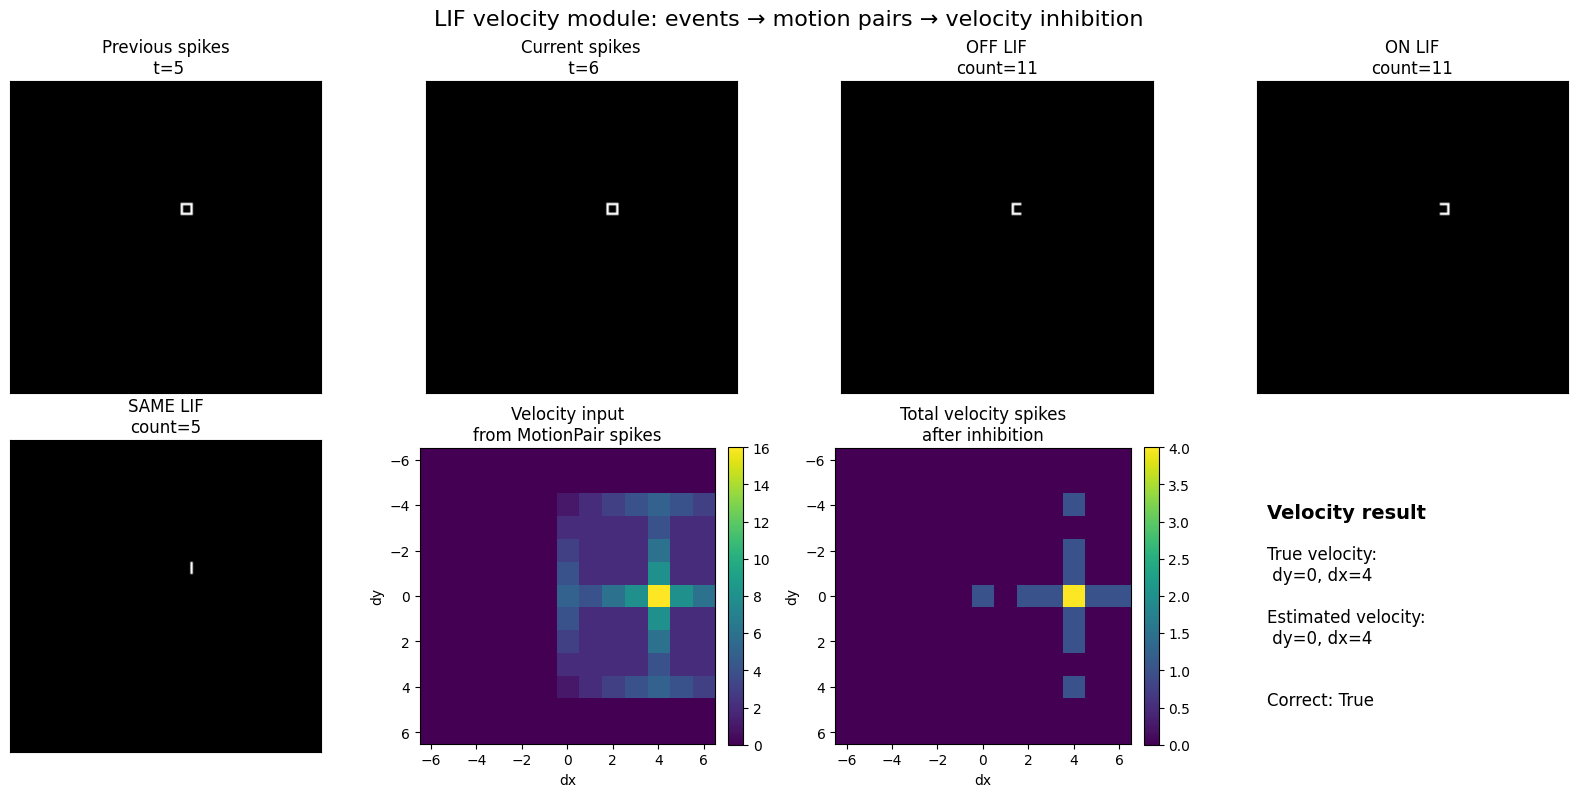

In [199]:
plot_velocity_module_summary_v2(
    case=explicit_test_case,
    result=explicit_result,
    previous_t=5,
    current_t=6,
    max_offset=6,
)

Now to object binding

In [200]:
def compute_motion_bound_object(
    previous_spikes,
    current_spikes,
    estimated_dy,
    estimated_dx,
):
    """
    Motion-based object binding.

    Given an estimated velocity (dy, dx), bind old-frame pixels to
    current-frame pixels that are consistent with that velocity.

    Returns:
        bound_previous:
            old-frame pixels that have a matching current-frame pixel

        bound_current:
            current-frame pixels that match an old-frame pixel

        stabilized_current_to_previous:
            current-frame object shifted back into previous-frame coordinates

    This is not yet a LIF layer. It is the binding/readout step that uses
    the winning velocity population.
    """

    previous_spikes = (previous_spikes > 0).float()
    current_spikes = (current_spikes > 0).float()

    height, width = previous_spikes.shape

    bound_previous = torch.zeros_like(previous_spikes)
    bound_current = torch.zeros_like(current_spikes)
    stabilized_current_to_previous = torch.zeros_like(previous_spikes)

    previous_positions = torch.nonzero(previous_spikes > 0, as_tuple=False)

    for pos in previous_positions:
        y = int(pos[0].item())
        x = int(pos[1].item())

        target_y = y + estimated_dy
        target_x = x + estimated_dx

        if not (0 <= target_y < height and 0 <= target_x < width):
            continue

        if current_spikes[target_y, target_x] > 0:
            bound_previous[y, x] = 1.0
            bound_current[target_y, target_x] = 1.0
            stabilized_current_to_previous[y, x] = 1.0

    return {
        "bound_previous": bound_previous,
        "bound_current": bound_current,
        "stabilized_current_to_previous": stabilized_current_to_previous,
    }

In [201]:
binding_result = compute_motion_bound_object(
    previous_spikes=explicit_test_case["spikes"][5],
    current_spikes=explicit_test_case["spikes"][6],
    estimated_dy=explicit_result["estimated_dy"],
    estimated_dx=explicit_result["estimated_dx"],
)

{
    "estimated_dy": explicit_result["estimated_dy"],
    "estimated_dx": explicit_result["estimated_dx"],
    "bound_previous_count": int(binding_result["bound_previous"].sum().item()),
    "bound_current_count": int(binding_result["bound_current"].sum().item()),
    "stabilized_count": int(binding_result["stabilized_current_to_previous"].sum().item()),
}

{'estimated_dy': 0,
 'estimated_dx': 4,
 'bound_previous_count': 16,
 'bound_current_count': 16,
 'stabilized_count': 16}

In [202]:
def plot_motion_binding_result(case, velocity_result, binding_result, previous_t=5, current_t=6):
    previous_spikes = case["spikes"][previous_t]
    current_spikes = case["spikes"][current_t]

    estimated_dy = velocity_result["estimated_dy"]
    estimated_dx = velocity_result["estimated_dx"]

    fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))

    axes[0].imshow(previous_spikes, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Previous spikes\n t={previous_t}")

    axes[1].imshow(current_spikes, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Current spikes\n t={current_t}")

    axes[2].imshow(binding_result["bound_previous"], cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Bound previous\nold object pixels")

    axes[3].imshow(binding_result["bound_current"], cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("Bound current\nnew object pixels")

    axes[4].imshow(binding_result["stabilized_current_to_previous"], cmap="gray", vmin=0, vmax=1)
    axes[4].set_title("Stabilized object\ncurrent shifted back")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(
        f"Motion binding using estimated velocity dy={estimated_dy}, dx={estimated_dx}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

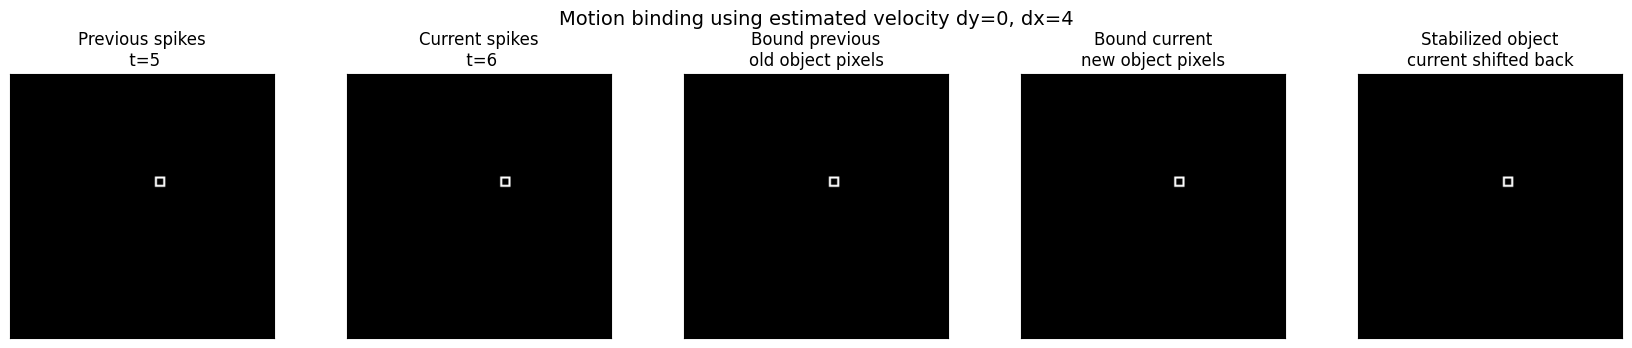

In [203]:
plot_motion_binding_result(
    case=explicit_test_case,
    velocity_result=explicit_result,
    binding_result=binding_result,
    previous_t=5,
    current_t=6,
)

In [204]:
def shift_frame(frame, shift_y, shift_x):
    """
    Shift a 2D frame by integer pixels.

    Positive shift_y moves pixels down.
    Positive shift_x moves pixels right.
    """

    height, width = frame.shape
    shifted = torch.zeros_like(frame)

    source_y_start = max(0, -shift_y)
    source_y_end = min(height, height - shift_y)

    source_x_start = max(0, -shift_x)
    source_x_end = min(width, width - shift_x)

    target_y_start = max(0, shift_y)
    target_y_end = min(height, height + shift_y)

    target_x_start = max(0, shift_x)
    target_x_end = min(width, width + shift_x)

    if source_y_start < source_y_end and source_x_start < source_x_end:
        shifted[
            target_y_start:target_y_end,
            target_x_start:target_x_end,
        ] = frame[
            source_y_start:source_y_end,
            source_x_start:source_x_end,
        ]

    return shifted

In [205]:
def align_frames_using_velocity(
    spikes,
    estimated_dy,
    estimated_dx,
    reference_t=0,
):
    """
    Align all frames into the coordinate system of reference_t.

    If the object moves by (dy, dx) each frame, then frame t is shifted back by:
        -(t - reference_t) * dy
        -(t - reference_t) * dx
    """

    aligned_frames = []

    num_steps = spikes.shape[0]

    for t in range(num_steps):
        delta_t = t - reference_t

        shift_y = -delta_t * estimated_dy
        shift_x = -delta_t * estimated_dx

        aligned = shift_frame(
            frame=spikes[t],
            shift_y=shift_y,
            shift_x=shift_x,
        )

        aligned_frames.append(aligned)

    return torch.stack(aligned_frames, dim=0)

In [206]:
def accumulate_aligned_frames_lif(
    aligned_frames,
    beta=0.8,
    threshold=2.5,
    reset_mode="subtract",
):
    """
    LIF accumulation over aligned object frames.

    Each pixel has a LIF accumulator.
    Repeated aligned spikes at the same object-centered location
    push the membrane over threshold.
    """

    membrane = torch.zeros_like(aligned_frames[0])
    spike_history = []
    membrane_history = []

    for t in range(aligned_frames.shape[0]):
        spikes, membrane = lif_step(
            input_current=aligned_frames[t],
            membrane=membrane,
            beta=beta,
            threshold=threshold,
            reset_mode=reset_mode,
        )

        spike_history.append(spikes.clone())
        membrane_history.append(membrane.clone())

    return {
        "accumulated_spike_history": torch.stack(spike_history, dim=0),
        "accumulated_membrane_history": torch.stack(membrane_history, dim=0),
        "final_accumulated_spikes": spike_history[-1],
        "final_membrane": membrane_history[-1],
    }

In [207]:
temporal_shape_case = make_unblurred_spike_case_from_velocity(
    velocity_y=0,
    velocity_x=4,
    shape_name="seven",
    start_top=50,
    start_left=30,
)

In [208]:
temporal_velocity_result = estimate_velocity_with_explicit_motion_pairs_and_inhibition(
    previous_spikes=temporal_shape_case["spikes"][5],
    current_spikes=temporal_shape_case["spikes"][6],
    max_offset=6,
    **GOOD_VELOCITY_PARAMS,
)

temporal_velocity_result["estimated_dy"], temporal_velocity_result["estimated_dx"]

(0, 4)

In [209]:
aligned_temporal_frames = align_frames_using_velocity(
    spikes=temporal_shape_case["spikes"],
    estimated_dy=temporal_velocity_result["estimated_dy"],
    estimated_dx=temporal_velocity_result["estimated_dx"],
    reference_t=0,
)

In [210]:
temporal_accumulation = accumulate_aligned_frames_lif(
    aligned_frames=aligned_temporal_frames,
    beta=0.8,
    threshold=2.5,
    reset_mode="subtract",
)

In [211]:
def plot_temporal_alignment_and_accumulation(
    case,
    aligned_frames,
    accumulation_result,
):
    original_spikes = case["spikes"]
    accumulated_spike_history = accumulation_result["accumulated_spike_history"]
    final_membrane = accumulation_result["final_membrane"]

    num_steps = original_spikes.shape[0]

    fig, axes = plt.subplots(3, num_steps, figsize=(2.5 * num_steps, 7.5))

    for t in range(num_steps):
        axes[0, t].imshow(original_spikes[t], cmap="gray", vmin=0, vmax=1)
        axes[0, t].set_title(f"Original\nt={t}")

        axes[1, t].imshow(aligned_frames[t], cmap="gray", vmin=0, vmax=1)
        axes[1, t].set_title(f"Aligned\nt={t}")

        axes[2, t].imshow(accumulated_spike_history[t], cmap="gray", vmin=0, vmax=1)
        axes[2, t].set_title(
            f"Accumulator spikes\nt={t}\ncount={int(accumulated_spike_history[t].sum().item())}"
        )

        for row in range(3):
            axes[row, t].set_xticks([])
            axes[row, t].set_yticks([])

    plt.suptitle(
        "Motion-aligned temporal accumulation for shape recognition",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 4))
    plt.imshow(final_membrane)
    plt.title("Final LIF membrane after repeated aligned frames")
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
    plt.show()

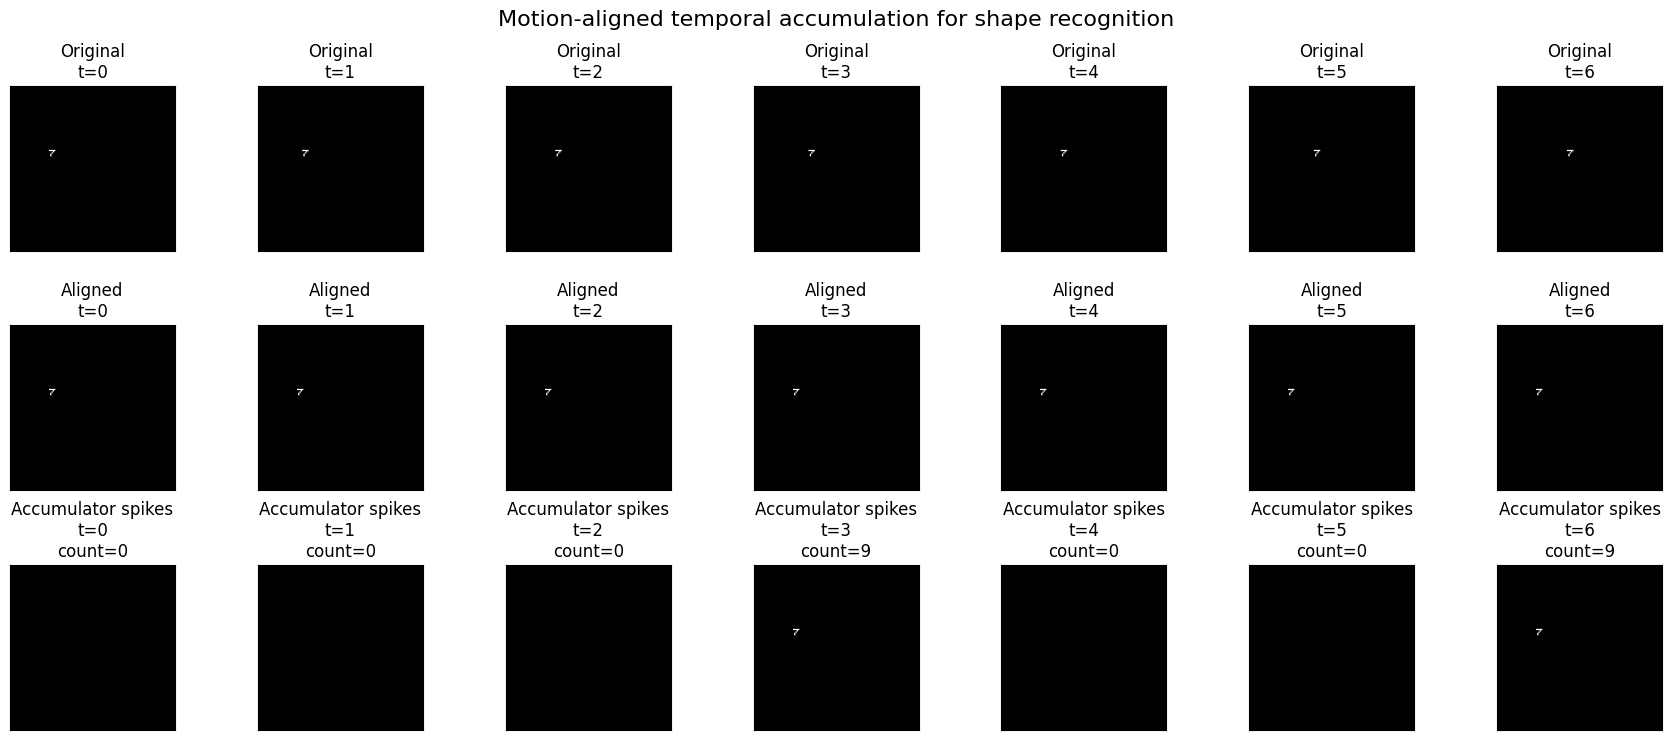

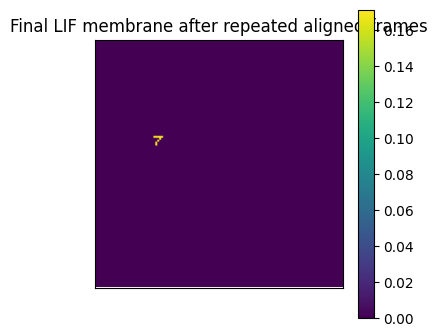

In [212]:
plot_temporal_alignment_and_accumulation(
    case=temporal_shape_case,
    aligned_frames=aligned_temporal_frames,
    accumulation_result=temporal_accumulation,
)

## Stable object layer from winning motion-pair sheet

In [213]:
def get_winning_motion_pair_sheet(result):
    """
    Extract the MotionPair[estimated_dy, estimated_dx, :, :] sheet.

    This sheet is already in object-centered coordinates:
        MotionPair[dy, dx, y, x] spikes when old position (y, x)
        matches current position (y + dy, x + dx).

    So the winning sheet can be interpreted as a stabilized object spike map.
    """

    estimated_dy = result["estimated_dy"]
    estimated_dx = result["estimated_dx"]

    offset_table = result["offset_table"]
    motion_pair_spikes = result["motion_pair_spikes"]

    matching_rows = offset_table[
        (offset_table["dy"] == estimated_dy)
        & (offset_table["dx"] == estimated_dx)
    ]

    if len(matching_rows) != 1:
        raise ValueError("Could not uniquely identify winning velocity in offset_table.")

    offset_index = int(matching_rows.iloc[0]["offset_index"])

    winning_sheet = motion_pair_spikes[offset_index]

    return {
        "stable_object_spikes": winning_sheet,
        "offset_index": offset_index,
        "estimated_dy": estimated_dy,
        "estimated_dx": estimated_dx,
    }

In [214]:
stable_object_result = get_winning_motion_pair_sheet(
    explicit_result
)

{
    "estimated_dy": stable_object_result["estimated_dy"],
    "estimated_dx": stable_object_result["estimated_dx"],
    "stable_object_spike_count": int(stable_object_result["stable_object_spikes"].sum().item()),
}

{'estimated_dy': 0, 'estimated_dx': 4, 'stable_object_spike_count': 16}

In [215]:
def plot_stable_object_from_motion_pairs(case, velocity_result, stable_object_result, previous_t=5, current_t=6):
    previous_spikes = case["spikes"][previous_t]
    current_spikes = case["spikes"][current_t]

    stable_object_spikes = stable_object_result["stable_object_spikes"]

    estimated_dy = stable_object_result["estimated_dy"]
    estimated_dx = stable_object_result["estimated_dx"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

    axes[0].imshow(previous_spikes, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Previous input\n t={previous_t}")

    axes[1].imshow(current_spikes, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Current input\n t={current_t}")

    axes[2].imshow(stable_object_spikes, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title(
        f"StableObject from\nMotionPair[{estimated_dy},{estimated_dx},:,:]"
    )

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle("Stable object layer from winning motion-pair sheet")
    plt.tight_layout()
    plt.show()

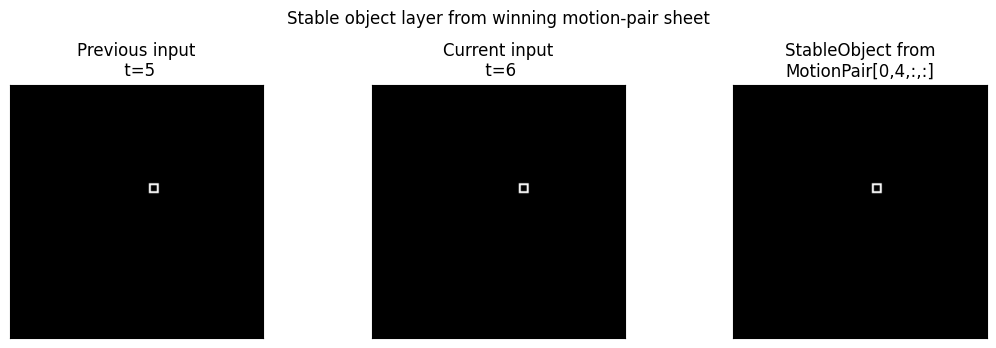

In [216]:
plot_stable_object_from_motion_pairs(
    case=explicit_test_case,
    velocity_result=explicit_result,
    stable_object_result=stable_object_result,
    previous_t=5,
    current_t=6,
)

Need to work for mor ethan 2 frames

In [223]:
def update_object_memory_with_velocity_gate(
    previous_memory_trace,
    current_input_spikes,
    memory_to_input_dy,
    memory_to_input_dx,
    memory_membrane,
    trace_weight=1.0,
    input_weight=1.0,
    velocity_gate_weight=1.0,
    threshold_memory=2.5,
    beta_memory=0.8,
    reset_mode="subtract",
):
    """
    Velocity-gated object-memory update.

    ObjectMemory[y,x] represents a stable object-centered location.

    memory_to_input_dy, memory_to_input_dx tell us where that memory location
    should appear in the current input frame.

    For each ObjectMemory[y,x]:

        previous memory trace at (y,x)
        + current input at (y + memory_to_input_dy, x + memory_to_input_dx)
        + velocity gate
        -> ObjectMemory[y,x] spike

    The important correction:
        For frame t, we do NOT always look one step ahead.
        We look at the current predicted input position.
    """

    previous_memory_trace = (previous_memory_trace > 0).float()
    current_input_spikes = (current_input_spikes > 0).float()

    height, width = current_input_spikes.shape

    routed_current_input = torch.zeros_like(current_input_spikes)

    active_memory_positions = torch.nonzero(
        previous_memory_trace > 0,
        as_tuple=False,
    )

    for pos in active_memory_positions:
        y = int(pos[0].item())
        x = int(pos[1].item())

        source_y = y + memory_to_input_dy
        source_x = x + memory_to_input_dx

        if not (0 <= source_y < height and 0 <= source_x < width):
            continue

        if current_input_spikes[source_y, source_x] > 0:
            routed_current_input[y, x] = 1.0

    # Only locations with predicted current input should receive update current.
    memory_input_current = (
        trace_weight * previous_memory_trace
        + input_weight * routed_current_input
        + velocity_gate_weight * routed_current_input
    )

    # Require both old memory and a matched routed current input.
    memory_input_current = memory_input_current * previous_memory_trace * routed_current_input

    memory_spikes, memory_membrane = lif_step(
        input_current=memory_input_current,
        membrane=memory_membrane,
        beta=beta_memory,
        threshold=threshold_memory,
        reset_mode=reset_mode,
    )

    # Keep tracking the same object locations.
    new_memory_trace = previous_memory_trace.clone()

    return {
        "memory_spikes": memory_spikes,
        "memory_membrane": memory_membrane,
        "memory_trace": new_memory_trace,
        "routed_current_input": routed_current_input,
        "memory_input_current": memory_input_current,
    }

In [224]:
def run_velocity_gated_object_memory(
    case,
    max_offset=6,
    velocity_params=None,
    trace_weight=1.0,
    input_weight=1.0,
    velocity_gate_weight=1.0,
    threshold_memory=2.5,
    beta_memory=0.8,
    reset_mode="subtract",
):
    """
    Run velocity-gated ObjectMemory over all frames.

    Frame 0 initializes ObjectMemory.

    For each transition t-1 -> t:
        1. Estimate velocity from input frames.
        2. Add that velocity to cumulative displacement.
        3. Route current input back into the original ObjectMemory coordinates.
        4. Run LIF update.
    """

    if velocity_params is None:
        velocity_params = {}

    spikes = case["spikes"]
    num_steps = spikes.shape[0]

    memory_trace = (spikes[0] > 0).float()
    memory_membrane = torch.zeros_like(memory_trace)

    cumulative_dy = 0
    cumulative_dx = 0

    memory_spike_history = []
    memory_trace_history = []
    memory_membrane_history = []
    routed_input_history = []
    velocity_rows = []

    # Frame 0 initializes memory.
    memory_spike_history.append(memory_trace.clone())
    memory_trace_history.append(memory_trace.clone())
    memory_membrane_history.append(memory_membrane.clone())
    routed_input_history.append(memory_trace.clone())

    velocity_rows.append({
        "t": 0,
        "previous_t": None,
        "current_t": 0,
        "estimated_dy": None,
        "estimated_dx": None,
        "cumulative_dy": cumulative_dy,
        "cumulative_dx": cumulative_dx,
        "note": "initialize memory from first frame",
    })

    for t in range(1, num_steps):
        velocity_result = estimate_velocity_with_explicit_motion_pairs_and_inhibition(
            previous_spikes=spikes[t - 1],
            current_spikes=spikes[t],
            max_offset=max_offset,
            **velocity_params,
        )

        estimated_dy = velocity_result["estimated_dy"]
        estimated_dx = velocity_result["estimated_dx"]

        if estimated_dy is None or estimated_dx is None:
            memory_spikes = torch.zeros_like(memory_trace)
            routed_current_input = torch.zeros_like(memory_trace)
            memory_input_current = torch.zeros_like(memory_trace)
        else:
            cumulative_dy += estimated_dy
            cumulative_dx += estimated_dx

            update_result = update_object_memory_with_velocity_gate(
                previous_memory_trace=memory_trace,
                current_input_spikes=spikes[t],
                memory_to_input_dy=cumulative_dy,
                memory_to_input_dx=cumulative_dx,
                memory_membrane=memory_membrane,
                trace_weight=trace_weight,
                input_weight=input_weight,
                velocity_gate_weight=velocity_gate_weight,
                threshold_memory=threshold_memory,
                beta_memory=beta_memory,
                reset_mode=reset_mode,
            )

            memory_spikes = update_result["memory_spikes"]
            memory_membrane = update_result["memory_membrane"]
            memory_trace = update_result["memory_trace"]
            routed_current_input = update_result["routed_current_input"]
            memory_input_current = update_result["memory_input_current"]

        memory_spike_history.append(memory_spikes.clone())
        memory_trace_history.append(memory_trace.clone())
        memory_membrane_history.append(memory_membrane.clone())
        routed_input_history.append(routed_current_input.clone())

        velocity_rows.append({
            "t": t,
            "previous_t": t - 1,
            "current_t": t,
            "estimated_dy": estimated_dy,
            "estimated_dx": estimated_dx,
            "cumulative_dy": cumulative_dy,
            "cumulative_dx": cumulative_dx,
            "note": "velocity-gated memory update",
        })

    return {
        "memory_spike_history": torch.stack(memory_spike_history, dim=0),
        "memory_trace_history": torch.stack(memory_trace_history, dim=0),
        "memory_membrane_history": torch.stack(memory_membrane_history, dim=0),
        "routed_input_history": torch.stack(routed_input_history, dim=0),
        "velocity_table": pd.DataFrame(velocity_rows),
    }

In [225]:
object_memory_case = make_unblurred_spike_case_from_velocity(
    velocity_y=0,
    velocity_x=4,
    shape_name="seven",
    start_top=50,
    start_left=30,
)

object_memory_result = run_velocity_gated_object_memory(
    case=object_memory_case,
    max_offset=6,
    velocity_params=GOOD_VELOCITY_PARAMS,
    trace_weight=1.0,
    input_weight=1.0,
    velocity_gate_weight=1.0,
    threshold_memory=2.5,
    beta_memory=0.8,
    reset_mode="subtract",
)

object_memory_result["velocity_table"]

,t,previous_t,current_t,estimated_dy,estimated_dx,cumulative_dy,cumulative_dx,note
0,0,NaN,0,NaN,NaN,0,0,initialize memory from first frame
1,1,0.0,1,0.0,4.0,0,4,velocity-gated memory update
2,2,1.0,2,0.0,4.0,0,8,velocity-gated memory update
3,3,2.0,3,0.0,4.0,0,12,velocity-gated memory update
4,4,3.0,4,0.0,4.0,0,16,velocity-gated memory update
5,5,4.0,5,0.0,4.0,0,20,velocity-gated memory update
6,6,5.0,6,0.0,4.0,0,24,velocity-gated memory update


In [226]:
def plot_object_memory_result(case, object_memory_result):
    input_spikes = case["spikes"]
    memory_spike_history = object_memory_result["memory_spike_history"]
    memory_trace_history = object_memory_result["memory_trace_history"]
    routed_input_history = object_memory_result["routed_input_history"]

    num_steps = input_spikes.shape[0]

    fig, axes = plt.subplots(4, num_steps, figsize=(2.5 * num_steps, 10))

    for t in range(num_steps):
        axes[0, t].imshow(input_spikes[t], cmap="gray", vmin=0, vmax=1)
        axes[0, t].set_title(f"Input spikes\n t={t}")

        axes[1, t].imshow(routed_input_history[t], cmap="gray", vmin=0, vmax=1)
        axes[1, t].set_title(
            f"Velocity-routed\ncurrent input t={t}"
        )

        axes[2, t].imshow(memory_spike_history[t], cmap="gray", vmin=0, vmax=1)
        axes[2, t].set_title(
            f"ObjectMemory spikes\n t={t}\ncount={int(memory_spike_history[t].sum().item())}"
        )

        axes[3, t].imshow(memory_trace_history[t], cmap="gray", vmin=0, vmax=1)
        axes[3, t].set_title(
            f"ObjectMemory trace\n t={t}"
        )

        for row in range(4):
            axes[row, t].set_xticks([])
            axes[row, t].set_yticks([])

    plt.suptitle(
        "Velocity-gated object memory: moving input, stable memory",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

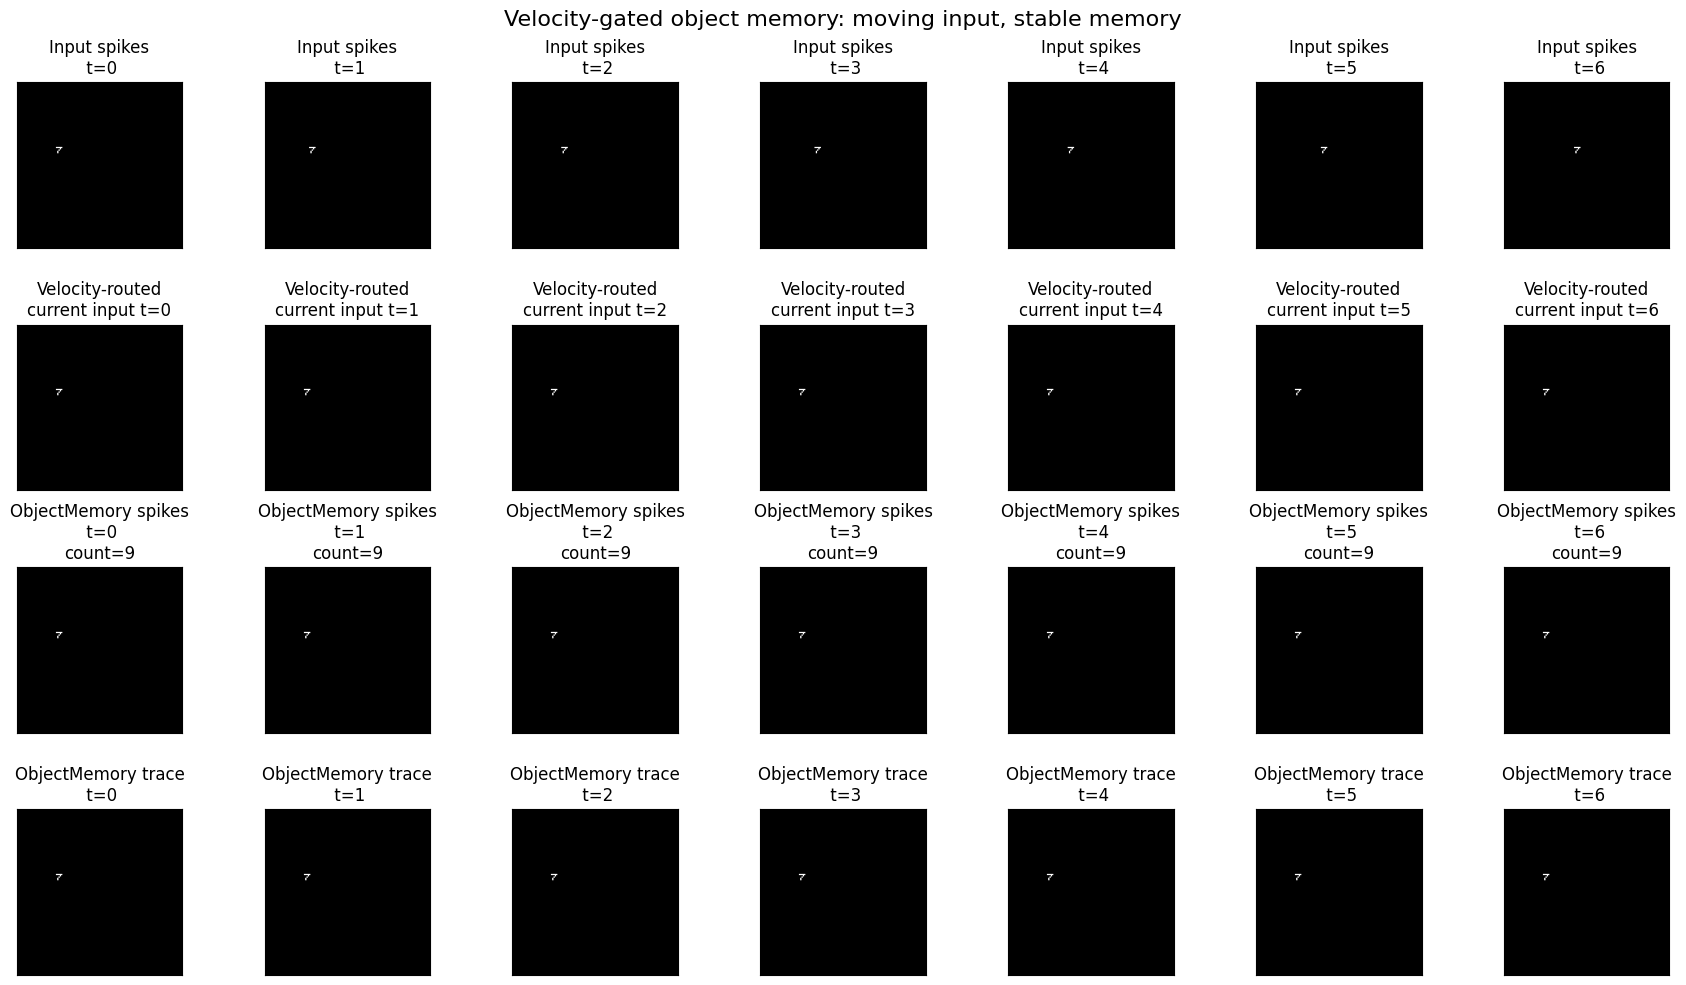

In [227]:
plot_object_memory_result(
    case=object_memory_case,
    object_memory_result=object_memory_result,
)

The object-memory module has two internal quantities:
1. a persistent trace used to keep track of the object
2. a spiking output that sends evidence downstream

Need to fix velcoity feedign into the object memory

In [228]:
def get_velocity_gate_from_result(
    velocity_result,
    use_total_spikes=True,
):
    """
    Return a velocity gate grid from the velocity layer.

    Shape:
        [2*max_offset+1, 2*max_offset+1]

    Entry [i,j] corresponds to Velocity[dy,dx].

    This avoids decoding one Python velocity winner.
    The object-memory routing will use all active velocity populations.
    """

    velocity_spike_history = velocity_result["velocity_layer"]["velocity_spike_history"]

    if use_total_spikes:
        velocity_gate = velocity_spike_history.sum(dim=0)
        velocity_gate = (velocity_gate > 0).float()
    else:
        velocity_gate = velocity_spike_history[-1]
        velocity_gate = (velocity_gate > 0).float()

    return velocity_gate

In [230]:
def route_current_input_with_velocity_population(
    previous_memory_trace,
    current_input_spikes,
    velocity_gate,
    max_offset=6,
):
    """
    Route current input into ObjectMemory coordinates using all active
    velocity populations in parallel.

    For each ObjectMemory[y,x] and each possible velocity (dy,dx):

        Velocity[dy,dx]
        +
        CurrentInput[y+dy, x+dx]
        ->
        RoutedInput[y,x]

    No decoded estimated_dy/estimated_dx is used.
    """

    previous_memory_trace = (previous_memory_trace > 0).float()
    current_input_spikes = (current_input_spikes > 0).float()
    velocity_gate = (velocity_gate > 0).float()

    height, width = current_input_spikes.shape

    routed_current_input = torch.zeros_like(current_input_spikes)

    active_memory_positions = torch.nonzero(
        previous_memory_trace > 0,
        as_tuple=False,
    )

    active_velocity_positions = torch.nonzero(
        velocity_gate > 0,
        as_tuple=False,
    )

    for memory_pos in active_memory_positions:
        y = int(memory_pos[0].item())
        x = int(memory_pos[1].item())

        for velocity_pos in active_velocity_positions:
            velocity_i = int(velocity_pos[0].item())
            velocity_j = int(velocity_pos[1].item())

            dy = velocity_i - max_offset
            dx = velocity_j - max_offset

            source_y = y + dy
            source_x = x + dx

            if not (0 <= source_y < height and 0 <= source_x < width):
                continue

            if current_input_spikes[source_y, source_x] > 0:
                routed_current_input[y, x] = 1.0

    return routed_current_input

In [231]:
def update_object_memory_from_routed_input(
    previous_memory_trace,
    routed_current_input,
    memory_membrane,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
):
    """
    LIF object-memory update after parallel velocity-gated routing.

    ObjectMemory[y,x] receives:
        previous memory trace at (y,x)
        routed current input at (y,x)

    If both are present, the neuron gets enough current to spike.
    """

    previous_memory_trace = (previous_memory_trace > 0).float()
    routed_current_input = (routed_current_input > 0).float()

    memory_input_current = (
        trace_weight * previous_memory_trace
        + input_weight * routed_current_input
    )

    # Require current routed evidence.
    memory_input_current = memory_input_current * previous_memory_trace * routed_current_input

    memory_spikes, memory_membrane = lif_step(
        input_current=memory_input_current,
        membrane=memory_membrane,
        beta=beta_memory,
        threshold=threshold_memory,
        reset_mode=reset_mode,
    )

    new_memory_trace = previous_memory_trace.clone()

    return {
        "memory_spikes": memory_spikes,
        "memory_membrane": memory_membrane,
        "memory_trace": new_memory_trace,
        "memory_input_current": memory_input_current,
    }

In [232]:
def run_parallel_velocity_gated_object_memory(
    case,
    max_offset=6,
    velocity_params=None,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
):
    """
    Run ObjectMemory using parallel velocity-gated routes.

    Important:
        This version does NOT decode estimated_dy, estimated_dx
        to choose a single route.

    Instead:
        velocity layer spikes create a velocity_gate grid
        all active velocity routes are applied in parallel
    """

    if velocity_params is None:
        velocity_params = {}

    spikes = case["spikes"]
    num_steps = spikes.shape[0]

    memory_trace = (spikes[0] > 0).float()
    memory_membrane = torch.zeros_like(memory_trace)

    memory_spike_history = []
    memory_trace_history = []
    memory_membrane_history = []
    routed_input_history = []
    velocity_gate_history = []
    velocity_rows = []

    memory_spike_history.append(memory_trace.clone())
    memory_trace_history.append(memory_trace.clone())
    memory_membrane_history.append(memory_membrane.clone())
    routed_input_history.append(memory_trace.clone())

    velocity_gate_history.append(
        torch.zeros((2 * max_offset + 1, 2 * max_offset + 1), dtype=torch.float32)
    )

    velocity_rows.append({
        "t": 0,
        "previous_t": None,
        "current_t": 0,
        "num_active_velocity_gates": 0,
        "note": "initialize memory from first frame",
    })

    for t in range(1, num_steps):
        velocity_result = estimate_velocity_with_explicit_motion_pairs_and_inhibition(
            previous_spikes=spikes[t - 1],
            current_spikes=spikes[t],
            max_offset=max_offset,
            **velocity_params,
        )

        velocity_gate = get_velocity_gate_from_result(
            velocity_result=velocity_result,
            use_total_spikes=True,
        )

        routed_current_input = route_current_input_with_velocity_population(
            previous_memory_trace=memory_trace,
            current_input_spikes=spikes[t],
            velocity_gate=velocity_gate,
            max_offset=max_offset,
        )

        update_result = update_object_memory_from_routed_input(
            previous_memory_trace=memory_trace,
            routed_current_input=routed_current_input,
            memory_membrane=memory_membrane,
            trace_weight=trace_weight,
            input_weight=input_weight,
            threshold_memory=threshold_memory,
            beta_memory=beta_memory,
            reset_mode=reset_mode,
        )

        memory_spikes = update_result["memory_spikes"]
        memory_membrane = update_result["memory_membrane"]
        memory_trace = update_result["memory_trace"]

        memory_spike_history.append(memory_spikes.clone())
        memory_trace_history.append(memory_trace.clone())
        memory_membrane_history.append(memory_membrane.clone())
        routed_input_history.append(routed_current_input.clone())
        velocity_gate_history.append(velocity_gate.clone())

        velocity_rows.append({
            "t": t,
            "previous_t": t - 1,
            "current_t": t,
            "num_active_velocity_gates": int(velocity_gate.sum().item()),
            "note": "parallel velocity-gated memory update",
        })

    return {
        "memory_spike_history": torch.stack(memory_spike_history, dim=0),
        "memory_trace_history": torch.stack(memory_trace_history, dim=0),
        "memory_membrane_history": torch.stack(memory_membrane_history, dim=0),
        "routed_input_history": torch.stack(routed_input_history, dim=0),
        "velocity_gate_history": torch.stack(velocity_gate_history, dim=0),
        "velocity_table": pd.DataFrame(velocity_rows),
    }

In [233]:
parallel_object_memory_result = run_parallel_velocity_gated_object_memory(
    case=object_memory_case,
    max_offset=6,
    velocity_params=GOOD_VELOCITY_PARAMS,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
)

parallel_object_memory_result["velocity_table"]

,t,previous_t,current_t,num_active_velocity_gates,note
0,0,NaN,0,0,initialize memory from first frame
1,1,0.0,1,1,parallel velocity-gated memory update
2,2,1.0,2,1,parallel velocity-gated memory update
3,3,2.0,3,1,parallel velocity-gated memory update
4,4,3.0,4,1,parallel velocity-gated memory update
5,5,4.0,5,1,parallel velocity-gated memory update
6,6,5.0,6,1,parallel velocity-gated memory update


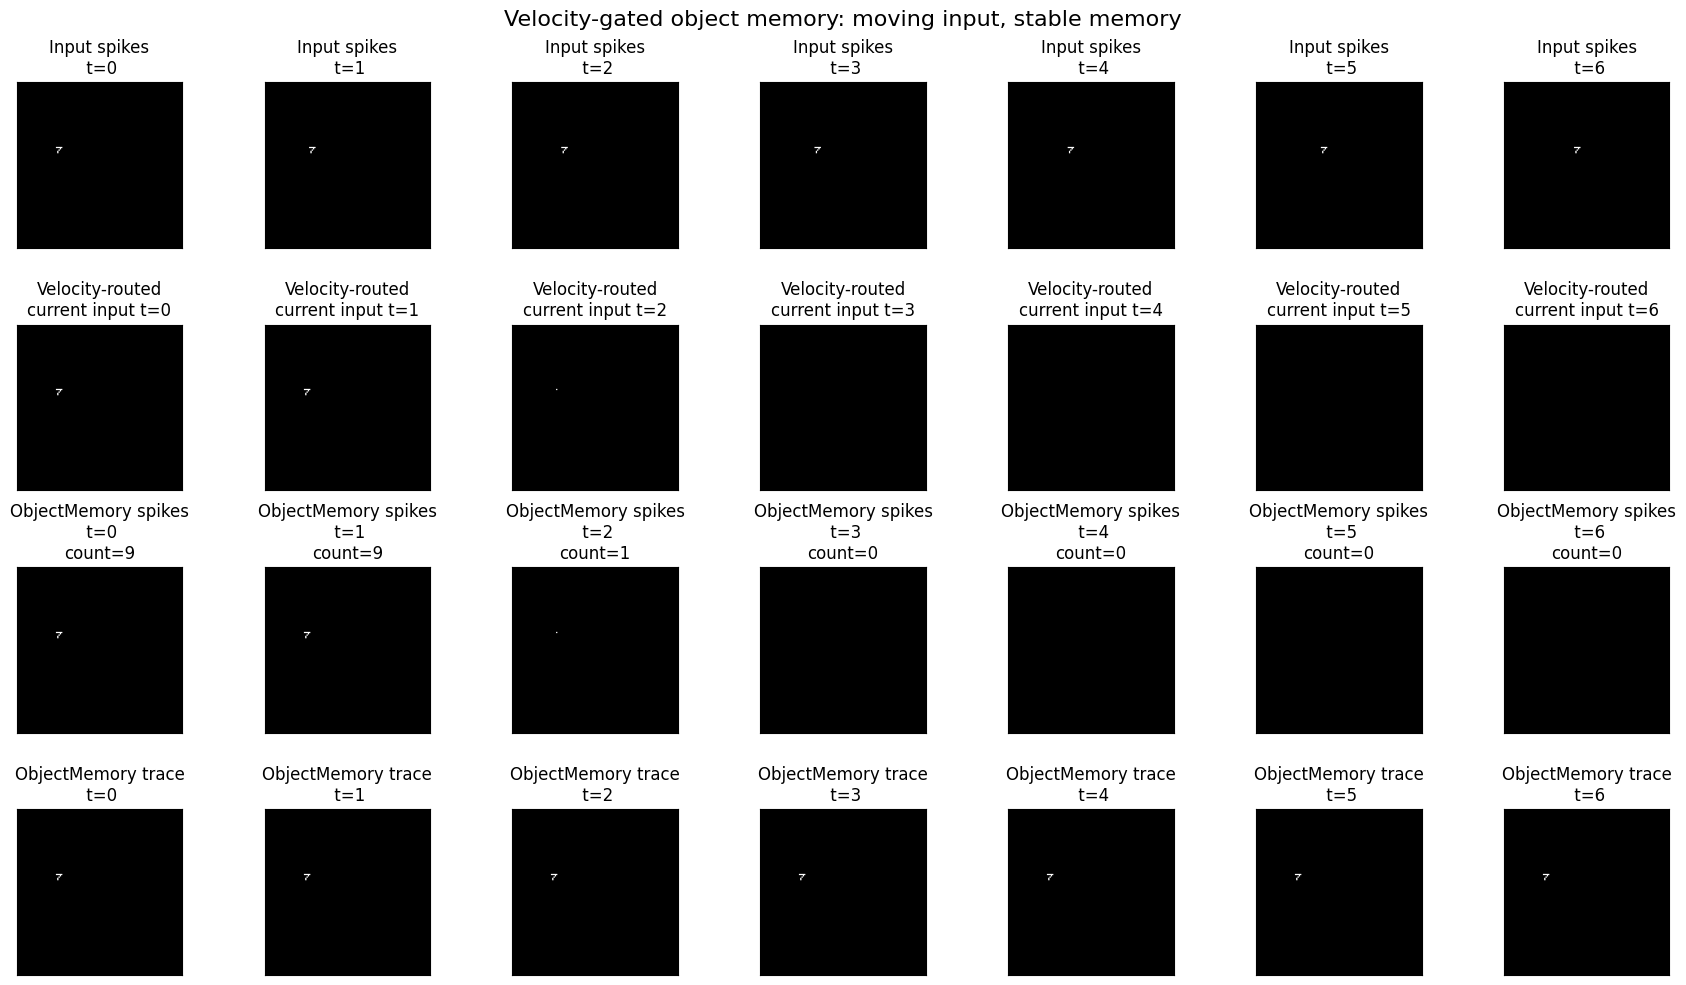

In [234]:
plot_object_memory_result(
    case=object_memory_case,
    object_memory_result=parallel_object_memory_result,
)

In [235]:
def initialize_displacement_gate(max_displacement):
    """
    Displacement[D_y, D_x] population.

    Initially the object memory is anchored to frame 0, so cumulative
    displacement is zero.
    """

    size = 2 * max_displacement + 1
    displacement_gate = torch.zeros((size, size), dtype=torch.float32)

    center = max_displacement
    displacement_gate[center, center] = 1.0

    return displacement_gate

In [236]:
def update_displacement_gate_from_velocity_gate(
    previous_displacement_gate,
    velocity_gate,
    max_velocity=6,
    max_displacement=36,
):
    """
    Update cumulative displacement using velocity populations.

    Previous Displacement[D_y, D_x]
    +
    Velocity[dy, dx]
    ->
    New Displacement[D_y + dy, D_x + dx]

    This is a population update, not Python decoding one velocity.
    """

    previous_displacement_gate = (previous_displacement_gate > 0).float()
    velocity_gate = (velocity_gate > 0).float()

    new_displacement_gate = torch.zeros_like(previous_displacement_gate)

    active_displacements = torch.nonzero(
        previous_displacement_gate > 0,
        as_tuple=False,
    )

    active_velocities = torch.nonzero(
        velocity_gate > 0,
        as_tuple=False,
    )

    for displacement_pos in active_displacements:
        disp_i = int(displacement_pos[0].item())
        disp_j = int(displacement_pos[1].item())

        current_D_y = disp_i - max_displacement
        current_D_x = disp_j - max_displacement

        for velocity_pos in active_velocities:
            vel_i = int(velocity_pos[0].item())
            vel_j = int(velocity_pos[1].item())

            dy = vel_i - max_velocity
            dx = vel_j - max_velocity

            new_D_y = current_D_y + dy
            new_D_x = current_D_x + dx

            new_i = new_D_y + max_displacement
            new_j = new_D_x + max_displacement

            if not (0 <= new_i < new_displacement_gate.shape[0]):
                continue

            if not (0 <= new_j < new_displacement_gate.shape[1]):
                continue

            new_displacement_gate[new_i, new_j] = 1.0

    return new_displacement_gate

In [237]:
def route_current_input_with_displacement_population(
    previous_memory_trace,
    current_input_spikes,
    displacement_gate,
    max_displacement=36,
):
    """
    Route current input into ObjectMemory coordinates using cumulative
    displacement populations.

    For each ObjectMemory[y,x] and active displacement (D_y,D_x):

        Displacement[D_y,D_x]
        +
        CurrentInput[y + D_y, x + D_x]
        ->
        RoutedInput[y,x]

    This is what keeps ObjectMemory anchored to frame 0.
    """

    previous_memory_trace = (previous_memory_trace > 0).float()
    current_input_spikes = (current_input_spikes > 0).float()
    displacement_gate = (displacement_gate > 0).float()

    height, width = current_input_spikes.shape

    routed_current_input = torch.zeros_like(current_input_spikes)

    active_memory_positions = torch.nonzero(
        previous_memory_trace > 0,
        as_tuple=False,
    )

    active_displacements = torch.nonzero(
        displacement_gate > 0,
        as_tuple=False,
    )

    for memory_pos in active_memory_positions:
        y = int(memory_pos[0].item())
        x = int(memory_pos[1].item())

        for displacement_pos in active_displacements:
            disp_i = int(displacement_pos[0].item())
            disp_j = int(displacement_pos[1].item())

            D_y = disp_i - max_displacement
            D_x = disp_j - max_displacement

            source_y = y + D_y
            source_x = x + D_x

            if not (0 <= source_y < height and 0 <= source_x < width):
                continue

            if current_input_spikes[source_y, source_x] > 0:
                routed_current_input[y, x] = 1.0

    return routed_current_input

In [238]:
def update_object_memory_from_routed_input(
    previous_memory_trace,
    routed_current_input,
    memory_membrane,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
):
    """
    LIF object-memory update after displacement-gated routing.

    ObjectMemory[y,x] receives:
        previous memory trace at (y,x)
        routed current input at (y,x)

    If both are present, the neuron gets enough current to spike.
    """

    previous_memory_trace = (previous_memory_trace > 0).float()
    routed_current_input = (routed_current_input > 0).float()

    memory_input_current = (
        trace_weight * previous_memory_trace
        + input_weight * routed_current_input
    )

    memory_input_current = (
        memory_input_current
        * previous_memory_trace
        * routed_current_input
    )

    memory_spikes, memory_membrane = lif_step(
        input_current=memory_input_current,
        membrane=memory_membrane,
        beta=beta_memory,
        threshold=threshold_memory,
        reset_mode=reset_mode,
    )

    new_memory_trace = previous_memory_trace.clone()

    return {
        "memory_spikes": memory_spikes,
        "memory_membrane": memory_membrane,
        "memory_trace": new_memory_trace,
        "memory_input_current": memory_input_current,
    }

In [239]:
def run_displacement_gated_object_memory(
    case,
    max_velocity=6,
    max_displacement=36,
    velocity_params=None,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
):
    """
    Run ObjectMemory using:

        Velocity populations
        ->
        Displacement populations
        ->
        displacement-gated routing into ObjectMemory

    This avoids Python decoding one velocity for routing.
    """

    if velocity_params is None:
        velocity_params = {}

    spikes = case["spikes"]
    num_steps = spikes.shape[0]

    memory_trace = (spikes[0] > 0).float()
    memory_membrane = torch.zeros_like(memory_trace)

    displacement_gate = initialize_displacement_gate(
        max_displacement=max_displacement,
    )

    memory_spike_history = []
    memory_trace_history = []
    memory_membrane_history = []
    routed_input_history = []
    velocity_gate_history = []
    displacement_gate_history = []
    table_rows = []

    memory_spike_history.append(memory_trace.clone())
    memory_trace_history.append(memory_trace.clone())
    memory_membrane_history.append(memory_membrane.clone())
    routed_input_history.append(memory_trace.clone())

    velocity_gate_history.append(
        torch.zeros((2 * max_velocity + 1, 2 * max_velocity + 1), dtype=torch.float32)
    )

    displacement_gate_history.append(displacement_gate.clone())

    table_rows.append({
        "t": 0,
        "previous_t": None,
        "current_t": 0,
        "num_active_velocity_gates": 0,
        "num_active_displacement_gates": int(displacement_gate.sum().item()),
        "note": "initialize memory and zero displacement",
    })

    for t in range(1, num_steps):
        velocity_result = estimate_velocity_with_explicit_motion_pairs_and_inhibition(
            previous_spikes=spikes[t - 1],
            current_spikes=spikes[t],
            max_offset=max_velocity,
            **velocity_params,
        )

        velocity_gate = get_velocity_gate_from_result(
            velocity_result=velocity_result,
            use_total_spikes=True,
        )

        displacement_gate = update_displacement_gate_from_velocity_gate(
            previous_displacement_gate=displacement_gate,
            velocity_gate=velocity_gate,
            max_velocity=max_velocity,
            max_displacement=max_displacement,
        )

        routed_current_input = route_current_input_with_displacement_population(
            previous_memory_trace=memory_trace,
            current_input_spikes=spikes[t],
            displacement_gate=displacement_gate,
            max_displacement=max_displacement,
        )

        update_result = update_object_memory_from_routed_input(
            previous_memory_trace=memory_trace,
            routed_current_input=routed_current_input,
            memory_membrane=memory_membrane,
            trace_weight=trace_weight,
            input_weight=input_weight,
            threshold_memory=threshold_memory,
            beta_memory=beta_memory,
            reset_mode=reset_mode,
        )

        memory_spikes = update_result["memory_spikes"]
        memory_membrane = update_result["memory_membrane"]
        memory_trace = update_result["memory_trace"]

        memory_spike_history.append(memory_spikes.clone())
        memory_trace_history.append(memory_trace.clone())
        memory_membrane_history.append(memory_membrane.clone())
        routed_input_history.append(routed_current_input.clone())
        velocity_gate_history.append(velocity_gate.clone())
        displacement_gate_history.append(displacement_gate.clone())

        table_rows.append({
            "t": t,
            "previous_t": t - 1,
            "current_t": t,
            "num_active_velocity_gates": int(velocity_gate.sum().item()),
            "num_active_displacement_gates": int(displacement_gate.sum().item()),
            "note": "displacement-gated memory update",
        })

    return {
        "memory_spike_history": torch.stack(memory_spike_history, dim=0),
        "memory_trace_history": torch.stack(memory_trace_history, dim=0),
        "memory_membrane_history": torch.stack(memory_membrane_history, dim=0),
        "routed_input_history": torch.stack(routed_input_history, dim=0),
        "velocity_gate_history": torch.stack(velocity_gate_history, dim=0),
        "displacement_gate_history": torch.stack(displacement_gate_history, dim=0),
        "table": pd.DataFrame(table_rows),
    }

In [240]:
displacement_object_memory_result = run_displacement_gated_object_memory(
    case=object_memory_case,
    max_velocity=6,
    max_displacement=36,
    velocity_params=GOOD_VELOCITY_PARAMS,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
)

displacement_object_memory_result["table"]

,t,previous_t,current_t,num_active_velocity_gates,num_active_displacement_gates,note
0,0,NaN,0,0,1,initialize memory and zero displacement
1,1,0.0,1,1,1,displacement-gated memory update
2,2,1.0,2,1,1,displacement-gated memory update
3,3,2.0,3,1,1,displacement-gated memory update
4,4,3.0,4,1,1,displacement-gated memory update
5,5,4.0,5,1,1,displacement-gated memory update
6,6,5.0,6,1,1,displacement-gated memory update


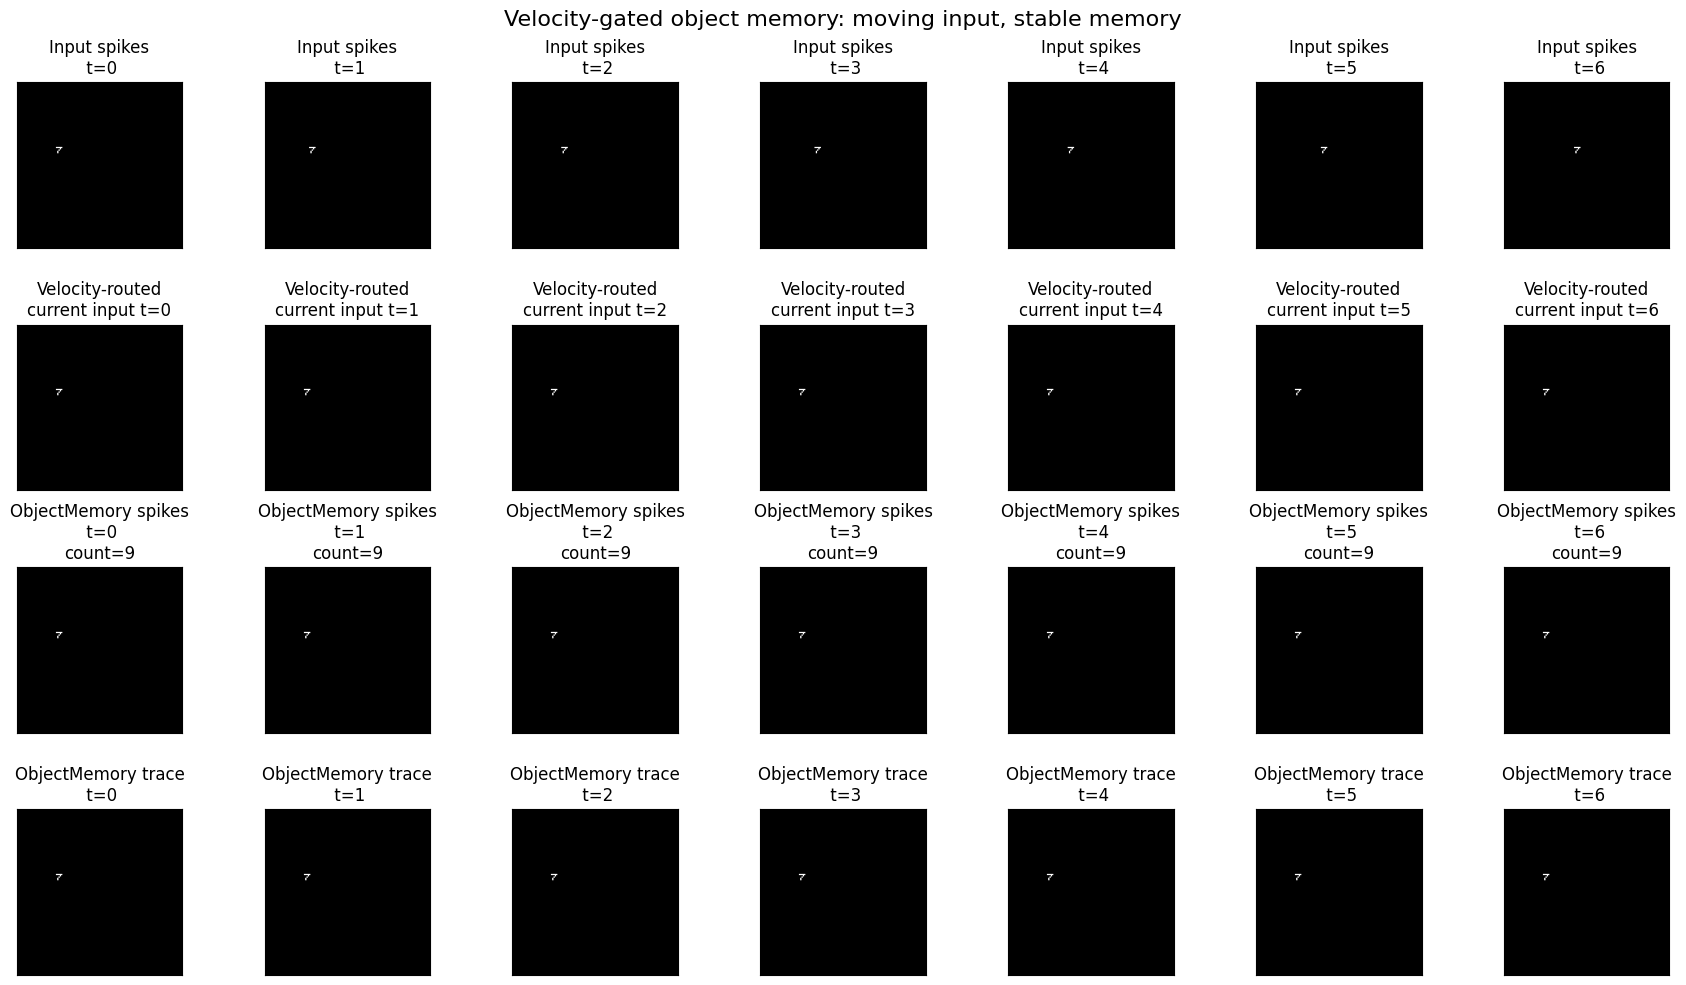

In [241]:
plot_object_memory_result(
    case=object_memory_case,
    object_memory_result=displacement_object_memory_result,
)

In [242]:
def test_displacement_object_memory_constant_velocities(
    velocities,
    shape_name="seven",
    start_top=50,
    start_left=30,
    max_velocity=6,
    max_displacement=36,
    velocity_params=None,
):
    if velocity_params is None:
        velocity_params = {}

    rows = []

    for true_dy, true_dx in velocities:
        case = make_unblurred_spike_case_from_velocity(
            velocity_y=true_dy,
            velocity_x=true_dx,
            shape_name=shape_name,
            start_top=start_top,
            start_left=start_left,
        )

        result = run_displacement_gated_object_memory(
            case=case,
            max_velocity=max_velocity,
            max_displacement=max_displacement,
            velocity_params=velocity_params,
            trace_weight=1.0,
            input_weight=1.0,
            threshold_memory=1.5,
            beta_memory=0.8,
            reset_mode="subtract",
        )

        memory_spike_counts = result["memory_spike_history"].sum(dim=(1, 2))
        routed_input_counts = result["routed_input_history"].sum(dim=(1, 2))

        final_memory_trace_count = int(result["memory_trace_history"][-1].sum().item())

        rows.append({
            "true_dy": true_dy,
            "true_dx": true_dx,
            "final_memory_trace_count": final_memory_trace_count,
            "min_routed_input_count_after_t0": int(routed_input_counts[1:].min().item()),
            "max_routed_input_count_after_t0": int(routed_input_counts[1:].max().item()),
            "min_memory_spike_count_after_t0": int(memory_spike_counts[1:].min().item()),
            "max_memory_spike_count_after_t0": int(memory_spike_counts[1:].max().item()),
            "num_steps": case["spikes"].shape[0],
        })

    return pd.DataFrame(rows)

In [243]:
constant_velocity_test = test_displacement_object_memory_constant_velocities(
    velocities=[
        (0, 1),
        (0, 2),
        (0, 4),
        (0, 6),
        (1, 0),
        (2, 0),
        (4, 0),
        (-1, 3),
        (3, -2),
        (-4, -4),
    ],
    shape_name="seven",
    velocity_params=GOOD_VELOCITY_PARAMS,
)

constant_velocity_test

,true_dy,true_dx,final_memory_trace_count,min_routed_input_count_after_t0,max_routed_input_count_after_t0,min_memory_spike_count_after_t0,max_memory_spike_count_after_t0,num_steps
0,0,1,9,9,9,9,9,7
1,0,2,9,9,9,9,9,7
2,0,4,9,9,9,9,9,7
3,0,6,9,9,9,9,9,7
4,1,0,9,9,9,9,9,7
5,2,0,9,9,9,9,9,7
6,4,0,9,9,9,9,9,7
7,-1,3,9,9,9,9,9,7
8,3,-2,9,9,9,9,9,7
9,-4,-4,9,9,9,9,9,7


In [244]:
var_test_case = make_unblurred_spike_case_from_velocity(
    velocity_y=-1,
    velocity_x=3,
    shape_name="seven",
    start_top=70,
    start_left=30,
)

var_test_result = run_displacement_gated_object_memory(
    case=var_test_case,
    max_velocity=6,
    max_displacement=36,
    velocity_params=GOOD_VELOCITY_PARAMS,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
)

var_test_result["table"]

,t,previous_t,current_t,num_active_velocity_gates,num_active_displacement_gates,note
0,0,NaN,0,0,1,initialize memory and zero displacement
1,1,0.0,1,1,1,displacement-gated memory update
2,2,1.0,2,1,1,displacement-gated memory update
3,3,2.0,3,1,1,displacement-gated memory update
4,4,3.0,4,1,1,displacement-gated memory update
5,5,4.0,5,1,1,displacement-gated memory update
6,6,5.0,6,1,1,displacement-gated memory update


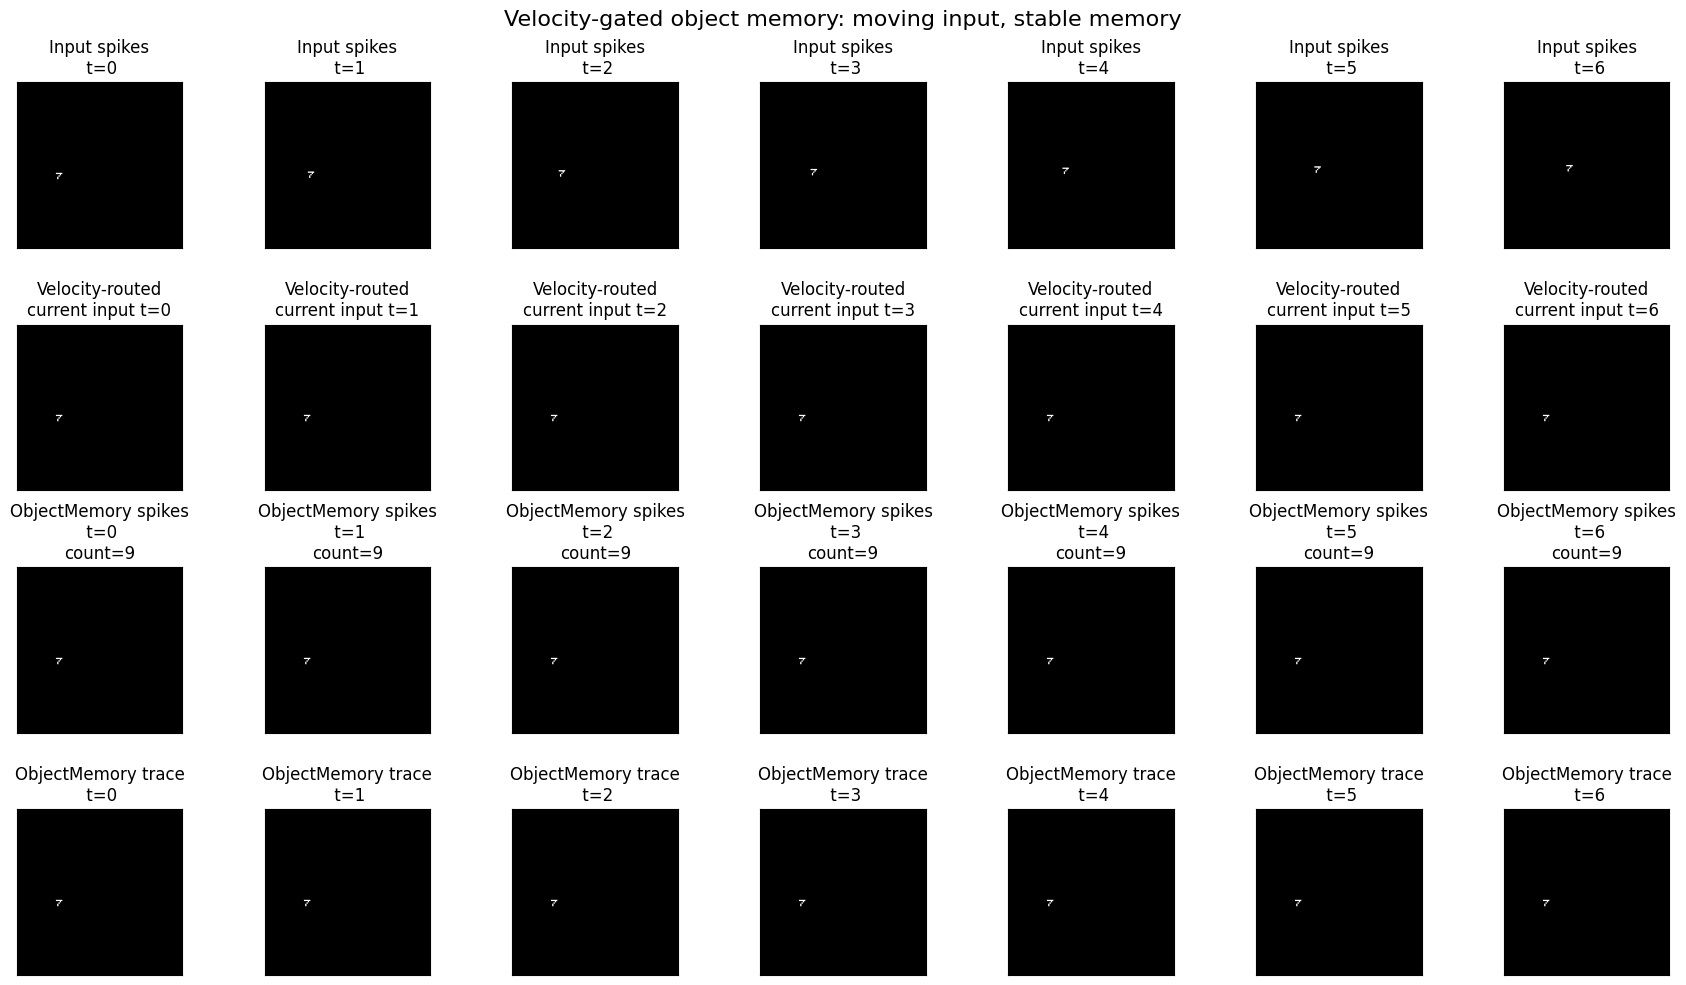

In [245]:
plot_object_memory_result(
    case=var_test_case,
    object_memory_result=var_test_result,
)

In [246]:
def make_variable_velocity_spike_case(
    velocity_sequence,
    shape_name="seven",
    start_top=50,
    start_left=30,
):
    """
    Make a moving shape where the velocity can change at each transition.

    velocity_sequence has length STEPS - 1.

    Example for 7 frames:
        velocity_sequence = [
            (0, 2),
            (0, 3),
            (0, 1),
            (0, 4),
            (0, 2),
            (0, 5),
        ]

    This means:
        frame 0 starts at start_top, start_left
        frame 1 moves by velocity_sequence[0]
        frame 2 moves by velocity_sequence[1]
        ...
    """

    shape = SHAPE_TEMPLATES[shape_name]

    frames = []
    origins = []

    current_top = start_top
    current_left = start_left

    for t in range(STEPS):
        frame = torch.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=torch.float32)

        shape_height, shape_width = shape.shape

        top = int(current_top)
        left = int(current_left)

        y0 = max(0, top)
        y1 = min(CANVAS_HEIGHT, top + shape_height)

        x0 = max(0, left)
        x1 = min(CANVAS_WIDTH, left + shape_width)

        shape_y0 = y0 - top
        shape_y1 = shape_y0 + (y1 - y0)

        shape_x0 = x0 - left
        shape_x1 = shape_x0 + (x1 - x0)

        if y0 < y1 and x0 < x1:
            frame[y0:y1, x0:x1] = shape[shape_y0:shape_y1, shape_x0:shape_x1] * INTENSITY

        frames.append(frame)
        origins.append((top, left))

        if t < len(velocity_sequence):
            dy, dx = velocity_sequence[t]
            current_top += dy
            current_left += dx

    frames = torch.stack(frames, dim=0)
    spikes = (frames > 0).float()

    return {
        "shape_name": shape_name,
        "velocity_sequence": velocity_sequence,
        "frames": frames,
        "spikes": spikes,
        "origins": origins,
    }

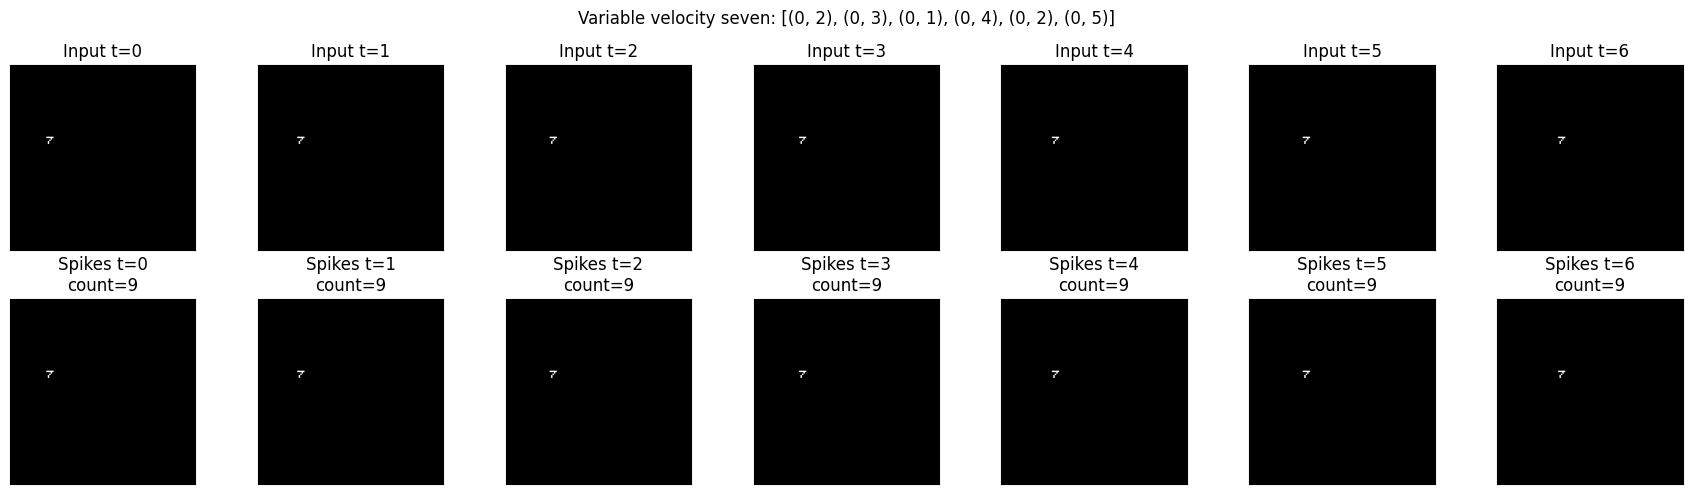

In [247]:
variable_velocity_sequence = [
    (0, 2),
    (0, 3),
    (0, 1),
    (0, 4),
    (0, 2),
    (0, 5),
]

variable_velocity_case = make_variable_velocity_spike_case(
    velocity_sequence=variable_velocity_sequence,
    shape_name="seven",
    start_top=50,
    start_left=25,
)

plot_input_next_to_spikes_general(
    variable_velocity_case,
    title=f"Variable velocity seven: {variable_velocity_sequence}",
)

In [248]:
variable_velocity_result = run_displacement_gated_object_memory(
    case=variable_velocity_case,
    max_velocity=6,
    max_displacement=36,
    velocity_params=GOOD_VELOCITY_PARAMS,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
)

variable_velocity_result["table"]

,t,previous_t,current_t,num_active_velocity_gates,num_active_displacement_gates,note
0,0,NaN,0,0,1,initialize memory and zero displacement
1,1,0.0,1,1,1,displacement-gated memory update
2,2,1.0,2,1,1,displacement-gated memory update
3,3,2.0,3,1,1,displacement-gated memory update
4,4,3.0,4,1,1,displacement-gated memory update
5,5,4.0,5,1,1,displacement-gated memory update
6,6,5.0,6,1,1,displacement-gated memory update


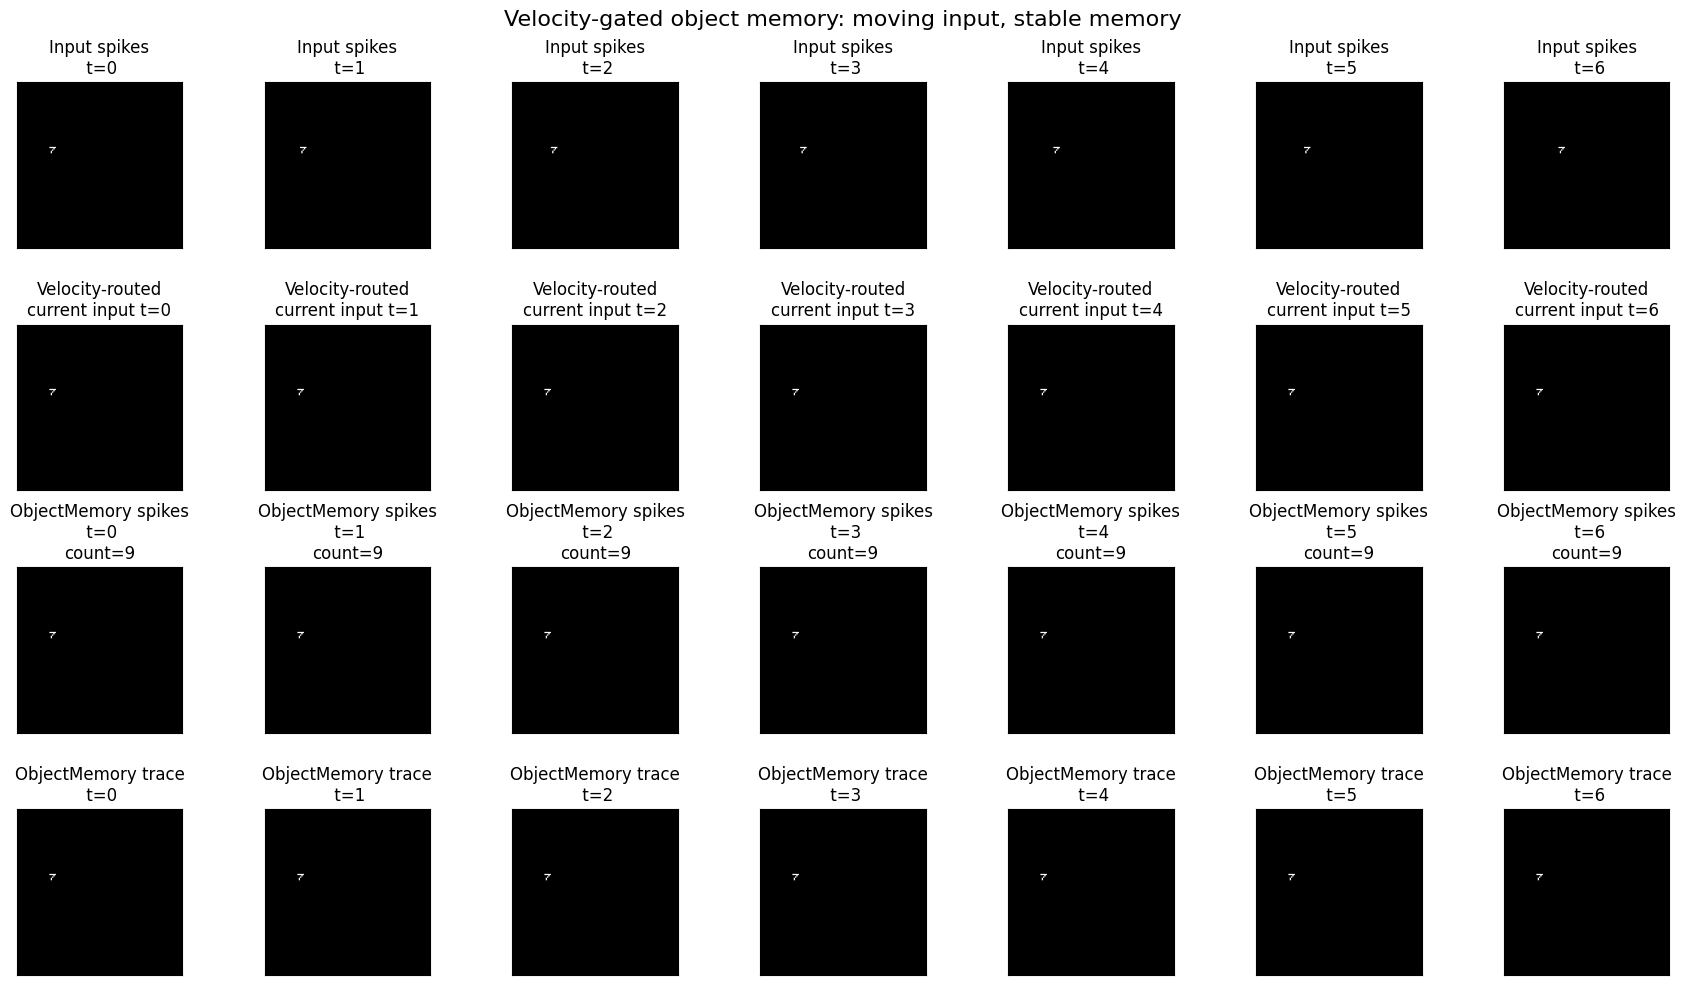

In [249]:
plot_object_memory_result(
    case=variable_velocity_case,
    object_memory_result=variable_velocity_result,
)

In [250]:
def summarize_displacement_gate_history(
    displacement_gate_history,
    max_displacement=36,
):
    rows = []

    for t in range(displacement_gate_history.shape[0]):
        active_positions = torch.nonzero(
            displacement_gate_history[t] > 0,
            as_tuple=False,
        )

        for pos in active_positions:
            i = int(pos[0].item())
            j = int(pos[1].item())

            D_y = i - max_displacement
            D_x = j - max_displacement

            rows.append({
                "t": t,
                "D_y": D_y,
                "D_x": D_x,
            })

    return pd.DataFrame(rows)

In [251]:
displacement_summary = summarize_displacement_gate_history(
    displacement_gate_history=variable_velocity_result["displacement_gate_history"],
    max_displacement=36,
)

displacement_summary

,t,D_y,D_x
0,0,0,0
1,1,0,2
2,2,0,5
3,3,0,6
4,4,0,10
5,5,0,12
6,6,0,17


In [252]:
def expected_displacements_from_velocity_sequence(velocity_sequence):
    rows = []

    D_y = 0
    D_x = 0

    rows.append({
        "t": 0,
        "expected_D_y": D_y,
        "expected_D_x": D_x,
    })

    for t, (dy, dx) in enumerate(velocity_sequence, start=1):
        D_y += dy
        D_x += dx

        rows.append({
            "t": t,
            "expected_D_y": D_y,
            "expected_D_x": D_x,
        })

    return pd.DataFrame(rows)

In [253]:
expected_displacement = expected_displacements_from_velocity_sequence(
    variable_velocity_sequence
)

actual_displacement = displacement_summary.rename(
    columns={
        "D_y": "actual_D_y",
        "D_x": "actual_D_x",
    }
)

expected_vs_actual_displacement = expected_displacement.merge(
    actual_displacement,
    on="t",
    how="left",
)

expected_vs_actual_displacement["correct"] = (
    (expected_vs_actual_displacement["expected_D_y"] == expected_vs_actual_displacement["actual_D_y"])
    & (expected_vs_actual_displacement["expected_D_x"] == expected_vs_actual_displacement["actual_D_x"])
)

expected_vs_actual_displacement

,t,expected_D_y,expected_D_x,actual_D_y,actual_D_x,correct
0,0,0,0,0,0,True
1,1,0,2,0,2,True
2,2,0,5,0,5,True
3,3,0,6,0,6,True
4,4,0,10,0,10,True
5,5,0,12,0,12,True
6,6,0,17,0,17,True


In [254]:
def get_activity_crop_from_tensors(tensor_list, padding=8):
    """
    Compute one crop box that contains activity from a list of tensors.

    Each tensor can be:
        [T, H, W] or [H, W]
    """

    activity = None

    for tensor in tensor_list:
        if tensor.dim() == 3:
            current_activity = tensor.sum(dim=0) > 0
        elif tensor.dim() == 2:
            current_activity = tensor > 0
        else:
            raise ValueError("Expected tensor with shape [T,H,W] or [H,W].")

        if activity is None:
            activity = current_activity.clone()
        else:
            activity = activity | current_activity

    active_positions = torch.nonzero(activity > 0, as_tuple=False)

    if active_positions.numel() == 0:
        return None

    height, width = activity.shape

    y_min = max(0, int(active_positions[:, 0].min().item()) - padding)
    y_max = min(height, int(active_positions[:, 0].max().item()) + padding + 1)

    x_min = max(0, int(active_positions[:, 1].min().item()) - padding)
    x_max = min(width, int(active_positions[:, 1].max().item()) + padding + 1)

    return y_min, y_max, x_min, x_max

In [255]:
def plot_object_memory_result_zoomed(
    case,
    object_memory_result,
    padding=8,
):
    input_spikes = case["spikes"]
    memory_spike_history = object_memory_result["memory_spike_history"]
    memory_trace_history = object_memory_result["memory_trace_history"]
    routed_input_history = object_memory_result["routed_input_history"]

    crop = get_activity_crop_from_tensors(
        [
            input_spikes,
            memory_spike_history,
            memory_trace_history,
            routed_input_history,
        ],
        padding=padding,
    )

    if crop is None:
        print("No activity found to plot.")
        return

    y_min, y_max, x_min, x_max = crop

    num_steps = input_spikes.shape[0]

    fig, axes = plt.subplots(4, num_steps, figsize=(2.5 * num_steps, 10))

    for t in range(num_steps):
        axes[0, t].imshow(
            input_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[0, t].set_title(f"Input\n t={t}")

        axes[1, t].imshow(
            routed_input_history[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[1, t].set_title(f"Routed input\n t={t}")

        axes[2, t].imshow(
            memory_spike_history[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[2, t].set_title(
            f"Memory spikes\n t={t}\ncount={int(memory_spike_history[t].sum().item())}"
        )

        axes[3, t].imshow(
            memory_trace_history[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[3, t].set_title(f"Memory trace\n t={t}")

        for row in range(4):
            axes[row, t].set_xticks([])
            axes[row, t].set_yticks([])

    plt.suptitle(
        f"Zoomed velocity/displacement-gated object memory\ncrop y={y_min}:{y_max}, x={x_min}:{x_max}",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

In [259]:
def get_activity_crop_from_tensors(
    tensor_list,
    padding=12,
    min_height=55,
    min_width=55,
):
    """
    Compute one crop box that contains activity from a list of tensors,
    but force the crop to have a minimum height/width so motion is visible.
    """

    activity = None

    for tensor in tensor_list:
        if tensor.dim() == 3:
            current_activity = tensor.sum(dim=0) > 0
        elif tensor.dim() == 2:
            current_activity = tensor > 0
        else:
            raise ValueError("Expected tensor with shape [T,H,W] or [H,W].")

        if activity is None:
            activity = current_activity.clone()
        else:
            activity = activity | current_activity

    active_positions = torch.nonzero(activity > 0, as_tuple=False)

    if active_positions.numel() == 0:
        return None

    height, width = activity.shape

    y_min = max(0, int(active_positions[:, 0].min().item()) - padding)
    y_max = min(height, int(active_positions[:, 0].max().item()) + padding + 1)

    x_min = max(0, int(active_positions[:, 1].min().item()) - padding)
    x_max = min(width, int(active_positions[:, 1].max().item()) + padding + 1)

    crop_height = y_max - y_min
    crop_width = x_max - x_min

    if crop_height < min_height:
        extra = min_height - crop_height
        y_min = max(0, y_min - extra // 2)
        y_max = min(height, y_max + extra - extra // 2)

    if crop_width < min_width:
        extra = min_width - crop_width
        x_min = max(0, x_min - extra // 2)
        x_max = min(width, x_max + extra - extra // 2)

    return y_min, y_max, x_min, x_max

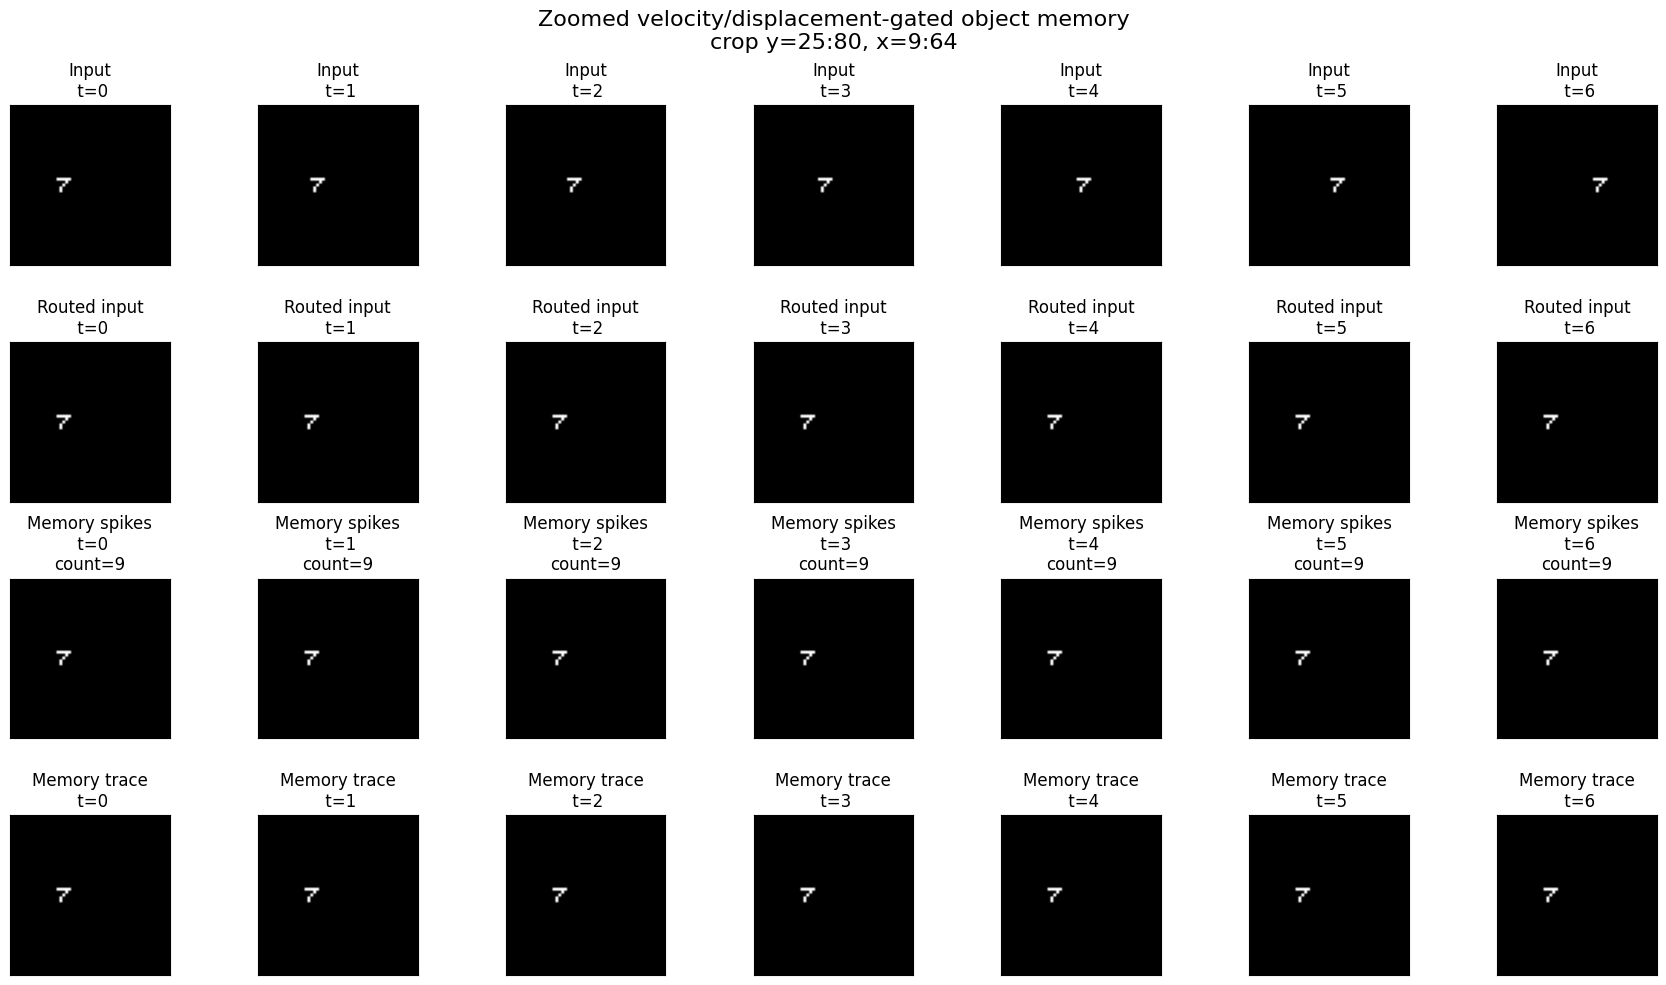

In [260]:
plot_object_memory_result_zoomed(
    case=variable_velocity_case,
    object_memory_result=variable_velocity_result,
    padding=10,
)

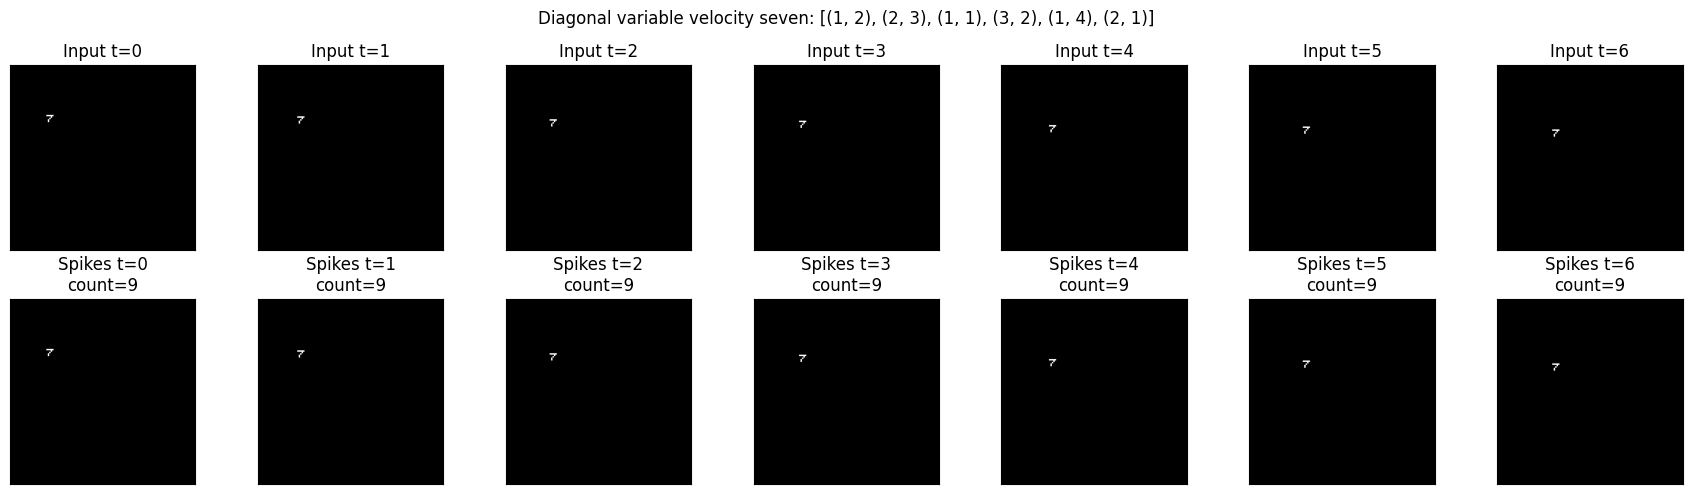

In [261]:
diagonal_variable_velocity_sequence = [
    (1, 2),
    (2, 3),
    (1, 1),
    (3, 2),
    (1, 4),
    (2, 1),
]

diagonal_variable_velocity_case = make_variable_velocity_spike_case(
    velocity_sequence=diagonal_variable_velocity_sequence,
    shape_name="seven",
    start_top=35,
    start_left=25,
)

plot_input_next_to_spikes_general(
    diagonal_variable_velocity_case,
    title=f"Diagonal variable velocity seven: {diagonal_variable_velocity_sequence}",
)

In [262]:
diagonal_variable_velocity_result = run_displacement_gated_object_memory(
    case=diagonal_variable_velocity_case,
    max_velocity=6,
    max_displacement=36,
    velocity_params=GOOD_VELOCITY_PARAMS,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
)

diagonal_variable_velocity_result["table"]

,t,previous_t,current_t,num_active_velocity_gates,num_active_displacement_gates,note
0,0,NaN,0,0,1,initialize memory and zero displacement
1,1,0.0,1,1,1,displacement-gated memory update
2,2,1.0,2,1,1,displacement-gated memory update
3,3,2.0,3,1,1,displacement-gated memory update
4,4,3.0,4,1,1,displacement-gated memory update
5,5,4.0,5,1,1,displacement-gated memory update
6,6,5.0,6,1,1,displacement-gated memory update


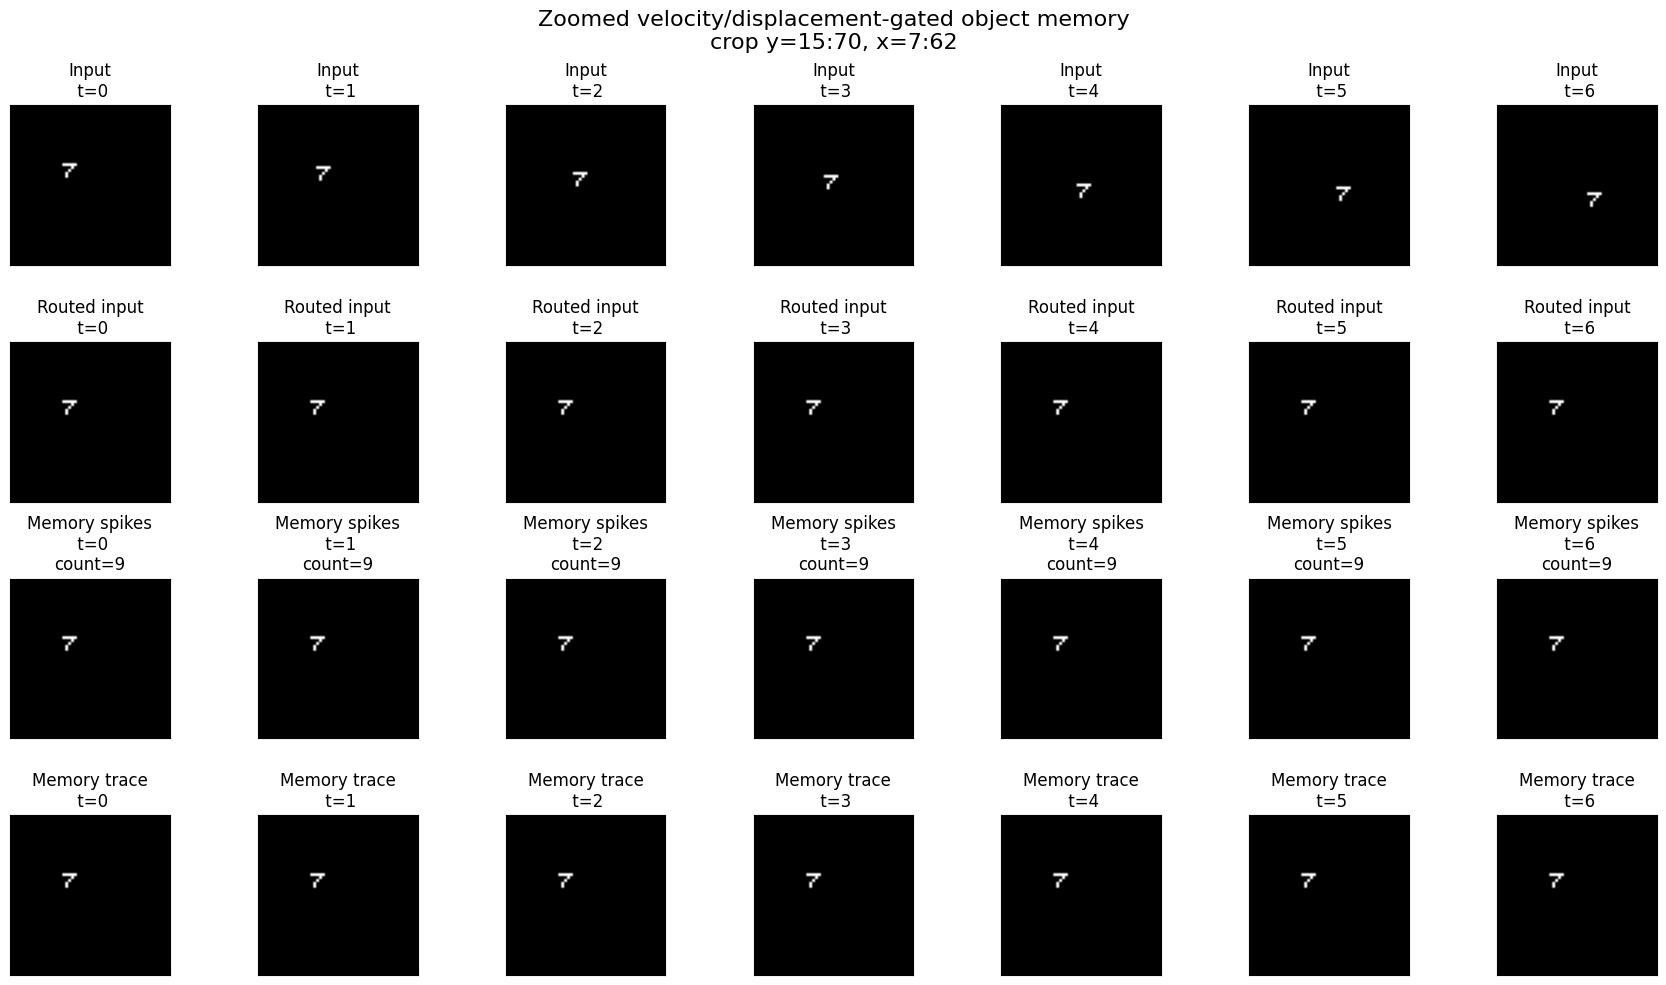

In [263]:
plot_object_memory_result_zoomed(
    case=diagonal_variable_velocity_case,
    object_memory_result=diagonal_variable_velocity_result,
    padding=12,
)

In [268]:
direction_changing_velocity_sequence = [
    (1, 3),    # down-right
    (2, 2),    # down-right
    (-5, -5),   # up-right
    (3, -2),   # down-left
    (6, 6),  # up-left
    (-3, -4),    # down-right again
]

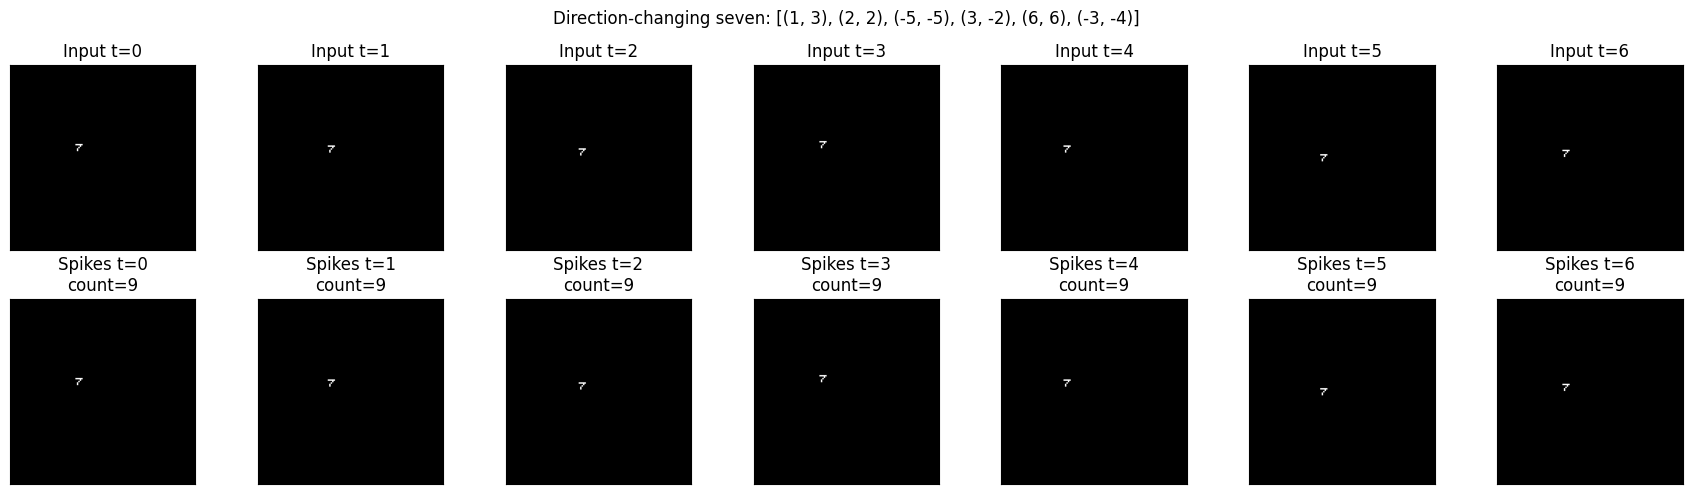

In [269]:
direction_changing_case = make_variable_velocity_spike_case(
    velocity_sequence=direction_changing_velocity_sequence,
    shape_name="seven",
    start_top=55,
    start_left=45,
)

plot_input_next_to_spikes_general(
    direction_changing_case,
    title=f"Direction-changing seven: {direction_changing_velocity_sequence}",
)

In [270]:
direction_changing_result = run_displacement_gated_object_memory(
    case=direction_changing_case,
    max_velocity=6,
    max_displacement=36,
    velocity_params=GOOD_VELOCITY_PARAMS,
    trace_weight=1.0,
    input_weight=1.0,
    threshold_memory=1.5,
    beta_memory=0.8,
    reset_mode="subtract",
)

direction_changing_result["table"]

,t,previous_t,current_t,num_active_velocity_gates,num_active_displacement_gates,note
0,0,NaN,0,0,1,initialize memory and zero displacement
1,1,0.0,1,1,1,displacement-gated memory update
2,2,1.0,2,1,1,displacement-gated memory update
3,3,2.0,3,1,1,displacement-gated memory update
4,4,3.0,4,1,1,displacement-gated memory update
5,5,4.0,5,1,1,displacement-gated memory update
6,6,5.0,6,1,1,displacement-gated memory update


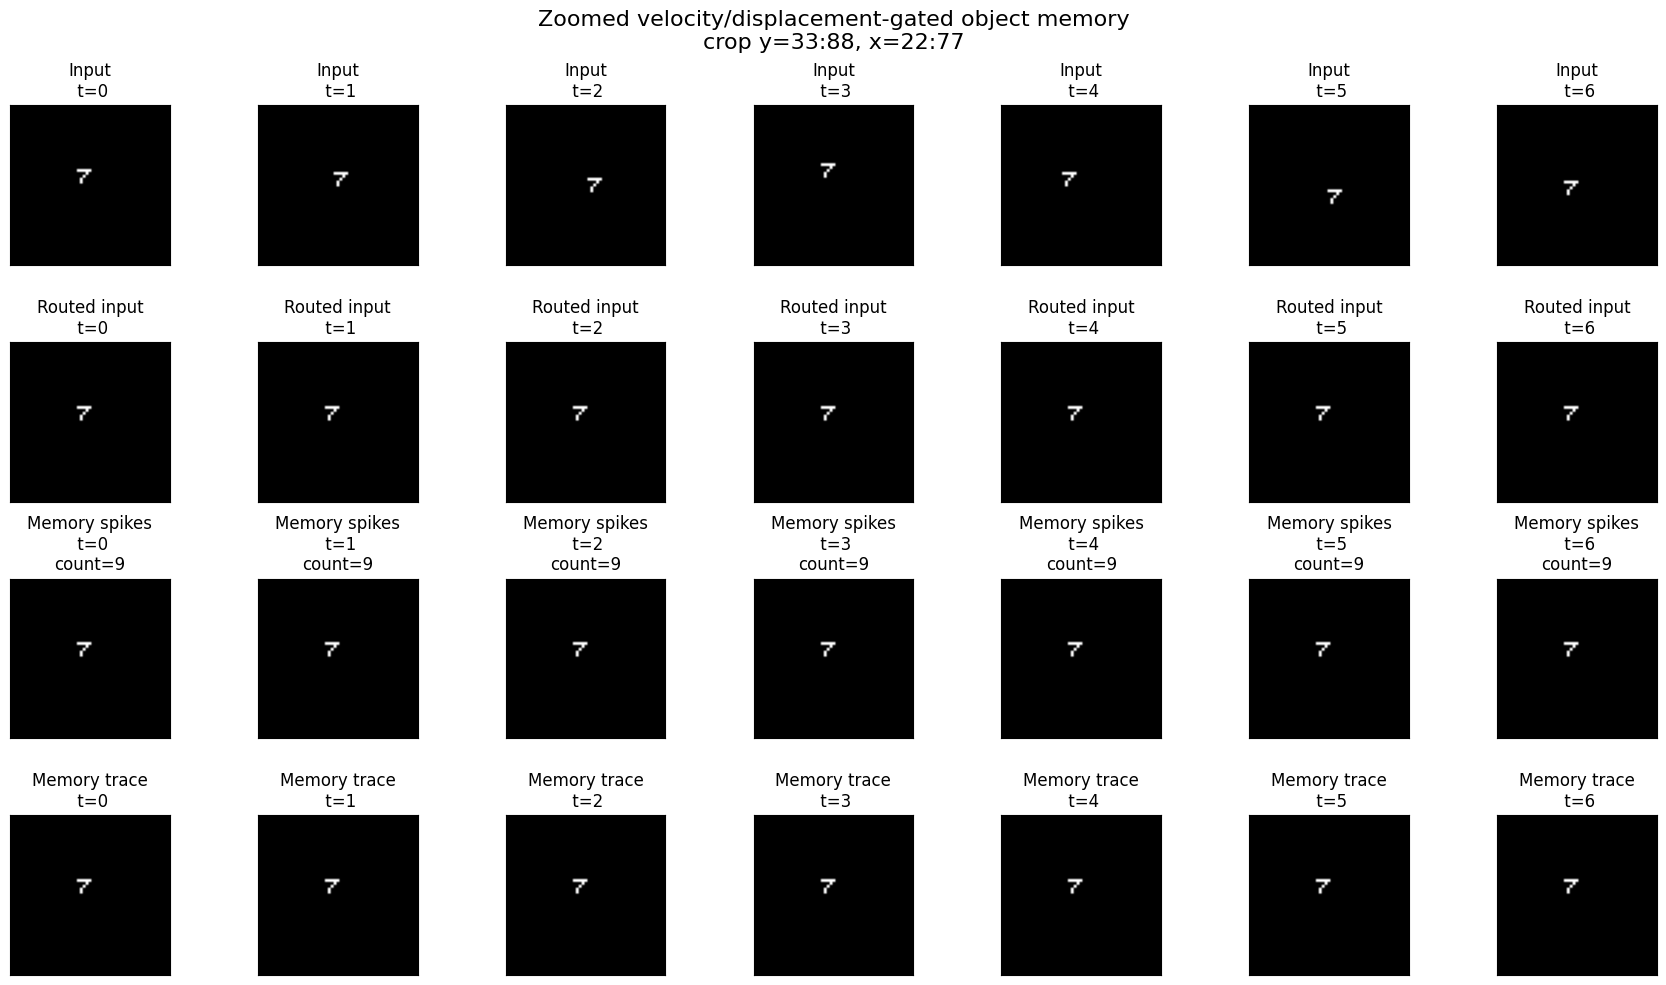

In [271]:
plot_object_memory_result_zoomed(
    case=direction_changing_case,
    object_memory_result=direction_changing_result,
    padding=12,
)

In [272]:
direction_changing_displacement_summary = summarize_displacement_gate_history(
    displacement_gate_history=direction_changing_result["displacement_gate_history"],
    max_displacement=36,
)

direction_changing_expected_displacement = expected_displacements_from_velocity_sequence(
    direction_changing_velocity_sequence
)

direction_changing_actual_displacement = direction_changing_displacement_summary.rename(
    columns={
        "D_y": "actual_D_y",
        "D_x": "actual_D_x",
    }
)

direction_changing_expected_vs_actual = direction_changing_expected_displacement.merge(
    direction_changing_actual_displacement,
    on="t",
    how="left",
)

direction_changing_expected_vs_actual["correct"] = (
    (direction_changing_expected_vs_actual["expected_D_y"] == direction_changing_expected_vs_actual["actual_D_y"])
    & (direction_changing_expected_vs_actual["expected_D_x"] == direction_changing_expected_vs_actual["actual_D_x"])
)

direction_changing_expected_vs_actual

,t,expected_D_y,expected_D_x,actual_D_y,actual_D_x,correct
0,0,0,0,0,0,True
1,1,1,3,1,3,True
2,2,3,5,3,5,True
3,3,-2,0,-2,0,True
4,4,1,-2,1,-2,True
5,5,7,4,7,4,True
6,6,4,0,4,0,True


## Spiking feature maps from ObjectMemory

In [273]:
def compute_lif_local_feature_map_over_time(
    input_spike_history,
    kernel,
    threshold=None,
    beta=0.8,
    reset_mode="subtract",
):
    """
    Compute a spiking local feature map over time.

    input_spike_history:
        [T, H, W]

    kernel:
        small binary receptive field, e.g.
            horizontal: [[1, 1, 1]]
            vertical:   [[1], [1], [1]]

    Output:
        feature_spike_history[t, y, x]
            feature neuron at (y,x) spikes at time t
    """

    input_spike_history = (input_spike_history > 0).float()

    kernel = torch.tensor(kernel, dtype=torch.float32)
    kernel_height, kernel_width = kernel.shape

    num_steps, height, width = input_spike_history.shape

    if threshold is None:
        threshold = float(kernel.sum().item()) - 0.5

    feature_membrane = torch.zeros((height, width), dtype=torch.float32)

    feature_spike_history = []
    feature_membrane_history = []

    for t in range(num_steps):
        current_feature_input = torch.zeros((height, width), dtype=torch.float32)

        for y in range(height - kernel_height + 1):
            for x in range(width - kernel_width + 1):
                patch = input_spike_history[
                    t,
                    y:y + kernel_height,
                    x:x + kernel_width,
                ]

                feature_current = (patch * kernel).sum()

                center_y = y + kernel_height // 2
                center_x = x + kernel_width // 2

                current_feature_input[center_y, center_x] = feature_current

        feature_spikes, feature_membrane = lif_step(
            input_current=current_feature_input,
            membrane=feature_membrane,
            beta=beta,
            threshold=threshold,
            reset_mode=reset_mode,
        )

        feature_spike_history.append(feature_spikes.clone())
        feature_membrane_history.append(feature_membrane.clone())

    return {
        "feature_spike_history": torch.stack(feature_spike_history, dim=0),
        "feature_membrane_history": torch.stack(feature_membrane_history, dim=0),
    }

In [274]:
def compute_basic_spiking_shape_features(
    object_memory_spike_history,
    beta=0.8,
):
    """
    Compute basic reusable spiking feature maps from ObjectMemory spikes.
    """

    horizontal_result = compute_lif_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[[1, 1, 1]],
        threshold=2.5,
        beta=beta,
        reset_mode="subtract",
    )

    vertical_result = compute_lif_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1],
            [1],
            [1],
        ],
        threshold=2.5,
        beta=beta,
        reset_mode="subtract",
    )

    corner_1_result = compute_lif_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [0, 1],
        ],
        threshold=2.5,
        beta=beta,
        reset_mode="subtract",
    )

    corner_2_result = compute_lif_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [1, 0],
        ],
        threshold=2.5,
        beta=beta,
        reset_mode="subtract",
    )

    corner_3_result = compute_lif_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 0],
            [1, 1],
        ],
        threshold=2.5,
        beta=beta,
        reset_mode="subtract",
    )

    corner_4_result = compute_lif_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [0, 1],
            [1, 1],
        ],
        threshold=2.5,
        beta=beta,
        reset_mode="subtract",
    )

    corner_spike_history = torch.clamp(
        corner_1_result["feature_spike_history"]
        + corner_2_result["feature_spike_history"]
        + corner_3_result["feature_spike_history"]
        + corner_4_result["feature_spike_history"],
        min=0,
        max=1,
    )

    return {
        "horizontal": horizontal_result,
        "vertical": vertical_result,
        "corner_1": corner_1_result,
        "corner_2": corner_2_result,
        "corner_3": corner_3_result,
        "corner_4": corner_4_result,
        "corner_spike_history": corner_spike_history,
    }

In [275]:
features_result = compute_basic_spiking_shape_features(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
    beta=0.8,
)

In [276]:
pd.DataFrame({
    "t": list(range(direction_changing_result["memory_spike_history"].shape[0])),
    "object_memory_spike_count": [
        int(direction_changing_result["memory_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "horizontal_feature_spike_count": [
        int(features_result["horizontal"]["feature_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "vertical_feature_spike_count": [
        int(features_result["vertical"]["feature_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "corner_feature_spike_count": [
        int(features_result["corner_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
})

,t,object_memory_spike_count,horizontal_feature_spike_count,vertical_feature_spike_count,corner_feature_spike_count
0,0,9,3,0,2
1,1,9,5,5,12
2,2,9,5,5,12
3,3,9,17,17,22
4,4,9,5,5,12
5,5,9,5,5,12
6,6,9,17,17,22


In [277]:
def plot_spiking_feature_maps(
    object_memory_spike_history,
    features_result,
    padding=8,
):
    """
    Plot ObjectMemory spikes next to basic feature maps over time.

    Rows:
        1. ObjectMemory spikes
        2. Horizontal feature spikes
        3. Vertical feature spikes
        4. Corner feature spikes
    """

    horizontal_spikes = features_result["horizontal"]["feature_spike_history"]
    vertical_spikes = features_result["vertical"]["feature_spike_history"]
    corner_spikes = features_result["corner_spike_history"]

    crop = get_activity_crop_from_tensors(
        [
            object_memory_spike_history,
            horizontal_spikes,
            vertical_spikes,
            corner_spikes,
        ],
        padding=padding,
        min_height=55,
        min_width=55,
    )

    if crop is None:
        print("No activity found to plot.")
        return

    y_min, y_max, x_min, x_max = crop

    num_steps = object_memory_spike_history.shape[0]

    fig, axes = plt.subplots(4, num_steps, figsize=(2.5 * num_steps, 10))

    for t in range(num_steps):
        axes[0, t].imshow(
            object_memory_spike_history[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[0, t].set_title(
            f"ObjectMemory\n t={t}\ncount={int(object_memory_spike_history[t].sum().item())}"
        )

        axes[1, t].imshow(
            horizontal_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[1, t].set_title(
            f"Horizontal\n t={t}\ncount={int(horizontal_spikes[t].sum().item())}"
        )

        axes[2, t].imshow(
            vertical_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[2, t].set_title(
            f"Vertical\n t={t}\ncount={int(vertical_spikes[t].sum().item())}"
        )

        axes[3, t].imshow(
            corner_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[3, t].set_title(
            f"Corner\n t={t}\ncount={int(corner_spikes[t].sum().item())}"
        )

        for row in range(4):
            axes[row, t].set_xticks([])
            axes[row, t].set_yticks([])

    plt.suptitle(
        "Spiking feature maps from stabilized ObjectMemory",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

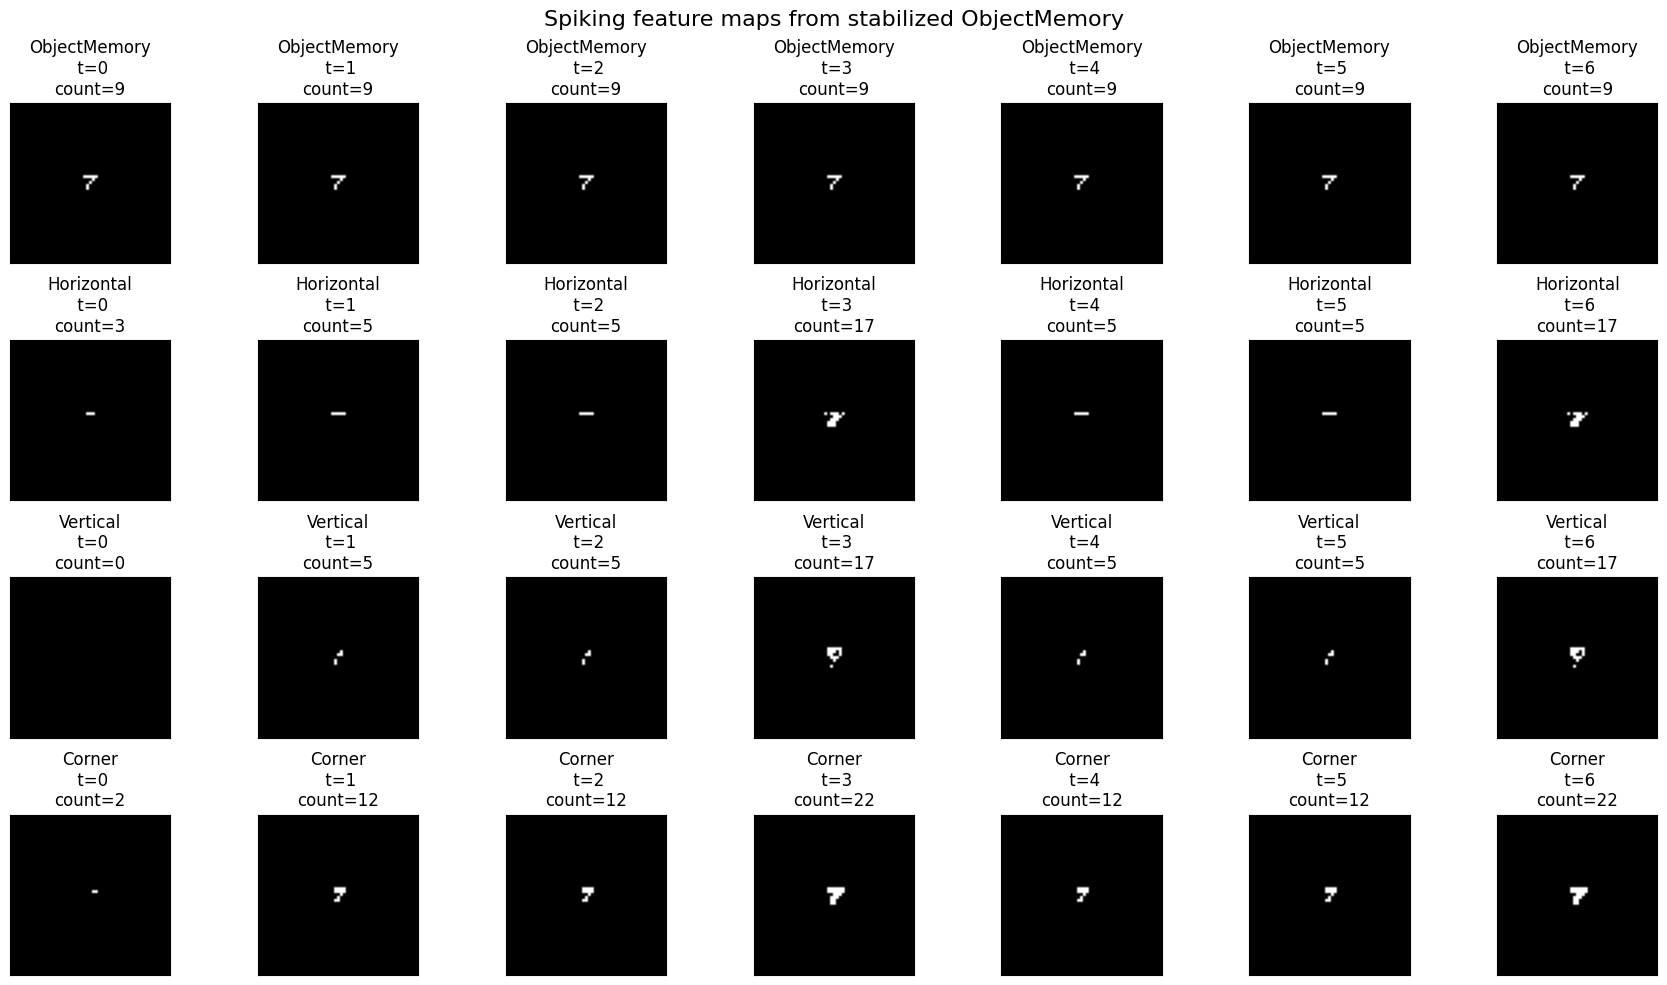

In [278]:
plot_spiking_feature_maps(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
    features_result=features_result,
    padding=10,
)

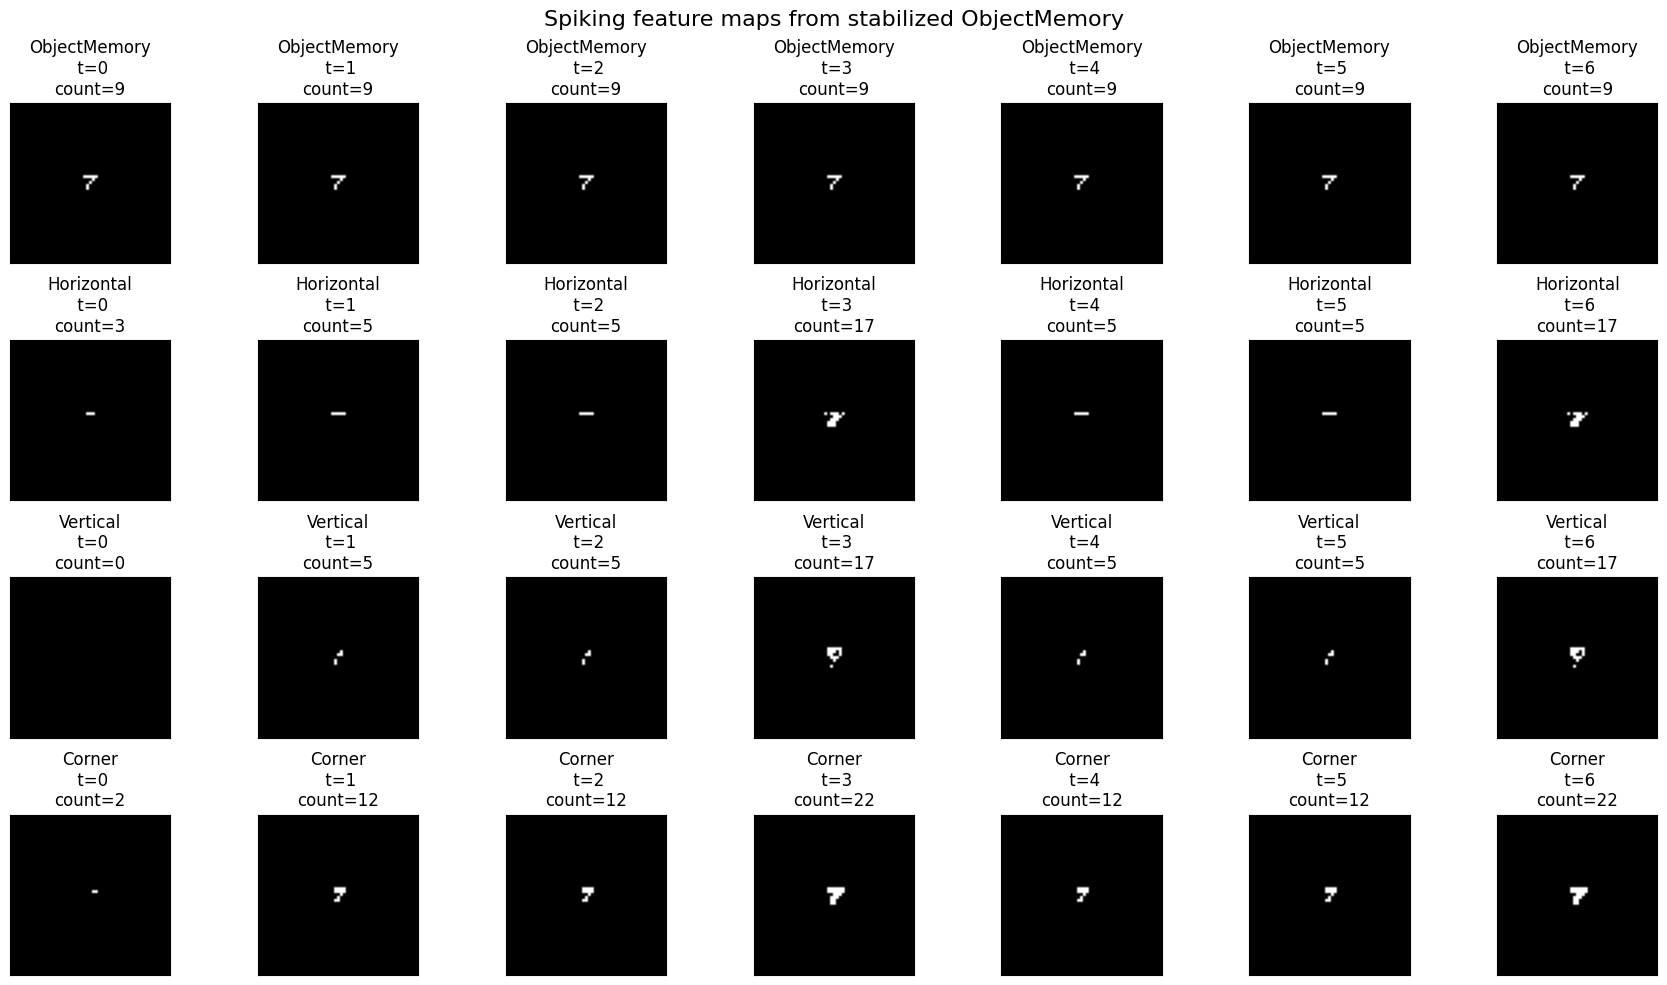

In [280]:
diagonal_features_result = compute_basic_spiking_shape_features(
    object_memory_spike_history=diagonal_variable_velocity_result["memory_spike_history"],
    beta=0.8,
)

plot_spiking_feature_maps(
    object_memory_spike_history=diagonal_variable_velocity_result["memory_spike_history"],
    features_result=diagonal_features_result,
    padding=10,
)

Need stricter feature detection

In [281]:
def compute_strict_local_feature_map_over_time(
    input_spike_history,
    kernel,
    threshold=None,
):
    """
    Strict instantaneous local feature detector.

    This detects spatial patterns at each time step.
    It does NOT accumulate partial feature evidence over time.

    input_spike_history:
        [T, H, W]

    kernel:
        small binary receptive field

    Output:
        feature_spike_history[t, y, x]
    """

    input_spike_history = (input_spike_history > 0).float()

    kernel = torch.tensor(kernel, dtype=torch.float32)
    kernel_height, kernel_width = kernel.shape

    num_steps, height, width = input_spike_history.shape

    if threshold is None:
        threshold = float(kernel.sum().item()) - 0.5

    feature_spike_history = []

    for t in range(num_steps):
        feature_spikes = torch.zeros((height, width), dtype=torch.float32)

        for y in range(height - kernel_height + 1):
            for x in range(width - kernel_width + 1):
                patch = input_spike_history[
                    t,
                    y:y + kernel_height,
                    x:x + kernel_width,
                ]

                feature_current = (patch * kernel).sum()

                center_y = y + kernel_height // 2
                center_x = x + kernel_width // 2

                if feature_current >= threshold:
                    feature_spikes[center_y, center_x] = 1.0

        feature_spike_history.append(feature_spikes.clone())

    return {
        "feature_spike_history": torch.stack(feature_spike_history, dim=0),
    }

In [282]:
def compute_strict_basic_shape_features(
    object_memory_spike_history,
):
    """
    Strict reusable spatial feature maps from ObjectMemory spikes.
    No temporal accumulation yet.
    """

    horizontal_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[[1, 1, 1]],
        threshold=2.5,
    )

    vertical_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1],
            [1],
            [1],
        ],
        threshold=2.5,
    )

    corner_1_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [0, 1],
        ],
        threshold=2.5,
    )

    corner_2_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [1, 0],
        ],
        threshold=2.5,
    )

    corner_3_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 0],
            [1, 1],
        ],
        threshold=2.5,
    )

    corner_4_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [0, 1],
            [1, 1],
        ],
        threshold=2.5,
    )

    corner_spike_history = torch.clamp(
        corner_1_result["feature_spike_history"]
        + corner_2_result["feature_spike_history"]
        + corner_3_result["feature_spike_history"]
        + corner_4_result["feature_spike_history"],
        min=0,
        max=1,
    )

    return {
        "horizontal": horizontal_result,
        "vertical": vertical_result,
        "corner_1": corner_1_result,
        "corner_2": corner_2_result,
        "corner_3": corner_3_result,
        "corner_4": corner_4_result,
        "corner_spike_history": corner_spike_history,
    }

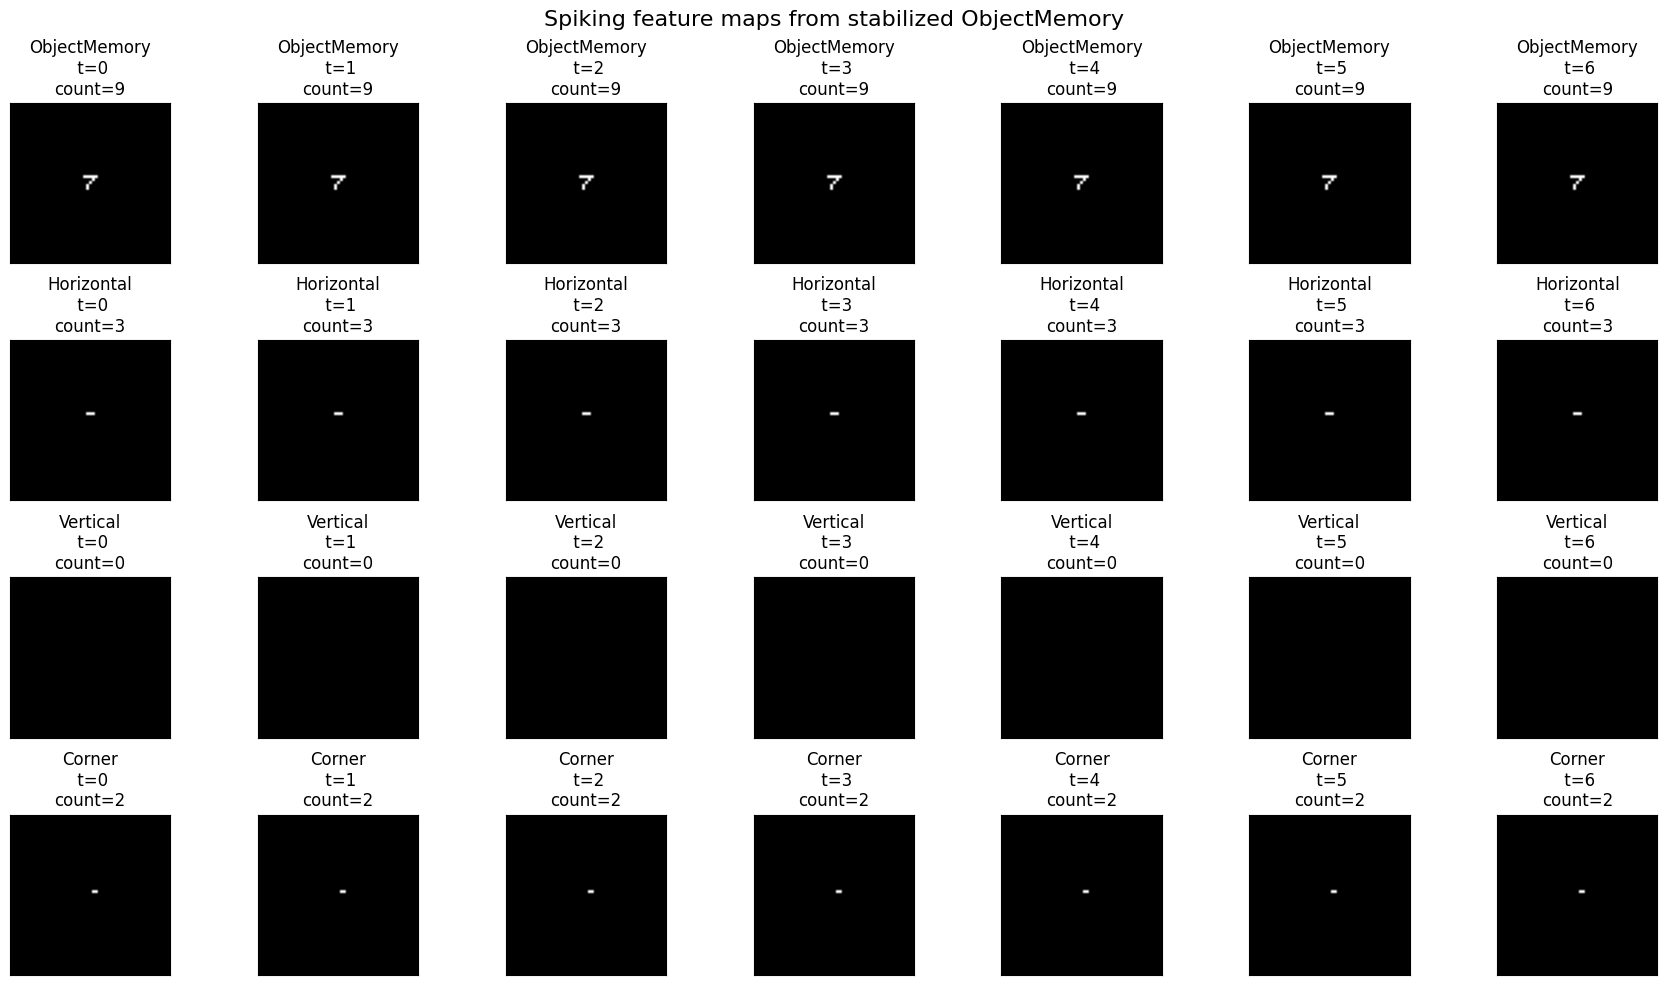

In [283]:
strict_features_result = compute_strict_basic_shape_features(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
)

plot_spiking_feature_maps(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
    features_result=strict_features_result,
    padding=10,
)

In [284]:
def compute_strict_basic_shape_features_with_diagonals(
    object_memory_spike_history,
):
    """
    Strict reusable spatial feature maps from ObjectMemory spikes.

    Features:
        horizontal
        vertical
        corner
        diagonal_down_right
        diagonal_down_left

    No temporal accumulation here.
    """

    horizontal_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[[1, 1, 1]],
        threshold=2.5,
    )

    vertical_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1],
            [1],
            [1],
        ],
        threshold=2.5,
    )

    diagonal_down_right_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 0, 0],
            [0, 1, 0],
            [0, 0, 1],
        ],
        threshold=2.5,
    )

    diagonal_down_left_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [0, 0, 1],
            [0, 1, 0],
            [1, 0, 0],
        ],
        threshold=2.5,
    )

    corner_1_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [0, 1],
        ],
        threshold=2.5,
    )

    corner_2_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [1, 0],
        ],
        threshold=2.5,
    )

    corner_3_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 0],
            [1, 1],
        ],
        threshold=2.5,
    )

    corner_4_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [0, 1],
            [1, 1],
        ],
        threshold=2.5,
    )

    corner_spike_history = torch.clamp(
        corner_1_result["feature_spike_history"]
        + corner_2_result["feature_spike_history"]
        + corner_3_result["feature_spike_history"]
        + corner_4_result["feature_spike_history"],
        min=0,
        max=1,
    )

    return {
        "horizontal": horizontal_result,
        "vertical": vertical_result,
        "diagonal_down_right": diagonal_down_right_result,
        "diagonal_down_left": diagonal_down_left_result,
        "corner_1": corner_1_result,
        "corner_2": corner_2_result,
        "corner_3": corner_3_result,
        "corner_4": corner_4_result,
        "corner_spike_history": corner_spike_history,
    }

In [285]:
def plot_spiking_feature_maps_with_diagonals(
    object_memory_spike_history,
    features_result,
    padding=8,
):
    """
    Plot ObjectMemory spikes next to basic feature maps over time.

    Rows:
        1. ObjectMemory spikes
        2. Horizontal feature spikes
        3. Vertical feature spikes
        4. Diagonal down-right feature spikes
        5. Diagonal down-left feature spikes
        6. Corner feature spikes
    """

    horizontal_spikes = features_result["horizontal"]["feature_spike_history"]
    vertical_spikes = features_result["vertical"]["feature_spike_history"]
    diagonal_down_right_spikes = features_result["diagonal_down_right"]["feature_spike_history"]
    diagonal_down_left_spikes = features_result["diagonal_down_left"]["feature_spike_history"]
    corner_spikes = features_result["corner_spike_history"]

    crop = get_activity_crop_from_tensors(
        [
            object_memory_spike_history,
            horizontal_spikes,
            vertical_spikes,
            diagonal_down_right_spikes,
            diagonal_down_left_spikes,
            corner_spikes,
        ],
        padding=padding,
        min_height=55,
        min_width=55,
    )

    if crop is None:
        print("No activity found to plot.")
        return

    y_min, y_max, x_min, x_max = crop

    num_steps = object_memory_spike_history.shape[0]

    fig, axes = plt.subplots(6, num_steps, figsize=(2.5 * num_steps, 15))

    for t in range(num_steps):
        axes[0, t].imshow(
            object_memory_spike_history[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[0, t].set_title(
            f"ObjectMemory\n t={t}\ncount={int(object_memory_spike_history[t].sum().item())}"
        )

        axes[1, t].imshow(
            horizontal_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[1, t].set_title(
            f"Horizontal\n t={t}\ncount={int(horizontal_spikes[t].sum().item())}"
        )

        axes[2, t].imshow(
            vertical_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[2, t].set_title(
            f"Vertical\n t={t}\ncount={int(vertical_spikes[t].sum().item())}"
        )

        axes[3, t].imshow(
            diagonal_down_right_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[3, t].set_title(
            f"Diag down-right\n t={t}\ncount={int(diagonal_down_right_spikes[t].sum().item())}"
        )

        axes[4, t].imshow(
            diagonal_down_left_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[4, t].set_title(
            f"Diag down-left\n t={t}\ncount={int(diagonal_down_left_spikes[t].sum().item())}"
        )

        axes[5, t].imshow(
            corner_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[5, t].set_title(
            f"Corner\n t={t}\ncount={int(corner_spikes[t].sum().item())}"
        )

        for row in range(6):
            axes[row, t].set_xticks([])
            axes[row, t].set_yticks([])

    plt.suptitle(
        "Strict spiking feature maps from stabilized ObjectMemory",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

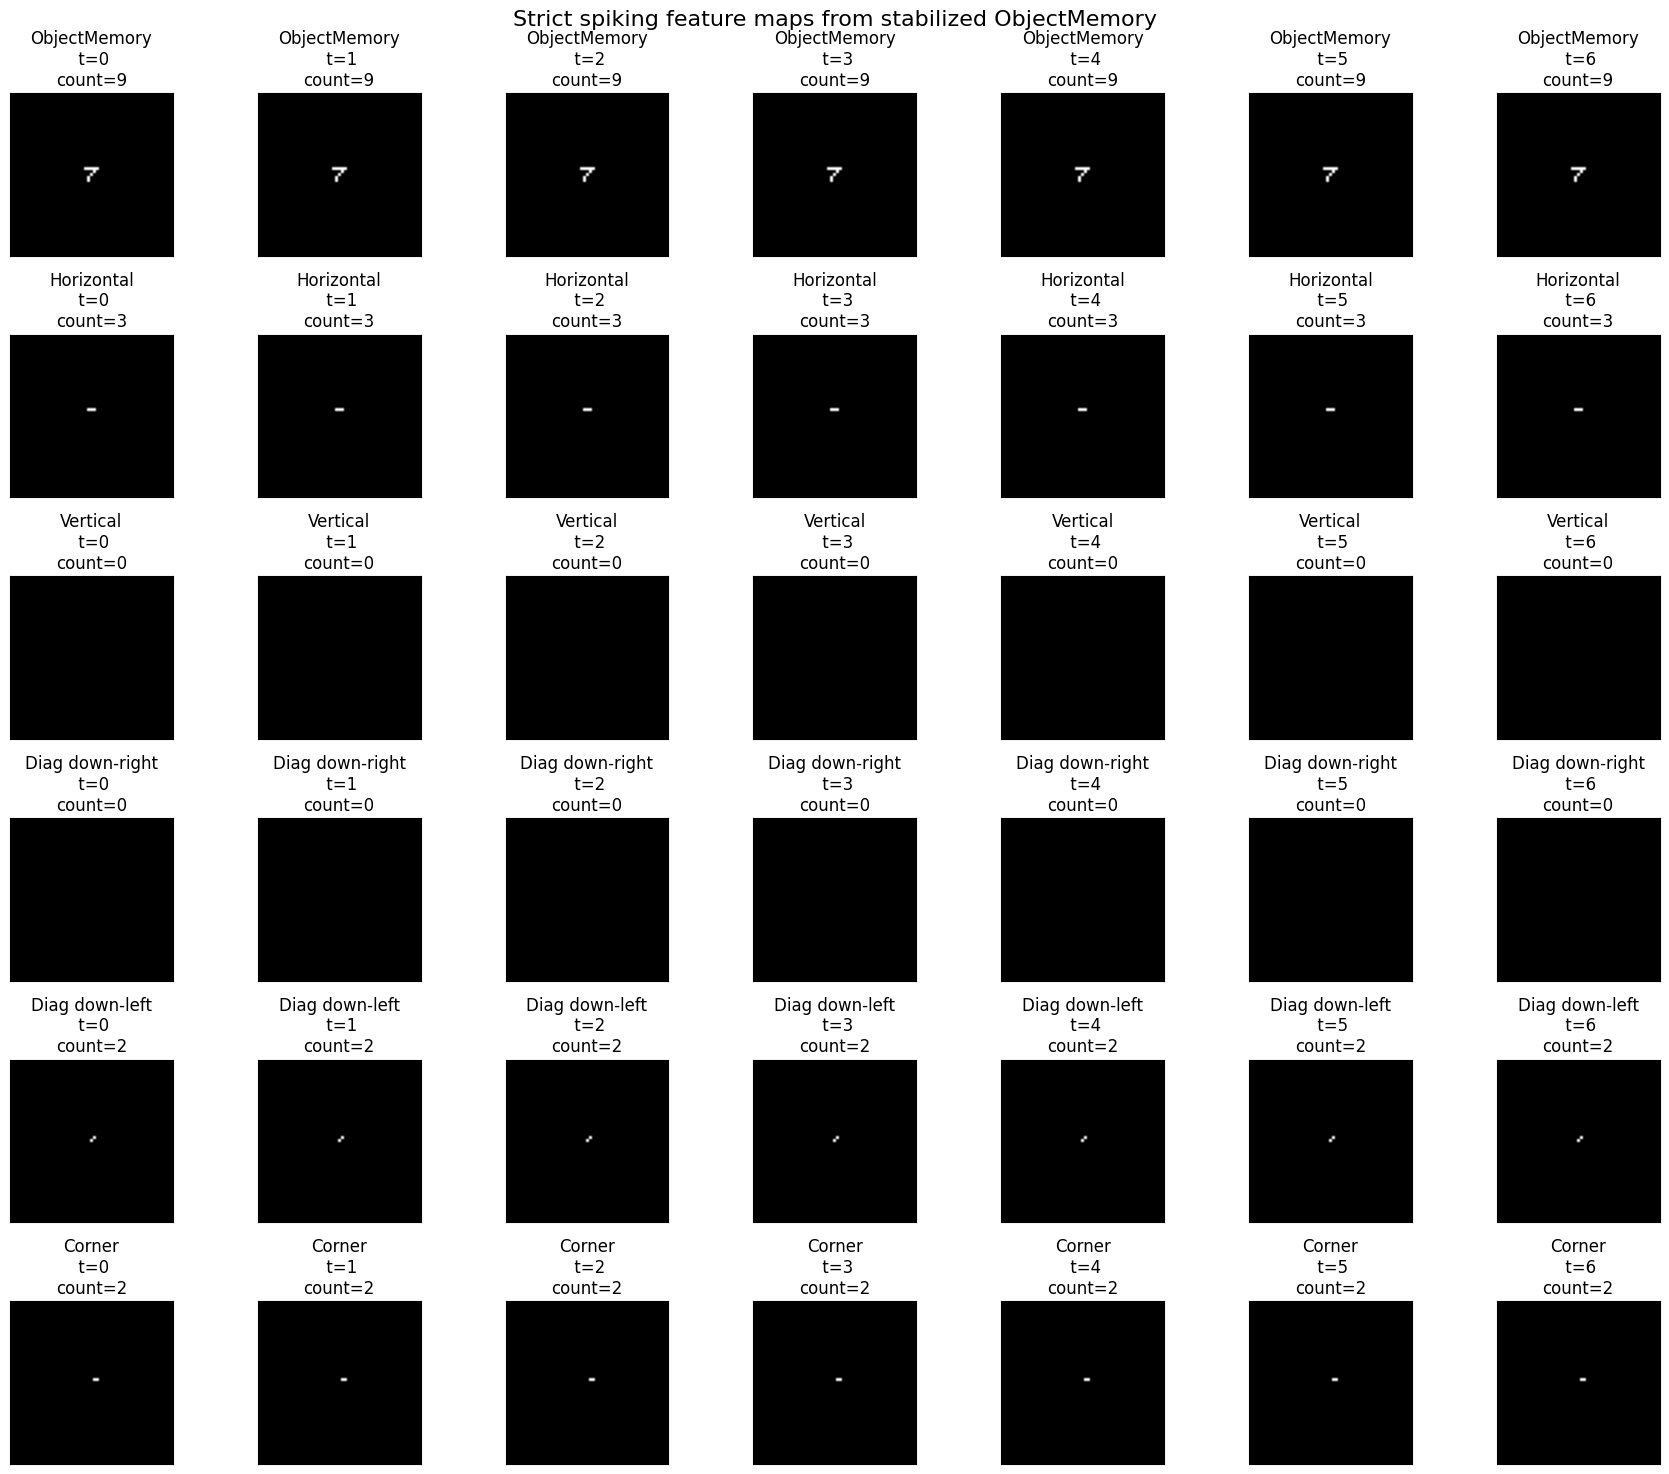

In [286]:
features_with_diagonals_result = compute_strict_basic_shape_features_with_diagonals(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
)

plot_spiking_feature_maps_with_diagonals(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
    features_result=features_with_diagonals_result,
    padding=10,
)

In [287]:
feature_count_table_with_diagonals = pd.DataFrame({
    "t": list(range(direction_changing_result["memory_spike_history"].shape[0])),
    "object_memory_spike_count": [
        int(direction_changing_result["memory_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "horizontal_feature_spike_count": [
        int(features_with_diagonals_result["horizontal"]["feature_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "vertical_feature_spike_count": [
        int(features_with_diagonals_result["vertical"]["feature_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "diagonal_down_right_feature_spike_count": [
        int(features_with_diagonals_result["diagonal_down_right"]["feature_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "diagonal_down_left_feature_spike_count": [
        int(features_with_diagonals_result["diagonal_down_left"]["feature_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
    "corner_feature_spike_count": [
        int(features_with_diagonals_result["corner_spike_history"][t].sum().item())
        for t in range(direction_changing_result["memory_spike_history"].shape[0])
    ],
})

feature_count_table_with_diagonals

,t,object_memory_spike_count,horizontal_feature_spike_count,vertical_feature_spike_count,diagonal_down_right_feature_spike_count,diagonal_down_left_feature_spike_count,corner_feature_spike_count
0,0,9,3,0,0,2,2
1,1,9,3,0,0,2,2
2,2,9,3,0,0,2,2
3,3,9,3,0,0,2,2
4,4,9,3,0,0,2,2
5,5,9,3,0,0,2,2
6,6,9,3,0,0,2,2


In [295]:
def compute_strict_basic_shape_features_with_junctions(
    object_memory_spike_history,
):
    """
    Strict reusable spatial feature maps from ObjectMemory spikes.

    Features:
        horizontal
        vertical
        diagonal_down_right
        diagonal_down_left
        small_corner
        horizontal_to_diagonal_junction

    No temporal accumulation here.
    """

    horizontal_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[[1, 1, 1]],
        threshold=2.5,
    )

    vertical_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1],
            [1],
            [1],
        ],
        threshold=2.5,
    )

    diagonal_down_right_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 0, 0],
            [0, 1, 0],
            [0, 0, 1],
        ],
        threshold=2.5,
    )

    diagonal_down_left_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [0, 0, 1],
            [0, 1, 0],
            [1, 0, 0],
        ],
        threshold=2.5,
    )

    # Small generic 2x2 corners.
    small_corner_1_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [0, 1],
        ],
        threshold=2.5,
    )

    small_corner_2_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1],
            [1, 0],
        ],
        threshold=2.5,
    )

    small_corner_3_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 0],
            [1, 1],
        ],
        threshold=2.5,
    )

    small_corner_4_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [0, 1],
            [1, 1],
        ],
        threshold=2.5,
    )

    small_corner_spike_history = torch.clamp(
        small_corner_1_result["feature_spike_history"]
        + small_corner_2_result["feature_spike_history"]
        + small_corner_3_result["feature_spike_history"]
        + small_corner_4_result["feature_spike_history"],
        min=0,
        max=1,
    )

    # Horizontal-to-diagonal junctions.
    # These are more relevant for a 7 than pure L-corners.
    junction_down_left_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1, 1],
            [0, 1, 0],
            [1, 0, 0],
        ],
        threshold=4.5,
    )

    junction_down_right_result = compute_strict_local_feature_map_over_time(
        input_spike_history=object_memory_spike_history,
        kernel=[
            [1, 1, 1],
            [0, 1, 0],
            [0, 0, 1],
        ],
        threshold=4.5,
    )

    horizontal_to_diagonal_junction_spike_history = torch.clamp(
        junction_down_left_result["feature_spike_history"]
        + junction_down_right_result["feature_spike_history"],
        min=0,
        max=1,
    )

    return {
        "horizontal": horizontal_result,
        "vertical": vertical_result,
        "diagonal_down_right": diagonal_down_right_result,
        "diagonal_down_left": diagonal_down_left_result,

        "small_corner_1": small_corner_1_result,
        "small_corner_2": small_corner_2_result,
        "small_corner_3": small_corner_3_result,
        "small_corner_4": small_corner_4_result,
        "small_corner_spike_history": small_corner_spike_history,

        "junction_down_left": junction_down_left_result,
        "junction_down_right": junction_down_right_result,
        "horizontal_to_diagonal_junction_spike_history": horizontal_to_diagonal_junction_spike_history,
    }

In [293]:
def plot_spiking_feature_maps_with_junctions(
    object_memory_spike_history,
    features_result,
    padding=8,
):
    """
    Plot ObjectMemory spikes next to strict feature maps over time.

    Rows:
        1. ObjectMemory spikes
        2. Horizontal
        3. Vertical
        4. Diagonal down-right
        5. Diagonal down-left
        6. Small corner
        7. Horizontal-to-diagonal junction
    """

    horizontal_spikes = features_result["horizontal"]["feature_spike_history"]
    vertical_spikes = features_result["vertical"]["feature_spike_history"]
    diagonal_down_right_spikes = features_result["diagonal_down_right"]["feature_spike_history"]
    diagonal_down_left_spikes = features_result["diagonal_down_left"]["feature_spike_history"]
    small_corner_spikes = features_result["small_corner_spike_history"]
    junction_spikes = features_result["horizontal_to_diagonal_junction_spike_history"]

    crop = get_activity_crop_from_tensors(
        [
            object_memory_spike_history,
            horizontal_spikes,
            vertical_spikes,
            diagonal_down_right_spikes,
            diagonal_down_left_spikes,
            small_corner_spikes,
            junction_spikes,
        ],
        padding=padding,
        min_height=55,
        min_width=55,
    )

    if crop is None:
        print("No activity found to plot.")
        return

    y_min, y_max, x_min, x_max = crop
    num_steps = object_memory_spike_history.shape[0]

    fig, axes = plt.subplots(7, num_steps, figsize=(2.5 * num_steps, 17))

    for t in range(num_steps):
        axes[0, t].imshow(
            object_memory_spike_history[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[0, t].set_title(
            f"ObjectMemory\n t={t}\ncount={int(object_memory_spike_history[t].sum().item())}"
        )

        axes[1, t].imshow(
            horizontal_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[1, t].set_title(
            f"Horizontal\n t={t}\ncount={int(horizontal_spikes[t].sum().item())}"
        )

        axes[2, t].imshow(
            vertical_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[2, t].set_title(
            f"Vertical\n t={t}\ncount={int(vertical_spikes[t].sum().item())}"
        )

        axes[3, t].imshow(
            diagonal_down_right_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[3, t].set_title(
            f"Diag down-right\n t={t}\ncount={int(diagonal_down_right_spikes[t].sum().item())}"
        )

        axes[4, t].imshow(
            diagonal_down_left_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[4, t].set_title(
            f"Diag down-left\n t={t}\ncount={int(diagonal_down_left_spikes[t].sum().item())}"
        )

        axes[5, t].imshow(
            small_corner_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[5, t].set_title(
            f"Small corner\n t={t}\ncount={int(small_corner_spikes[t].sum().item())}"
        )

        axes[6, t].imshow(
            junction_spikes[t, y_min:y_max, x_min:x_max],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[6, t].set_title(
            f"Junction\n t={t}\ncount={int(junction_spikes[t].sum().item())}"
        )

        for row in range(7):
            axes[row, t].set_xticks([])
            axes[row, t].set_yticks([])

    plt.suptitle(
        "Strict feature maps from stabilized ObjectMemory",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

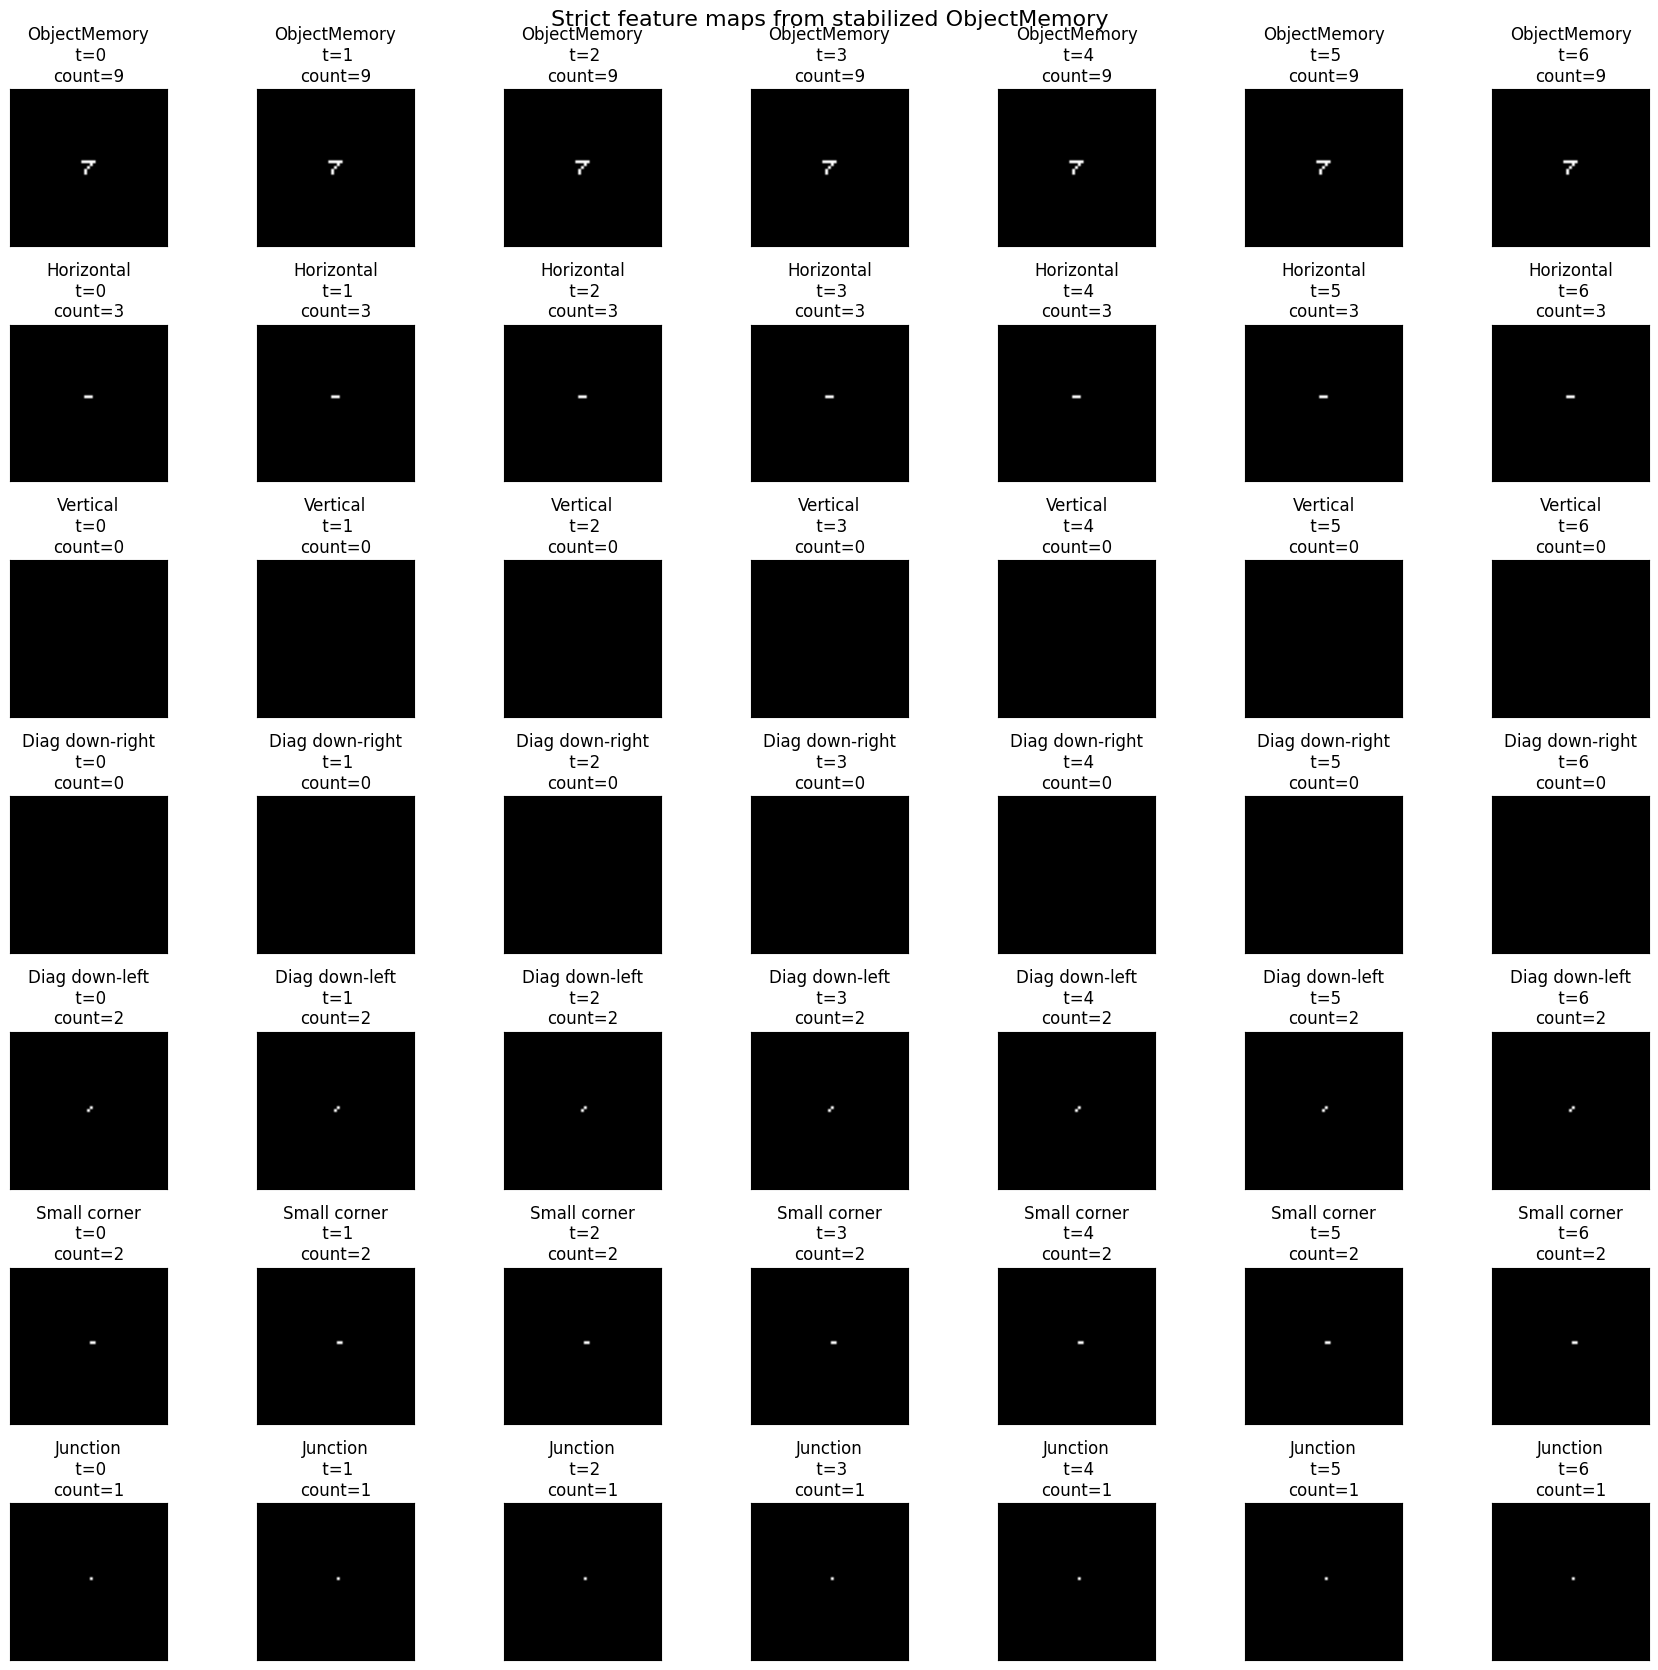

In [296]:
features_with_junctions_result = compute_strict_basic_shape_features_with_junctions(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
)

plot_spiking_feature_maps_with_junctions(
    object_memory_spike_history=direction_changing_result["memory_spike_history"],
    features_result=features_with_junctions_result,
    padding=10,
)

In [297]:
feature_summary_with_junctions = pd.DataFrame({
    "feature": [
        "horizontal",
        "vertical",
        "diagonal_down_right",
        "diagonal_down_left",
        "small_corner",
        "junction",
    ],
    "total_spikes_over_time": [
        int(features_with_junctions_result["horizontal"]["feature_spike_history"].sum().item()),
        int(features_with_junctions_result["vertical"]["feature_spike_history"].sum().item()),
        int(features_with_junctions_result["diagonal_down_right"]["feature_spike_history"].sum().item()),
        int(features_with_junctions_result["diagonal_down_left"]["feature_spike_history"].sum().item()),
        int(features_with_junctions_result["small_corner_spike_history"].sum().item()),
        int(features_with_junctions_result["horizontal_to_diagonal_junction_spike_history"].sum().item()),
    ],
    "active_frames": [
        int((features_with_junctions_result["horizontal"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
        int((features_with_junctions_result["vertical"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
        int((features_with_junctions_result["diagonal_down_right"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
        int((features_with_junctions_result["diagonal_down_left"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
        int((features_with_junctions_result["small_corner_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
        int((features_with_junctions_result["horizontal_to_diagonal_junction_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
    ],
})

feature_summary_with_junctions

,feature,total_spikes_over_time,active_frames
0,horizontal,21,7
1,vertical,0,0
2,diagonal_down_right,0,0
3,diagonal_down_left,14,7
4,small_corner,14,7
5,junction,7,7


## Seven evidence neuron from stabilized feature maps

In [298]:
def run_seven_evidence_neuron(
    features_result,
    horizontal_weight=1.0,
    diagonal_down_left_weight=1.5,
    junction_weight=2.0,
    small_corner_weight=0.5,
    vertical_inhibition_weight=1.0,
    diagonal_down_right_inhibition_weight=1.0,
    beta=0.8,
    threshold=6.0,
    reset_mode="subtract",
):
    """
    Single LIF SevenEvidence neuron.

    It receives excitatory evidence from features expected in our toy seven:
        horizontal
        diagonal_down_left
        horizontal_to_diagonal_junction
        small_corner

    It receives inhibitory evidence from features not expected in this seven:
        vertical
        diagonal_down_right

    This is a hand-built spiking readout, not a trained classifier yet.
    """

    horizontal_spikes = features_result["horizontal"]["feature_spike_history"]
    vertical_spikes = features_result["vertical"]["feature_spike_history"]
    diagonal_down_left_spikes = features_result["diagonal_down_left"]["feature_spike_history"]
    diagonal_down_right_spikes = features_result["diagonal_down_right"]["feature_spike_history"]
    small_corner_spikes = features_result["small_corner_spike_history"]
    junction_spikes = features_result["horizontal_to_diagonal_junction_spike_history"]

    num_steps = horizontal_spikes.shape[0]

    membrane = torch.zeros((), dtype=torch.float32)

    seven_input_history = []
    seven_spike_history = []
    seven_membrane_history = []

    table_rows = []

    for t in range(num_steps):
        horizontal_count = horizontal_spikes[t].sum()
        diagonal_down_left_count = diagonal_down_left_spikes[t].sum()
        junction_count = junction_spikes[t].sum()
        small_corner_count = small_corner_spikes[t].sum()

        vertical_count = vertical_spikes[t].sum()
        diagonal_down_right_count = diagonal_down_right_spikes[t].sum()

        excitatory_input = (
            horizontal_weight * horizontal_count
            + diagonal_down_left_weight * diagonal_down_left_count
            + junction_weight * junction_count
            + small_corner_weight * small_corner_count
        )

        inhibitory_input = (
            vertical_inhibition_weight * vertical_count
            + diagonal_down_right_inhibition_weight * diagonal_down_right_count
        )

        current_input = excitatory_input - inhibitory_input

        seven_spike, membrane = lif_step(
            input_current=current_input,
            membrane=membrane,
            beta=beta,
            threshold=threshold,
            reset_mode=reset_mode,
        )

        seven_input_history.append(current_input.clone())
        seven_spike_history.append(seven_spike.clone())
        seven_membrane_history.append(membrane.clone())

        table_rows.append({
            "t": t,
            "horizontal_count": int(horizontal_count.item()),
            "diagonal_down_left_count": int(diagonal_down_left_count.item()),
            "junction_count": int(junction_count.item()),
            "small_corner_count": int(small_corner_count.item()),
            "vertical_count": int(vertical_count.item()),
            "diagonal_down_right_count": int(diagonal_down_right_count.item()),
            "seven_input": float(current_input.item()),
            "seven_spike": int(seven_spike.item()),
            "seven_membrane": float(membrane.item()),
        })

    return {
        "seven_input_history": torch.stack(seven_input_history),
        "seven_spike_history": torch.stack(seven_spike_history),
        "seven_membrane_history": torch.stack(seven_membrane_history),
        "table": pd.DataFrame(table_rows),
    }

In [299]:
seven_evidence_result = run_seven_evidence_neuron(
    features_result=features_with_junctions_result,
    beta=0.8,
    threshold=6.0,
    reset_mode="subtract",
)

seven_evidence_result["table"]

,t,horizontal_count,diagonal_down_left_count,junction_count,small_corner_count,vertical_count,diagonal_down_right_count,seven_input,seven_spike,seven_membrane
0,0,3,2,1,2,0,0,9.0,1,3.000000
1,1,3,2,1,2,0,0,9.0,1,5.400000
2,2,3,2,1,2,0,0,9.0,1,7.320000
3,3,3,2,1,2,0,0,9.0,1,8.856000
4,4,3,2,1,2,0,0,9.0,1,10.084801
5,5,3,2,1,2,0,0,9.0,1,11.067841
6,6,3,2,1,2,0,0,9.0,1,11.854273


In [300]:
def plot_seven_evidence_result(seven_evidence_result):
    """
    Plot SevenEvidence input, membrane, and spikes over time.
    """

    table = seven_evidence_result["table"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(table["t"], table["seven_input"], marker="o")
    axes[0].set_ylabel("Input current")
    axes[0].set_title("SevenEvidence input over time")

    axes[1].plot(table["t"], table["seven_membrane"], marker="o")
    axes[1].set_ylabel("Membrane")
    axes[1].set_title("SevenEvidence membrane over time")

    axes[2].stem(table["t"], table["seven_spike"])
    axes[2].set_ylabel("Spike")
    axes[2].set_xlabel("Time")
    axes[2].set_title("SevenEvidence spikes")

    plt.tight_layout()
    plt.show()

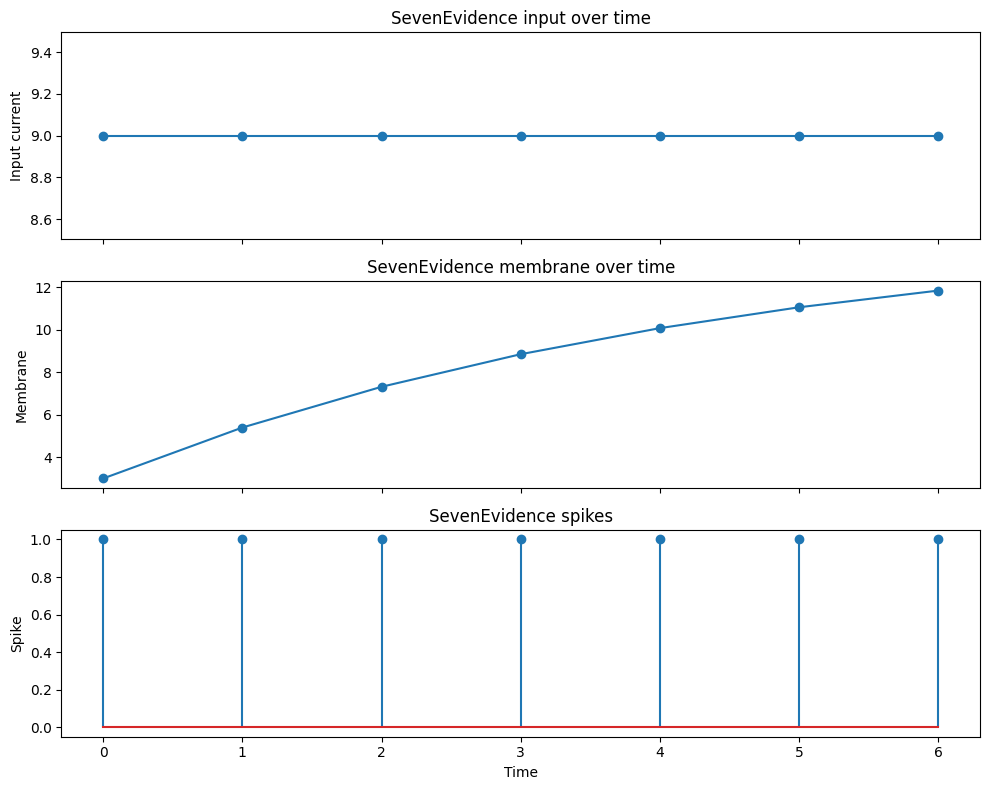

In [301]:
plot_seven_evidence_result(seven_evidence_result)

In [302]:
seven_evidence_result = run_seven_evidence_neuron(
    features_result=features_with_junctions_result,
    beta=0.8,
    threshold=12.0,
    reset_mode="subtract",
)

seven_evidence_result["table"]

,t,horizontal_count,diagonal_down_left_count,junction_count,small_corner_count,vertical_count,diagonal_down_right_count,seven_input,seven_spike,seven_membrane
0,0,3,2,1,2,0,0,9.0,0,9.000000
1,1,3,2,1,2,0,0,9.0,1,4.200001
2,2,3,2,1,2,0,0,9.0,1,0.360001
3,3,3,2,1,2,0,0,9.0,0,9.288000
4,4,3,2,1,2,0,0,9.0,1,4.430401
5,5,3,2,1,2,0,0,9.0,1,0.544321
6,6,3,2,1,2,0,0,9.0,0,9.435457


In [304]:
def run_full_seven_evidence_pipeline_for_shape(
    shape_name,
    velocity_sequence,
    start_top=50,
    start_left=30,
    max_velocity=6,
    max_displacement=36,
    velocity_params=None,
    seven_threshold=12.0,
):
    """
    Run the full pipeline on one shape:

        moving input
        -> displacement-gated object memory
        -> strict feature maps with junctions
        -> SevenEvidence neuron

    This lets us compare seven vs non-seven shapes.
    """

    if velocity_params is None:
        velocity_params = GOOD_VELOCITY_PARAMS

    case = make_variable_velocity_spike_case(
        velocity_sequence=velocity_sequence,
        shape_name=shape_name,
        start_top=start_top,
        start_left=start_left,
    )

    object_memory_result = run_displacement_gated_object_memory(
        case=case,
        max_velocity=max_velocity,
        max_displacement=max_displacement,
        velocity_params=velocity_params,
        threshold_memory=1.5,
        beta_memory=0.8,
        reset_mode="subtract",
    )

    features_result = compute_strict_basic_shape_features_with_junctions(
        object_memory_spike_history=object_memory_result["memory_spike_history"],
    )

    seven_evidence_result = run_seven_evidence_neuron(
        features_result=features_result,
        beta=0.8,
        threshold=seven_threshold,
        reset_mode="subtract",
    )

    feature_summary = pd.DataFrame({
        "feature": [
            "horizontal",
            "vertical",
            "diagonal_down_right",
            "diagonal_down_left",
            "small_corner",
            "junction",
        ],
        "total_spikes_over_time": [
            int(features_result["horizontal"]["feature_spike_history"].sum().item()),
            int(features_result["vertical"]["feature_spike_history"].sum().item()),
            int(features_result["diagonal_down_right"]["feature_spike_history"].sum().item()),
            int(features_result["diagonal_down_left"]["feature_spike_history"].sum().item()),
            int(features_result["small_corner_spike_history"].sum().item()),
            int(features_result["horizontal_to_diagonal_junction_spike_history"].sum().item()),
        ],
        "active_frames": [
            int((features_result["horizontal"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
            int((features_result["vertical"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
            int((features_result["diagonal_down_right"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
            int((features_result["diagonal_down_left"]["feature_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
            int((features_result["small_corner_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
            int((features_result["horizontal_to_diagonal_junction_spike_history"].sum(dim=(1, 2)) > 0).sum().item()),
        ],
    })

    return {
        "shape_name": shape_name,
        "case": case,
        "object_memory_result": object_memory_result,
        "features_result": features_result,
        "seven_evidence_result": seven_evidence_result,
        "feature_summary": feature_summary,
    }

In [305]:
seven_test_result = run_full_seven_evidence_pipeline_for_shape(
    shape_name="seven",
    velocity_sequence=direction_changing_velocity_sequence,
    seven_threshold=12.0,
)

seven_test_result["feature_summary"]

,feature,total_spikes_over_time,active_frames
0,horizontal,21,7
1,vertical,0,0
2,diagonal_down_right,0,0
3,diagonal_down_left,14,7
4,small_corner,14,7
5,junction,7,7


In [306]:
seven_test_result["seven_evidence_result"]["table"]

,t,horizontal_count,diagonal_down_left_count,junction_count,small_corner_count,vertical_count,diagonal_down_right_count,seven_input,seven_spike,seven_membrane
0,0,3,2,1,2,0,0,9.0,0,9.000000
1,1,3,2,1,2,0,0,9.0,1,4.200001
2,2,3,2,1,2,0,0,9.0,1,0.360001
3,3,3,2,1,2,0,0,9.0,0,9.288000
4,4,3,2,1,2,0,0,9.0,1,4.430401
5,5,3,2,1,2,0,0,9.0,1,0.544321
6,6,3,2,1,2,0,0,9.0,0,9.435457


In [307]:
nonseven_shape_names = [
    shape_name
    for shape_name in SHAPE_TEMPLATES.keys()
    if shape_name != "seven"
]

nonseven_shape_names

['ell', 'tee', 'box']

In [308]:
negative_control_results = {}

for shape_name in nonseven_shape_names:
    print("Running:", shape_name)

    negative_control_results[shape_name] = run_full_seven_evidence_pipeline_for_shape(
        shape_name=shape_name,
        velocity_sequence=direction_changing_velocity_sequence,
        seven_threshold=12.0,
    )

Running: ell
Running: tee
Running: box


In [309]:
comparison_rows = []

comparison_rows.append({
    "shape": "seven",
    "total_seven_spikes": int(seven_test_result["seven_evidence_result"]["seven_spike_history"].sum().item()),
    "total_seven_input": float(seven_test_result["seven_evidence_result"]["seven_input_history"].sum().item()),
    "max_seven_membrane": float(seven_test_result["seven_evidence_result"]["seven_membrane_history"].max().item()),
})

for shape_name, result in negative_control_results.items():
    comparison_rows.append({
        "shape": shape_name,
        "total_seven_spikes": int(result["seven_evidence_result"]["seven_spike_history"].sum().item()),
        "total_seven_input": float(result["seven_evidence_result"]["seven_input_history"].sum().item()),
        "max_seven_membrane": float(result["seven_evidence_result"]["seven_membrane_history"].max().item()),
    })

seven_negative_control_comparison = pd.DataFrame(comparison_rows)
seven_negative_control_comparison.sort_values(
    ["total_seven_spikes", "total_seven_input"],
    ascending=False,
)

,shape,total_seven_spikes,total_seven_input,max_seven_membrane
0,seven,4,63.0,9.435457
3,box,0,14.0,7.902849
2,tee,0,7.0,3.951424
1,ell,0,3.5,1.975712


Using stabilized object-centered spikes, local feature populations produce a seven-specific feature signature. A downstream LIF evidence neuron spikes for the moving seven but not for other moving toy shapes under the same motion sequence.

In [310]:
seven_negative_control_comparison.sort_values(
    ["total_seven_spikes", "total_seven_input"],
    ascending=False,
)

,shape,total_seven_spikes,total_seven_input,max_seven_membrane
0,seven,4,63.0,9.435457
3,box,0,14.0,7.902849
2,tee,0,7.0,3.951424
1,ell,0,3.5,1.975712


In [311]:
seven_negative_control_comparison["classified_as_seven"] = (
    seven_negative_control_comparison["total_seven_spikes"] > 0
)

seven_negative_control_comparison

,shape,total_seven_spikes,total_seven_input,max_seven_membrane,classified_as_seven
0,seven,4,63.0,9.435457,True
1,ell,0,3.5,1.975712,False
2,tee,0,7.0,3.951424,False
3,box,0,14.0,7.902849,False


In [312]:
robustness_velocity_sequences = {
    "constant_right_slow": [
        (0, 2),
        (0, 2),
        (0, 2),
        (0, 2),
        (0, 2),
        (0, 2),
    ],

    "constant_right_fast": [
        (0, 4),
        (0, 4),
        (0, 4),
        (0, 4),
        (0, 4),
        (0, 4),
    ],

    "diagonal_down_right": [
        (1, 2),
        (1, 2),
        (1, 2),
        (1, 2),
        (1, 2),
        (1, 2),
    ],

    "variable_horizontal": [
        (0, 2),
        (0, 3),
        (0, 1),
        (0, 4),
        (0, 2),
        (0, 5),
    ],

    "direction_changing": [
        (1, 3),
        (2, 2),
        (-1, 4),
        (3, -2),
        (-2, -3),
        (1, 2),
    ],
}

In [313]:
def run_robustness_test_for_seven_evidence(
    shape_names,
    velocity_sequences,
    seven_threshold=12.0,
):
    """
    Test SevenEvidence across multiple shapes and motion sequences.
    """

    rows = []
    results = {}

    for sequence_name, velocity_sequence in velocity_sequences.items():
        results[sequence_name] = {}

        for shape_name in shape_names:
            print(f"Running shape={shape_name}, sequence={sequence_name}")

            result = run_full_seven_evidence_pipeline_for_shape(
                shape_name=shape_name,
                velocity_sequence=velocity_sequence,
                seven_threshold=seven_threshold,
            )

            results[sequence_name][shape_name] = result

            total_seven_spikes = int(
                result["seven_evidence_result"]["seven_spike_history"].sum().item()
            )

            total_seven_input = float(
                result["seven_evidence_result"]["seven_input_history"].sum().item()
            )

            max_seven_membrane = float(
                result["seven_evidence_result"]["seven_membrane_history"].max().item()
            )

            rows.append({
                "sequence": sequence_name,
                "shape": shape_name,
                "total_seven_spikes": total_seven_spikes,
                "total_seven_input": total_seven_input,
                "max_seven_membrane": max_seven_membrane,
                "classified_as_seven": total_seven_spikes > 0,
            })

    return {
        "table": pd.DataFrame(rows),
        "results": results,
    }

In [314]:
shape_names_to_test = list(SHAPE_TEMPLATES.keys())

robustness_result = run_robustness_test_for_seven_evidence(
    shape_names=shape_names_to_test,
    velocity_sequences=robustness_velocity_sequences,
    seven_threshold=12.0,
)

robustness_table = robustness_result["table"]
robustness_table

Running shape=seven, sequence=constant_right_slow
Running shape=ell, sequence=constant_right_slow
Running shape=tee, sequence=constant_right_slow
Running shape=box, sequence=constant_right_slow
Running shape=seven, sequence=constant_right_fast
Running shape=ell, sequence=constant_right_fast
Running shape=tee, sequence=constant_right_fast
Running shape=box, sequence=constant_right_fast
Running shape=seven, sequence=diagonal_down_right
Running shape=ell, sequence=diagonal_down_right
Running shape=tee, sequence=diagonal_down_right
Running shape=box, sequence=diagonal_down_right
Running shape=seven, sequence=variable_horizontal
Running shape=ell, sequence=variable_horizontal
Running shape=tee, sequence=variable_horizontal
Running shape=box, sequence=variable_horizontal
Running shape=seven, sequence=direction_changing
Running shape=ell, sequence=direction_changing
Running shape=tee, sequence=direction_changing
Running shape=box, sequence=direction_changing


,sequence,shape,total_seven_spikes,total_seven_input,max_seven_membrane,classified_as_seven
0,constant_right_slow,seven,4,63.0,9.435457,True
1,constant_right_slow,ell,0,3.5,1.975712,False
2,constant_right_slow,tee,0,7.0,3.951424,False
3,constant_right_slow,box,0,14.0,7.902849,False
4,constant_right_fast,seven,4,63.0,9.435457,True
5,constant_right_fast,ell,0,3.5,1.975712,False
6,constant_right_fast,tee,0,7.0,3.951424,False
7,constant_right_fast,box,0,14.0,7.902849,False
8,diagonal_down_right,seven,4,63.0,9.435457,True
9,diagonal_down_right,ell,0,3.5,1.975712,False


In [315]:
robustness_table.sort_values(
    ["sequence", "total_seven_spikes", "total_seven_input"],
    ascending=[True, False, False],
)

,sequence,shape,total_seven_spikes,total_seven_input,max_seven_membrane,classified_as_seven
4,constant_right_fast,seven,4,63.0,9.435457,True
7,constant_right_fast,box,0,14.0,7.902849,False
6,constant_right_fast,tee,0,7.0,3.951424,False
5,constant_right_fast,ell,0,3.5,1.975712,False
0,constant_right_slow,seven,4,63.0,9.435457,True
3,constant_right_slow,box,0,14.0,7.902849,False
2,constant_right_slow,tee,0,7.0,3.951424,False
1,constant_right_slow,ell,0,3.5,1.975712,False
8,diagonal_down_right,seven,4,63.0,9.435457,True
11,diagonal_down_right,box,0,14.0,7.902849,False


In [316]:
robustness_spike_pivot = robustness_table.pivot(
    index="sequence",
    columns="shape",
    values="total_seven_spikes",
)

robustness_spike_pivot

shape,box,ell,seven,tee
sequence,,,,
constant_right_fast,0,0,4,0
constant_right_slow,0,0,4,0
diagonal_down_right,0,0,4,0
direction_changing,0,0,4,0
variable_horizontal,0,0,4,0


In [317]:
robustness_input_pivot = robustness_table.pivot(
    index="sequence",
    columns="shape",
    values="total_seven_input",
)

robustness_input_pivot

shape,box,ell,seven,tee
sequence,,,,
constant_right_fast,14.0,3.5,63.0,7.0
constant_right_slow,14.0,3.5,63.0,7.0
diagonal_down_right,14.0,3.5,63.0,7.0
direction_changing,14.0,3.5,63.0,7.0
variable_horizontal,14.0,3.5,63.0,7.0


In [318]:
for sequence_name, velocity_sequence in robustness_velocity_sequences.items():
    case = make_variable_velocity_spike_case(
        velocity_sequence=velocity_sequence,
        shape_name="seven",
        start_top=50,
        start_left=30,
    )

    print(sequence_name)
    print("velocity_sequence:", velocity_sequence)
    print("origins:", case["origins"])
    print()

constant_right_slow
velocity_sequence: [(0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2)]
origins: [(50, 30), (50, 32), (50, 34), (50, 36), (50, 38), (50, 40), (50, 42)]

constant_right_fast
velocity_sequence: [(0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4)]
origins: [(50, 30), (50, 34), (50, 38), (50, 42), (50, 46), (50, 50), (50, 54)]

diagonal_down_right
velocity_sequence: [(1, 2), (1, 2), (1, 2), (1, 2), (1, 2), (1, 2)]
origins: [(50, 30), (51, 32), (52, 34), (53, 36), (54, 38), (55, 40), (56, 42)]

variable_horizontal
velocity_sequence: [(0, 2), (0, 3), (0, 1), (0, 4), (0, 2), (0, 5)]
origins: [(50, 30), (50, 32), (50, 35), (50, 36), (50, 40), (50, 42), (50, 47)]

direction_changing
velocity_sequence: [(1, 3), (2, 2), (-1, 4), (3, -2), (-2, -3), (1, 2)]
origins: [(50, 30), (51, 33), (53, 35), (52, 39), (55, 37), (53, 34), (54, 36)]



In [319]:
robustness_table["correct"] = (
    ((robustness_table["shape"] == "seven") & robustness_table["classified_as_seven"])
    |
    ((robustness_table["shape"] != "seven") & (~robustness_table["classified_as_seven"]))
)

robustness_table[["sequence", "shape", "total_seven_spikes", "total_seven_input", "classified_as_seven", "correct"]]

,sequence,shape,total_seven_spikes,total_seven_input,classified_as_seven,correct
0,constant_right_slow,seven,4,63.0,True,True
1,constant_right_slow,ell,0,3.5,False,True
2,constant_right_slow,tee,0,7.0,False,True
3,constant_right_slow,box,0,14.0,False,True
4,constant_right_fast,seven,4,63.0,True,True
5,constant_right_fast,ell,0,3.5,False,True
6,constant_right_fast,tee,0,7.0,False,True
7,constant_right_fast,box,0,14.0,False,True
8,diagonal_down_right,seven,4,63.0,True,True
9,diagonal_down_right,ell,0,3.5,False,True


In [320]:
robustness_accuracy = robustness_table["correct"].mean()
robustness_accuracy

np.float64(1.0)

### Robustness test conclusion

Across all tested motion sequences, the SevenEvidence neuron spiked for the moving seven and remained silent for the non-seven shapes. The SevenEvidence input was also consistently much larger for the seven than for the box, tee, or ell.

This suggests that the pipeline is not merely detecting motion or object presence. Instead, it is detecting a stabilized seven-specific feature signature after velocity/displacement compensation.

The current pipeline is:

moving input spikes → velocity/displacement tracking → stabilized ObjectMemory → strict local feature maps → SevenEvidence LIF readout.

In these toy tests, the readout correctly classified the seven across different motion paths while rejecting the other toy shapes.

### Checkpoint: motion-invariant seven recognition

The full pipeline was tested across multiple motion sequences and toy shapes.

Pipeline:

moving input spikes → velocity/displacement tracking → stabilized ObjectMemory → strict local feature maps → SevenEvidence LIF readout

Across all tested motion sequences, the SevenEvidence neuron spiked for the moving seven and remained silent for the non-seven toy shapes. The robustness accuracy was 1.0 on this toy test set.

This suggests that the readout is not simply detecting motion or object presence. Instead, after velocity/displacement compensation, the model produces a stabilized seven-specific feature signature.

In [321]:
high_speed_velocity_sequences = {
    "right_speed_2": [
        (0, 2),
        (0, 2),
        (0, 2),
        (0, 2),
        (0, 2),
        (0, 2),
    ],

    "right_speed_4": [
        (0, 4),
        (0, 4),
        (0, 4),
        (0, 4),
        (0, 4),
        (0, 4),
    ],

    "right_speed_6": [
        (0, 6),
        (0, 6),
        (0, 6),
        (0, 6),
        (0, 6),
        (0, 6),
    ],

    "right_speed_8": [
        (0, 8),
        (0, 8),
        (0, 8),
        (0, 8),
        (0, 8),
        (0, 8),
    ],

    "right_speed_10": [
        (0, 10),
        (0, 10),
        (0, 10),
        (0, 10),
        (0, 10),
        (0, 10),
    ],

    "right_speed_12": [
        (0, 12),
        (0, 12),
        (0, 12),
        (0, 12),
        (0, 12),
        (0, 12),
    ],
}

In [322]:
high_speed_result_current_limit = run_robustness_test_for_seven_evidence(
    shape_names=["seven", "box", "tee", "ell"],
    velocity_sequences=high_speed_velocity_sequences,
    seven_threshold=12.0,
)

high_speed_table_current_limit = high_speed_result_current_limit["table"]

high_speed_spike_pivot_current_limit = high_speed_table_current_limit.pivot(
    index="sequence",
    columns="shape",
    values="total_seven_spikes",
)

high_speed_input_pivot_current_limit = high_speed_table_current_limit.pivot(
    index="sequence",
    columns="shape",
    values="total_seven_input",
)

high_speed_spike_pivot_current_limit

Running shape=seven, sequence=right_speed_2
Running shape=box, sequence=right_speed_2
Running shape=tee, sequence=right_speed_2
Running shape=ell, sequence=right_speed_2
Running shape=seven, sequence=right_speed_4
Running shape=box, sequence=right_speed_4
Running shape=tee, sequence=right_speed_4
Running shape=ell, sequence=right_speed_4
Running shape=seven, sequence=right_speed_6
Running shape=box, sequence=right_speed_6
Running shape=tee, sequence=right_speed_6
Running shape=ell, sequence=right_speed_6
Running shape=seven, sequence=right_speed_8
Running shape=box, sequence=right_speed_8
Running shape=tee, sequence=right_speed_8
Running shape=ell, sequence=right_speed_8
Running shape=seven, sequence=right_speed_10
Running shape=box, sequence=right_speed_10
Running shape=tee, sequence=right_speed_10
Running shape=ell, sequence=right_speed_10
Running shape=seven, sequence=right_speed_12
Running shape=box, sequence=right_speed_12
Running shape=tee, sequence=right_speed_12
Running shape=e

shape,box,ell,seven,tee
sequence,,,,
right_speed_10,0,0,0,0
right_speed_12,0,0,0,0
right_speed_2,0,0,4,0
right_speed_4,0,0,4,0
right_speed_6,0,0,4,0
right_speed_8,0,0,0,0


In [323]:
high_speed_input_pivot_current_limit

shape,box,ell,seven,tee
sequence,,,,
right_speed_10,-1.0,0.5,9.0,1.0
right_speed_12,2.0,0.5,9.0,1.0
right_speed_2,14.0,3.5,63.0,7.0
right_speed_4,14.0,3.5,63.0,7.0
right_speed_6,14.0,3.5,63.0,7.0
right_speed_8,-1.0,0.5,9.0,1.0


In [324]:
def run_full_seven_evidence_pipeline_for_shape_with_motion_limits(
    shape_name,
    velocity_sequence,
    start_top=50,
    start_left=30,
    max_velocity=12,
    max_displacement=72,
    seven_threshold=12.0,
):
    """
    Same full pipeline, but exposes max_velocity and max_displacement
    so we can test faster motion.
    """

    velocity_params = {
        "threshold_velocity": 15.0,
        "input_scale": 1.0,
        "beta_velocity": 0.8,
        "inhibition_strength": 3.0,
        "inhibition_radius": 1,
        "internal_steps": 5,
    }

    case = make_variable_velocity_spike_case(
        velocity_sequence=velocity_sequence,
        shape_name=shape_name,
        start_top=start_top,
        start_left=start_left,
    )

    object_memory_result = run_displacement_gated_object_memory(
        case=case,
        max_velocity=max_velocity,
        max_displacement=max_displacement,
        velocity_params=velocity_params,
        threshold_memory=1.5,
        beta_memory=0.8,
        reset_mode="subtract",
    )

    features_result = compute_strict_basic_shape_features_with_junctions(
        object_memory_spike_history=object_memory_result["memory_spike_history"],
    )

    seven_evidence_result = run_seven_evidence_neuron(
        features_result=features_result,
        beta=0.8,
        threshold=seven_threshold,
        reset_mode="subtract",
    )

    return {
        "shape_name": shape_name,
        "case": case,
        "object_memory_result": object_memory_result,
        "features_result": features_result,
        "seven_evidence_result": seven_evidence_result,
    }

In [325]:
def run_high_speed_test_with_motion_limits(
    shape_names,
    velocity_sequences,
    max_velocity=12,
    max_displacement=72,
    seven_threshold=12.0,
):
    rows = []
    results = {}

    for sequence_name, velocity_sequence in velocity_sequences.items():
        results[sequence_name] = {}

        for shape_name in shape_names:
            print(f"Running shape={shape_name}, sequence={sequence_name}")

            result = run_full_seven_evidence_pipeline_for_shape_with_motion_limits(
                shape_name=shape_name,
                velocity_sequence=velocity_sequence,
                max_velocity=max_velocity,
                max_displacement=max_displacement,
                seven_threshold=seven_threshold,
            )

            results[sequence_name][shape_name] = result

            total_seven_spikes = int(
                result["seven_evidence_result"]["seven_spike_history"].sum().item()
            )

            total_seven_input = float(
                result["seven_evidence_result"]["seven_input_history"].sum().item()
            )

            max_seven_membrane = float(
                result["seven_evidence_result"]["seven_membrane_history"].max().item()
            )

            rows.append({
                "sequence": sequence_name,
                "shape": shape_name,
                "max_velocity": max_velocity,
                "max_displacement": max_displacement,
                "total_seven_spikes": total_seven_spikes,
                "total_seven_input": total_seven_input,
                "max_seven_membrane": max_seven_membrane,
                "classified_as_seven": total_seven_spikes > 0,
            })

    return {
        "table": pd.DataFrame(rows),
        "results": results,
    }

In [326]:
high_speed_result_larger_limit = run_high_speed_test_with_motion_limits(
    shape_names=["seven", "box", "tee", "ell"],
    velocity_sequences=high_speed_velocity_sequences,
    max_velocity=12,
    max_displacement=72,
    seven_threshold=12.0,
)

high_speed_table_larger_limit = high_speed_result_larger_limit["table"]

high_speed_spike_pivot_larger_limit = high_speed_table_larger_limit.pivot(
    index="sequence",
    columns="shape",
    values="total_seven_spikes",
)

high_speed_input_pivot_larger_limit = high_speed_table_larger_limit.pivot(
    index="sequence",
    columns="shape",
    values="total_seven_input",
)

high_speed_spike_pivot_larger_limit

Running shape=seven, sequence=right_speed_2
Running shape=box, sequence=right_speed_2
Running shape=tee, sequence=right_speed_2
Running shape=ell, sequence=right_speed_2
Running shape=seven, sequence=right_speed_4
Running shape=box, sequence=right_speed_4
Running shape=tee, sequence=right_speed_4
Running shape=ell, sequence=right_speed_4
Running shape=seven, sequence=right_speed_6
Running shape=box, sequence=right_speed_6
Running shape=tee, sequence=right_speed_6
Running shape=ell, sequence=right_speed_6
Running shape=seven, sequence=right_speed_8
Running shape=box, sequence=right_speed_8
Running shape=tee, sequence=right_speed_8
Running shape=ell, sequence=right_speed_8
Running shape=seven, sequence=right_speed_10
Running shape=box, sequence=right_speed_10
Running shape=tee, sequence=right_speed_10
Running shape=ell, sequence=right_speed_10
Running shape=seven, sequence=right_speed_12
Running shape=box, sequence=right_speed_12
Running shape=tee, sequence=right_speed_12
Running shape=e

shape,box,ell,seven,tee
sequence,,,,
right_speed_10,0,0,4,0
right_speed_12,0,0,4,0
right_speed_2,0,0,4,0
right_speed_4,0,0,4,0
right_speed_6,0,0,4,0
right_speed_8,0,0,4,0


In [327]:
high_speed_input_pivot_larger_limit

shape,box,ell,seven,tee
sequence,,,,
right_speed_10,14.0,3.5,63.0,7.0
right_speed_12,14.0,3.5,63.0,7.0
right_speed_2,14.0,3.5,63.0,7.0
right_speed_4,14.0,3.5,63.0,7.0
right_speed_6,14.0,3.5,63.0,7.0
right_speed_8,14.0,3.5,63.0,7.0


The model can recognize fast-moving sevens when the velocity/displacement population range includes the true motion.
Failure occurs when the true motion exceeds the represented velocity range.

### High-speed failure mode interpretation

The high-speed experiment shows that the model can recognize the moving seven at larger per-frame displacements when the represented velocity range is expanded.

With a smaller velocity range, failures are expected once the true motion exceeds the available Velocity[dy, dx] populations. This suggests that high-speed recognition is limited by the motion-representation range rather than by the downstream feature/readout layer.

In other words, the system does not fail because the seven features disappear. It fails when the velocity/displacement layer cannot represent the motion needed to stabilize the object.

In [328]:
def randomly_drop_spikes(spike_history, drop_probability, seed=0):
    """
    Randomly remove some spikes from a spike history.

    spike_history:
        [T, H, W]

    drop_probability:
        probability that an existing spike is removed
    """

    torch.manual_seed(seed)

    spike_history = (spike_history > 0).float()

    keep_mask = torch.rand_like(spike_history) > drop_probability

    dropped_spike_history = spike_history * keep_mask.float()

    return dropped_spike_history

In [332]:
def add_missing_spikes_to_case(case, drop_probability, seed=0):
    """
    Return a copy of a case where some spikes are randomly removed.
    """

    noisy_case = dict(case)
    noisy_case["spikes"] = randomly_drop_spikes(
        spike_history=case["spikes"],
        drop_probability=drop_probability,
        seed=seed,
    )

    noisy_case["frames"] = noisy_case["spikes"].clone()

    return noisy_case

In [333]:
def run_full_seven_evidence_pipeline_for_case(
    case,
    max_velocity=12,
    max_displacement=72,
    seven_threshold=12.0,
):
    """
    Run object memory, features, and SevenEvidence from an existing case.
    Useful for noisy/occluded cases.
    """

    velocity_params = {
        "threshold_velocity": 15.0,
        "input_scale": 1.0,
        "beta_velocity": 0.8,
        "inhibition_strength": 3.0,
        "inhibition_radius": 1,
        "internal_steps": 5,
    }

    object_memory_result = run_displacement_gated_object_memory(
        case=case,
        max_velocity=max_velocity,
        max_displacement=max_displacement,
        velocity_params=velocity_params,
        threshold_memory=1.5,
        beta_memory=0.8,
        reset_mode="subtract",
    )

    features_result = compute_strict_basic_shape_features_with_junctions(
        object_memory_spike_history=object_memory_result["memory_spike_history"],
    )

    seven_evidence_result = run_seven_evidence_neuron(
        features_result=features_result,
        beta=0.8,
        threshold=seven_threshold,
        reset_mode="subtract",
    )

    return {
        "case": case,
        "object_memory_result": object_memory_result,
        "features_result": features_result,
        "seven_evidence_result": seven_evidence_result,
    }

In [334]:
missing_spike_drop_probabilities = [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
]

In [335]:
missing_spike_rows = []
missing_spike_results = {}

base_case = make_variable_velocity_spike_case(
    velocity_sequence=direction_changing_velocity_sequence,
    shape_name="seven",
    start_top=50,
    start_left=30,
)

for drop_probability in missing_spike_drop_probabilities:
    for seed in range(5):
        print("drop_probability:", drop_probability, "seed:", seed)

        dropped_case = add_missing_spikes_to_case(
            case=base_case,
            drop_probability=drop_probability,
            seed=seed,
        )

        result = run_full_seven_evidence_pipeline_for_case(
            case=dropped_case,
            max_velocity=12,
            max_displacement=72,
            seven_threshold=12.0,
        )

        key = (drop_probability, seed)
        missing_spike_results[key] = result

        total_seven_spikes = int(
            result["seven_evidence_result"]["seven_spike_history"].sum().item()
        )

        total_seven_input = float(
            result["seven_evidence_result"]["seven_input_history"].sum().item()
        )

        missing_spike_rows.append({
            "drop_probability": drop_probability,
            "seed": seed,
            "total_seven_spikes": total_seven_spikes,
            "total_seven_input": total_seven_input,
            "classified_as_seven": total_seven_spikes > 0,
        })

missing_spike_table = pd.DataFrame(missing_spike_rows)
missing_spike_table

drop_probability: 0.0 seed: 0
drop_probability: 0.0 seed: 1
drop_probability: 0.0 seed: 2
drop_probability: 0.0 seed: 3
drop_probability: 0.0 seed: 4
drop_probability: 0.1 seed: 0
drop_probability: 0.1 seed: 1
drop_probability: 0.1 seed: 2
drop_probability: 0.1 seed: 3
drop_probability: 0.1 seed: 4
drop_probability: 0.2 seed: 0
drop_probability: 0.2 seed: 1
drop_probability: 0.2 seed: 2
drop_probability: 0.2 seed: 3
drop_probability: 0.2 seed: 4
drop_probability: 0.3 seed: 0
drop_probability: 0.3 seed: 1
drop_probability: 0.3 seed: 2
drop_probability: 0.3 seed: 3
drop_probability: 0.3 seed: 4
drop_probability: 0.4 seed: 0
drop_probability: 0.4 seed: 1
drop_probability: 0.4 seed: 2
drop_probability: 0.4 seed: 3
drop_probability: 0.4 seed: 4
drop_probability: 0.5 seed: 0
drop_probability: 0.5 seed: 1
drop_probability: 0.5 seed: 2
drop_probability: 0.5 seed: 3
drop_probability: 0.5 seed: 4


,drop_probability,seed,total_seven_spikes,total_seven_input,classified_as_seven
0,0.0,0,4,63.0,True
1,0.0,1,4,63.0,True
2,0.0,2,4,63.0,True
3,0.0,3,4,63.0,True
4,0.0,4,4,63.0,True
5,0.1,0,3,55.0,True
6,0.1,1,3,51.0,True
7,0.1,2,4,57.0,True
8,0.1,3,0,17.0,False
9,0.1,4,0,15.0,False


In [336]:
missing_spike_summary = missing_spike_table.groupby("drop_probability").agg(
    accuracy=("classified_as_seven", "mean"),
    mean_total_seven_spikes=("total_seven_spikes", "mean"),
    mean_total_seven_input=("total_seven_input", "mean"),
).reset_index()

missing_spike_summary

,drop_probability,accuracy,mean_total_seven_spikes,mean_total_seven_input
0,0.0,1.0,4.0,63.0
1,0.1,0.6,2.0,39.0
2,0.2,0.2,0.2,11.9
3,0.3,0.0,0.0,1.7
4,0.4,0.0,0.0,1.5
5,0.5,0.0,0.0,0.9


### Caveat: missing spikes are severe for tiny toy shapes

The toy objects used here contain very few active pixels. For example, the stabilized seven has only a small number of active ObjectMemory spikes per frame. Therefore, randomly removing spikes is a much harsher perturbation than it would be for a larger image.

At this scale, a 10–20% drop rate may remove one or two structurally important pixels. That can eliminate an entire horizontal, diagonal, or junction feature. Thus, the missing-spike failure mode should not be interpreted as ordinary image noise. It is closer to deleting critical parts of a very small symbolic object.

A more realistic robustness test would use larger/thicker shapes, repeated temporal observations, or structured occlusions rather than independent random deletion of individual pixels.

We built a motion/object-memory front-end.
It stabilizes moving objects into object-centered coordinates.
A toy hand-coded readout can recognize a moving seven after stabilization.